# 11 - Feature Selection, Error Case Review, and Ablation Study

## Objective

Notebook này dùng để chuẩn bị bộ feature đáng tin cậy trước khi tuning model chính hiện tại: **LightGBM train trực tiếp trên `target_price`**. Trọng tâm không phải tìm metric đẹp ngay, mà là xác định:

| Area | Key Question |
|---|---|
| Error case review | Các prediction bất thường là lỗi dữ liệu, thiếu feature, hay model chưa học được pattern? |
| Feature audit | Có leakage, cột nhiễu, cột trùng lặp, high-missing hoặc high-cardinality không? |
| Primary baseline | Đánh giá `LightGBM + target_price` trên cùng split để mọi ablation so sánh công bằng. |
| Baseline clean retraining | Sau khi loại cột xấu, baseline có ổn hơn không? |
| Feature importance | Feature nào ảnh hưởng nhiều đến global error và segment error? |
| Group ablation | Nhóm CPU/RAM/GPU/Storage/Screen/Brand/Text có đóng góp thật không? |
| Segment-aware strategy | Có cần sample weighting hoặc xử lý riêng Low/Premium không? |

> Notebook này nên chạy sau `10_model_diagnostics_and_error_analysis.ipynb` và trước notebook tuning.


## 1. Imports and Configuration

In [80]:
from __future__ import annotations

import json
import pickle
import re
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.inspection import permutation_importance

CURRENT_DIR = Path.cwd().resolve()

# Expected case: running notebook from notebooks/modeling/
if CURRENT_DIR.name == "modeling" and CURRENT_DIR.parent.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent.parent

# Case: running from notebooks/
elif CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent

# Case: running from project root
elif (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR

# Fallback: search upward for src/
else:
    PROJECT_ROOT = None

    for path in [CURRENT_DIR] + list(CURRENT_DIR.parents):
        if (path / "src").exists():
            PROJECT_ROOT = path
            break

    if PROJECT_ROOT is None:
        raise FileNotFoundError(
            "Could not find project root containing src/ folder. "
            f"Current directory: {CURRENT_DIR}"
        )

SRC_DIR = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("CURRENT_DIR:", CURRENT_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR exists:", SRC_DIR.exists())

# Optional but recommended: make src a package
if SRC_DIR.exists():
    init_file = SRC_DIR / "__init__.py"
    init_file.touch(exist_ok=True)
    print("__init__.py exists:", init_file.exists())

try:
    from src.models.light_gbm import (
        build_lightgbm_model as build_lgbm_model,
        make_train_test_data,
        train_lightgbm_model as train_lgbm_model,
        inverse_prediction_to_price,
        compute_regression_metrics,
        compute_segment_metrics,
        build_prediction_frame,
        plot_true_vs_predicted,
        run_lightgbm_experiment as run_lgbm_experiment,
    )

    print("Imported LightGBM utilities from src.models.light_gbm successfully.")

except ModuleNotFoundError as e:
    print("\nFailed to import from src.models.light_gbm.")
    print("Available .py files in src/:")

    if SRC_DIR.exists():
        for p in sorted(SRC_DIR.glob("*.py")):
            print("-", p.name)

    raise e

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

try:
    import joblib
    HAS_JOBLIB = True
except ImportError:
    HAS_JOBLIB = False

# ------------------------------------------------------------
# 4. Display and warning config
# ------------------------------------------------------------

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

PRICE_SEGMENT_ORDER = ["Low", "Mid", "High", "Premium"]

TARGET_PRICE_COL = "target_price"
TARGET_LOG_PRICE_COL = "log_target_price"
SEGMENT_COL = "price_segment"

TARGET_COLUMNS = [TARGET_PRICE_COL, TARGET_LOG_PRICE_COL]

# Main training target: raw price
PRIMARY_TARGET = TARGET_PRICE_COL
PRIMARY_MODEL_NAME = "LightGBM"

TARGET_CONFIGS = [
    {
        "name": TARGET_PRICE_COL,
        "primary_use": "Raw-price regression; predictions are already on price scale.",
        "inverse_transform": None,
    }
]

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

DATA_PATH = DATA_DIR / "processed" / "laptop_processed_numeric.csv"

print("\nConfig ready.")
print("PRIMARY_TARGET:", PRIMARY_TARGET)
print("DATA_PATH:", DATA_PATH)
print("DATA_PATH exists:", DATA_PATH.exists())
print("HAS_JOBLIB:", HAS_JOBLIB)


CURRENT_DIR: Y:\Python\Laptop-Price-Prediction\notebooks\modeling
PROJECT_ROOT: Y:\Python\Laptop-Price-Prediction
SRC_DIR exists: True
__init__.py exists: True
Imported LightGBM utilities from src.models.light_gbm successfully.

Config ready.
PRIMARY_TARGET: target_price
DATA_PATH: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
DATA_PATH exists: True
HAS_JOBLIB: True


In [81]:
def find_project_root(start: Path | None = None) -> Path:
    """Find project root by looking for data/ and artifacts/ folders.
    Works whether this notebook is run from project root or notebooks/... subfolder.
    """
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / "data").exists() and (p / "artifacts").exists():
            return p
    # fallback used by previous notebook when cwd is notebooks/<subfolder>
    if len(start.parents) >= 2:
        return start.parents[1]
    return start

PROJECT_ROOT = find_project_root()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "laptop_processed_numeric.csv"
RAW_DATA_CANDIDATES = [
    PROJECT_ROOT / "data" / "processed" / "laptop_processed.csv",
    PROJECT_ROOT / "data" / "processed" / "laptop_cleaned.csv",
    PROJECT_ROOT / "data" / "raw" / "chotot_laptop_data.csv",
]

ARTIFACT_DIR     = PROJECT_ROOT / "artifacts" / "modeling_numeric"
METRICS_DIR      = ARTIFACT_DIR / "metrics"
PREDICTIONS_DIR  = ARTIFACT_DIR / "predictions"
DIAGNOSTICS_DIR  = ARTIFACT_DIR / "model_diagnostics"
FEATURE_SEL_DIR  = ARTIFACT_DIR / "feature_selection"
MODEL_DIRS       = [ARTIFACT_DIR / "models", ARTIFACT_DIR / "trained_models", ARTIFACT_DIR]

FEATURE_SEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"DATA_PATH      : {DATA_PATH}")
print(f"ARTIFACT_DIR   : {ARTIFACT_DIR}")
print(f"FEATURE_SEL_DIR: {FEATURE_SEL_DIR}")

PROJECT_ROOT   : Y:\Python\Laptop-Price-Prediction
DATA_PATH      : Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
ARTIFACT_DIR   : Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric
FEATURE_SEL_DIR: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\feature_selection


## 2. Utility Functions

In [82]:
def read_first_existing_csv(candidates, required_any_columns=None, label="CSV"):
    """Read the first existing CSV candidate. Optionally require at least one matching column."""
    for p in candidates:
        p = Path(p)
        if not p.exists():
            continue
        try:
            df = pd.read_csv(p)
            if required_any_columns is not None:
                has_any = any(c in df.columns for c in required_any_columns)
                if not has_any:
                    continue
            print(f"Loaded {label}: {p.name}  shape={df.shape}")
            return df, p
        except Exception as e:
            print(f"Skip {p}: {e}")
    return None, None


def load_pickle_or_joblib(path: Path):
    """Load .pkl/.pickle/.joblib files if available."""
    path = Path(path)
    if not path.exists():
        return None
    if HAS_JOBLIB and path.suffix.lower() in [".joblib", ".pkl", ".pickle"]:
        try:
            return joblib.load(path)
        except Exception:
            pass
    with open(path, "rb") as f:
        return pickle.load(f)


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]
    return df


def assign_price_segment_by_quantile(y, q25=None, q50=None, q75=None):
    y = pd.Series(y).astype(float)
    if q25 is None or q50 is None or q75 is None:
        q25, q50, q75 = np.quantile(y.dropna(), [0.25, 0.50, 0.75])
    seg = pd.cut(
        y,
        bins=[-np.inf, q25, q50, q75, np.inf],
        labels=PRICE_SEGMENT_ORDER,
        include_lowest=True,
    )
    return pd.Categorical(seg, categories=PRICE_SEGMENT_ORDER, ordered=True), (q25, q50, q75)


def compute_error_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    residual = actual - predicted
    ape = np.abs(residual) / (actual + 1e-9)
    return {
        "n": len(actual),
        "mae": mean_absolute_error(actual, predicted),
        "rmse": root_mean_squared_error(actual, predicted),
        "mape": mean_absolute_percentage_error(actual, predicted),
        "median_absolute_error": median_absolute_error(actual, predicted),
        "mean_residual": residual.mean(),
        "median_residual": np.median(residual),
        "underprediction_rate": (residual > 0).mean(),
        "overprediction_rate": (residual < 0).mean(),
        "severe_error_rate": (ape > 0.50).mean(),
        "extreme_error_rate": (ape > 1.00).mean(),
        "r2": r2_score(actual, predicted),
    }

def target_prediction_to_price(pred_target, target_name: str):
    """Convert model output back to original price scale for business metrics."""
    pred_target = np.asarray(pred_target, dtype=float)
    if target_name == "log_target_price":
        return np.expm1(pred_target)
    if target_name == "target_price":
        return pred_target
    raise ValueError(f"Unknown target_name={target_name}")


def get_target_config(target_name: str) -> dict:
    for cfg in TARGET_CONFIGS:
        if cfg["name"] == target_name:
            return cfg
    raise ValueError(f"Unknown target_name={target_name}")


def evaluate_price_scale_by_segment(actual_price, pred_price, segment, target_name=None, model_name=None):
    """Return global + segment metrics on original price scale."""
    rows = []
    base = compute_error_metrics(actual_price, pred_price)
    base.update({"scope": "global", "segment": "All"})
    rows.append(base)

    segment = pd.Series(segment).astype(str).reset_index(drop=True)
    actual_price = pd.Series(actual_price).reset_index(drop=True)
    pred_price = pd.Series(pred_price).reset_index(drop=True)

    for seg in PRICE_SEGMENT_ORDER:
        mask = segment.eq(seg)
        if mask.sum() == 0:
            continue
        m = compute_error_metrics(actual_price[mask], pred_price[mask])
        m.update({"scope": "segment", "segment": seg})
        rows.append(m)

    out = pd.DataFrame(rows)
    if target_name is not None:
        out.insert(0, "target", target_name)
    if model_name is not None:
        out.insert(0, "model", model_name)
    return out


## 3. Discover Available Artifacts

Cell này chỉ liệt kê các file đang có để tránh load nhầm artifact.

In [83]:
print("=== Processed data ===")
for p in [DATA_PATH, *RAW_DATA_CANDIDATES]:
    print(f"{p.exists()}  {p}")

print("\n=== Metrics files ===")
for f in sorted(METRICS_DIR.glob("*.csv")):
    print(" ", f.name)

print("\n=== Prediction files ===")
for f in sorted(PREDICTIONS_DIR.glob("*.csv")):
    print(" ", f.name)

print("\n=== Diagnostic files ===")
for f in sorted(DIAGNOSTICS_DIR.glob("*.csv")):
    print(" ", f.name)

print("\n=== Possible model files ===")
for d in MODEL_DIRS:
    if d.exists():
        for f in sorted(list(d.glob("*.pkl")) + list(d.glob("*.pickle")) + list(d.glob("*.joblib"))):
            print(" ", f.relative_to(PROJECT_ROOT))


=== Processed data ===
True  Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
False  Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed.csv
False  Y:\Python\Laptop-Price-Prediction\data\processed\laptop_cleaned.csv
True  Y:\Python\Laptop-Price-Prediction\data\raw\chotot_laptop_data.csv

=== Metrics files ===
  log_scale_model_metrics.csv
  model_metrics.csv

=== Prediction files ===
  test_predictions.csv

=== Diagnostic files ===
  CatBoost_log_vs_raw_compression.csv
  correction_experiment_CatBoost.csv
  correction_experiment_LightGBM.csv
  diagnostic_errors_long.csv
  diagnostic_model_error_summary.csv
  final_diagnostic_summary.csv
  heteroscedasticity_binned_error_summary.csv
  heteroscedasticity_correlation_tests.csv
  LightGBM_log_vs_raw_compression.csv
  lightgbm_target_price_numeric_error_cases.csv
  lightgbm_target_price_numeric_final_diagnostic_summary.csv
  lightgbm_target_price_numeric_top_absolute_error.csv
  lightgbm_target_pri

## 4. Load Processed Data, Metrics, Predictions, and Diagnostics

In [84]:
# Load processed numeric dataset
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Processed numeric dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Loaded processed numeric data: {df.shape}")
display(df.head())

# Tự sinh log_target_price nếu chưa có trong data
if "log_target_price" not in df.columns and "target_price" in df.columns:
    df["log_target_price"] = np.log1p(df["target_price"])
    print("[INFO] log_target_price derived from target_price via np.log1p")

missing_targets = [c for c in TARGET_COLUMNS if c not in df.columns]
if missing_targets:
    raise ValueError(f"Missing target columns in processed data: {missing_targets}")

feature_cols_all = [c for c in df.columns if c not in TARGET_COLUMNS]
numeric_feature_cols = df[feature_cols_all].select_dtypes(include=[np.number]).columns.tolist()

print(f"All feature columns    : {len(feature_cols_all)}")
print(f"Numeric feature columns: {len(numeric_feature_cols)}")

Loaded processed numeric data: (7296, 88)


,ram_gb,storage_gb,screen_size_inch,brand_is_rare,model_is_rare,ram_missing,storage_missing,screen_missing,target_price,log_target_price,no_info_brand,no_info_model,no_info_cpu_brand,no_info_cpu_tier,no_info_gpu,storage_ssd,storage_hdd,no_info_storage,condition_score,warranty_encoded,cpu_tier_encoded,brand_ASUS,brand_Acer,brand_Apple,brand_Dell,brand_Gigabyte,brand_HP,brand_LG,brand_Lenovo,brand_MSI,brand_Microsoft,brand_Other,brand_Sony,brand_Toshiba,model_Aspire,model_Elitebook,model_Elitebook 800,model_Gaming Thin GF,model_IdeaPad,model_Inspiron,model_Latitude,model_Latitude 14 7000,model_Latitude E Series,model_Legion,model_Legion 5,model_MacBook Air,model_MacBook Air M1,model_MacBook Air M2,model_MacBook Pro,model_MacBook Pro M1,model_MacBook Pro M2,model_Macbook air m4,model_Nitro 5,model_Other,model_Pavilion 15,model_Precision,model_ProBook,model_ROG Strix,model_TUF Gaming,model_TUF Gaming F15,model_ThinkPad,model_ThinkPad X1 Carbon,model_Vivobook 15,model_Vostro,model_X Series,model_XPS 13,cpu_brand_AMD,cpu_brand_Apple,cpu_brand_Intel,cpu_brand_Microsoft SQ,cpu_brand_Other,cpu_brand_Qualcomm,cpu_family_ord_filled,cpu_family_group_AMD Ryzen,cpu_family_group_Apple Silicon,cpu_family_group_Intel Core Ultra,cpu_family_group_Intel Core i,cpu_family_group_Intel Low End,cpu_intel_generation_ord,cpu_amd_generation_ord,cpu_apple_core_spec,cpu_qualcomm_snapdragon_spec,cpu_suffix_power_ord_filled,gpu_tier_ord_filled,gpu_type_Apple SoC,gpu_type_Dedicated,gpu_type_Integrated,gpu_type_Missing_Info
0,16.0000,256.0000,13.9500,0,0,0,0,0,9.9900,2.3970,0,0,0,0,0,1,0,0,2,1,6,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,8.0000,127.0000,15.9500,0,0,0,0,0,4.5000,1.7047,0,1,0,0,0,1,0,0,2,1,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,8.0000,512.0000,11.9500,0,0,0,0,0,3.5000,1.5041,0,1,0,0,0,1,0,0,2,1,6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,32.0000,512.0000,13.9500,0,0,0,0,0,37.5000,3.6507,0,1,0,1,0,1,0,0,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,16.0000,256.0000,13.9500,0,0,0,0,0,7.9900,2.1961,0,1,1,1,0,1,0,0,2,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


All feature columns    : 86
Numeric feature columns: 86


In [85]:
# Optional: load raw/cleaned data for manual inspection of error cases
raw_df, raw_data_path = read_first_existing_csv(RAW_DATA_CANDIDATES, label="raw/cleaned data")
if raw_df is not None:
    print(f"Raw/cleaned data path: {raw_data_path}")
    display(raw_df.head())
else:
    print("No raw/cleaned data found. Error case review will use numeric features only.")

Loaded raw/cleaned data: chotot_laptop_data.csv  shape=(5866, 15)
Raw/cleaned data path: Y:\Python\Laptop-Price-Prediction\data\raw\chotot_laptop_data.csv


,url,price,title,Hãng,Dòng máy,Tình trạng,Chính sách bảo hành,Kích cỡ màn hình,Bộ vi xử lý,RAM,Card màn hình,Ổ cứng,Xuất xứ,Loại ổ cứng,Thông tin sử dụng
0,https://www.chotot.com/mua-ban-quan-tan-binh-t...,9.990.000 đ,Laptop 2in1 Dell 7420 I7 1185G7/16G/256G,Dell,Latitude,Đã sử dụng (chưa sửa chữa),>12 tháng,13 - 14.9 inch,Intel Core i7,16 GB,Onboard,256 GB,Mỹ,SSD,In trên bao bì
1,https://www.chotot.com/mua-ban-thanh-pho-thu-d...,4.500.000 đ,Acer Aspire A315-58 i3-1115G4,Acer,Aspire A3,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,15 - 16.9 inch,Intel Core i3,8 GB,Onboard,< 128 GB,Đang cập nhật,SSD,In trên bao bì
2,https://www.chotot.com/mua-ban-quan-ha-dong-ha...,3.500.000 đ,Thanh lý Laptop HP Elite x2 1012G1 cảm ứng 2in1,HP,Elite X2,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,11 - 12.9 inch,Intel Core i7,8 GB,Onboard,512 GB,Đang cập nhật,SSD,In trên bao bì
3,https://www.chotot.com/mua-ban-quan-7-tp-ho-ch...,37.500.000 đ,Dell Pro Rugged RB14250 Ultra 7-165U 32GB 512GB,Dell,Pro Rugged 14,Đã sử dụng (chưa sửa chữa),>12 tháng,13 - 14.9 inch,Intel Core Ultra,32 GB,Onboard,512 GB,Mỹ,SSD,In trên bao bì
4,https://www.chotot.com/mua-ban-quan-12-tp-ho-c...,7.990.000 đ,HP Spectre x360 13-ae015dx i7 cảm ứng gập 360 độ,HP,Spectre,Đã sử dụng (chưa sửa chữa),3 tháng,13 - 14.9 inch,NaN,16 GB,Onboard,256 GB,Đang cập nhật,SSD,In trên bao bì


In [86]:
# Load metrics from previous modeling notebook
metrics_candidates = [
    METRICS_DIR / "model_metrics.csv",
    METRICS_DIR / "metrics_df.csv",
    METRICS_DIR / "all_metrics.csv",
]
metrics_df, metrics_path = read_first_existing_csv(metrics_candidates, label="metrics")

if metrics_df is not None:
    metrics_df = normalize_columns(metrics_df)
    metrics_df.rename(columns={"median_ae": "median_absolute_error", "train_time_sec": "training_time_seconds"}, inplace=True)
    if "mape" in metrics_df.columns and metrics_df["mape"].max() > 10:
        metrics_df["mape"] = metrics_df["mape"] / 100.0
    display(metrics_df.head(10))
else:
    print("No metrics file found. This notebook can still run feature audit, but baseline comparison will be limited.")

Loaded metrics: model_metrics.csv  shape=(16, 12)


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_absolute_error,max_error,training_time_seconds,predict_time_sec
0,LightGBM,gradient_boosting,target_price,target_price,3.2246,5.3365,0.8930,0.2734,1.8200,33.8460,0.6659,0.0078
1,CatBoost,gradient_boosting,target_price,target_price,3.3104,5.4136,0.8898,0.2912,1.9472,40.7371,1.1658,0.0037
2,LightGBM,gradient_boosting,log_target_price,target_price,3.2178,5.5069,0.8860,0.2517,1.7537,43.1585,0.3645,0.0132
3,Random Forest,tree_ensemble,target_price,target_price,3.3197,5.5824,0.8829,0.2903,1.8316,45.1167,1.4286,0.1108
4,CatBoost,gradient_boosting,log_target_price,target_price,3.3062,5.7275,0.8767,0.2544,1.7231,40.0861,1.3581,0.0029
5,Random Forest,tree_ensemble,log_target_price,target_price,3.3611,5.7696,0.8749,0.2704,1.8100,49.2344,1.4979,0.1033
6,Extra Trees,tree_ensemble,target_price,target_price,3.4130,5.8066,0.8733,0.2963,1.9701,62.1980,1.7264,0.0737
7,Extra Trees,tree_ensemble,log_target_price,target_price,3.3826,5.8887,0.8697,0.2804,1.8000,61.1935,1.7242,0.0938
8,Ridge,linear,target_price,target_price,4.2948,6.8808,0.8220,0.3922,2.5040,56.9995,0.0264,0.0034
9,Lasso,linear,target_price,target_price,4.2943,6.8819,0.8220,0.3920,2.5057,57.0195,0.4701,0.0020


In [87]:
# Load predictions from previous modeling notebook
prediction_candidates = [
    PREDICTIONS_DIR / "test_predictions.csv",
    PREDICTIONS_DIR / "predictions_df.csv",
    PREDICTIONS_DIR / "all_predictions.csv",
]
predictions_raw, predictions_path = read_first_existing_csv(
    prediction_candidates,
    required_any_columns=["actual_price", "target_price", "y_true_price"],
    label="predictions",
)

if predictions_raw is None:
    # fallback: any CSV containing prediction columns
    for f in sorted(PREDICTIONS_DIR.glob("*.csv")):
        try:
            df_try = pd.read_csv(f)
            if any("pred" in c.lower() for c in df_try.columns):
                predictions_raw = df_try
                predictions_path = f
                print(f"Fallback predictions: {f.name}  shape={df_try.shape}")
                break
        except Exception:
            continue

if predictions_raw is not None:
    display(predictions_raw.head())
    print("Prediction columns:", [c for c in predictions_raw.columns if "pred" in c.lower()])
else:
    print("No prediction file found. Error case review from previous predictions will be skipped.")

Loaded predictions: test_predictions.csv  shape=(1460, 18)


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
0,3909,5.5000,4.8707,5.0810,5.0816,4.9399,5.0704,5.0358,5.0665,4.9897,4.6633,4.1106,4.7393,5.1778,3.7060,3.5681,4.3277,3.8327
1,6004,37.4990,22.5133,20.9212,22.7142,20.9117,22.6888,20.7552,22.6843,20.8199,30.9067,28.9058,32.4439,31.6378,28.5706,30.3664,27.9014,28.0176
2,1768,27.4900,15.5426,13.1802,15.4753,13.0721,15.4822,12.8115,15.4787,12.9277,21.3259,19.5354,21.2413,19.3984,19.6340,18.2145,17.3898,16.6207
3,3360,7.8000,6.8942,6.4143,6.6530,6.1988,6.6555,6.1620,6.6491,6.1789,8.7528,8.4264,10.0000,10.0000,8.0080,8.0429,7.4755,7.5056
4,4700,12.9900,10.3932,7.6820,10.2927,7.6271,10.2967,7.7830,10.3003,7.7143,11.5081,11.4461,11.6000,11.5964,11.1778,10.9470,10.8644,11.0274


Prediction columns: ['pred_LinearRegression_target_price', 'pred_LinearRegression_log_target_price', 'pred_Ridge_target_price', 'pred_Ridge_log_target_price', 'pred_Lasso_target_price', 'pred_Lasso_log_target_price', 'pred_ElasticNet_target_price', 'pred_ElasticNet_log_target_price', 'pred_RandomForest_target_price', 'pred_RandomForest_log_target_price', 'pred_ExtraTrees_target_price', 'pred_ExtraTrees_log_target_price', 'pred_LightGBM_target_price', 'pred_LightGBM_log_target_price', 'pred_CatBoost_target_price', 'pred_CatBoost_log_target_price']


In [88]:
# Load diagnostic error dataset from notebook 10 if available
DIAG_LONG_PATH = DIAGNOSTICS_DIR / "diagnostic_errors_long.csv"
if DIAG_LONG_PATH.exists():
    diag_df = pd.read_csv(DIAG_LONG_PATH)
    print(f"Loaded diagnostic errors: {diag_df.shape}")
    display(diag_df.head())
else:
    diag_df = None
    print("diagnostic_errors_long.csv not found. Run notebook 10 first if you need previous error-case review.")

Loaded diagnostic errors: (5840, 12)


,sample_id,actual_price,predicted_price,model_name,target_used,residual,absolute_error,squared_error,percentage_error,absolute_percentage_error,prediction_ratio,price_segment
0,3909,5.5000,3.7060,LightGBM,target_price,1.7940,1.7940,3.2185,0.3262,0.3262,0.6738,Low
1,6004,37.4990,28.5706,LightGBM,target_price,8.9284,8.9284,79.7167,0.2381,0.2381,0.7619,Premium
2,1768,27.4900,19.6340,LightGBM,target_price,7.8560,7.8560,61.7164,0.2858,0.2858,0.7142,Premium
3,3360,7.8000,8.0080,LightGBM,target_price,-0.2080,0.2080,0.0433,-0.0267,0.0267,1.0267,Mid
4,4700,12.9900,11.1778,LightGBM,target_price,1.8122,1.8122,3.2842,0.1395,0.1395,0.8605,High


## 5. Validate Inputs and Build Base Feature Matrix

In [89]:
validation_rows = []

def record_check(check, status, detail=""):
    validation_rows.append({"check": check, "status": status, "detail": detail})
    icon = "OK" if status == "PASS" else "WARN" if status == "WARN" else "FAIL"
    print(f"[{icon}] {check}: {detail}")

record_check("Processed dataset exists", "PASS" if DATA_PATH.exists() else "FAIL", str(DATA_PATH))
record_check("Target columns", "PASS" if not missing_targets else "FAIL", f"missing={missing_targets}")
record_check("Feature count", "PASS" if len(feature_cols_all) > 0 else "FAIL", f"n_features={len(feature_cols_all)}")
record_check("Numeric feature count", "PASS" if len(numeric_feature_cols) > 0 else "WARN", f"n_numeric={len(numeric_feature_cols)}")
record_check("Metrics loaded", "PASS" if metrics_df is not None else "WARN", str(metrics_path))
record_check("Predictions loaded", "PASS" if predictions_raw is not None else "WARN", str(predictions_path))
record_check("Diagnostics loaded", "PASS" if diag_df is not None else "WARN", str(DIAG_LONG_PATH))

validation_df = pd.DataFrame(validation_rows)
display(validation_df)
validation_df.to_csv(FEATURE_SEL_DIR / "input_validation_summary.csv", index=False)

[OK] Processed dataset exists: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
[OK] Target columns: missing=[]
[OK] Feature count: n_features=86
[OK] Numeric feature count: n_numeric=86
[OK] Metrics loaded: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\metrics\model_metrics.csv
[OK] Predictions loaded: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\predictions\test_predictions.csv
[OK] Diagnostics loaded: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\diagnostic_errors_long.csv


,check,status,detail
0,Processed dataset exists,PASS,Y:\Python\Laptop-Price-Prediction\data\process...
1,Target columns,PASS,missing=[]
2,Feature count,PASS,n_features=86
3,Numeric feature count,PASS,n_numeric=86
4,Metrics loaded,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...
5,Predictions loaded,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...
6,Diagnostics loaded,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...


In [90]:
# Build common X and per-target y objects
available_targets = [cfg["name"] for cfg in TARGET_CONFIGS if cfg["name"] in df.columns]
if not available_targets:
    raise ValueError(f"No target columns from TARGET_CONFIGS found. Expected one of: {[c['name'] for c in TARGET_CONFIGS]}")

X_all = df[feature_cols_all].copy()
y_by_target = {target: df[target].copy() for target in available_targets}
y_price = df["target_price"].copy()

price_segment, price_quantiles = assign_price_segment_by_quantile(y_price)

print("Targets used for feature selection / ablation:")
for cfg in TARGET_CONFIGS:
    status = "available" if cfg["name"] in available_targets else "missing"
    print(f"- {cfg['name']:<16s} [{status}] | {cfg['primary_use']}")

print(f"\nX_all shape: {X_all.shape}")
print(f"Price quantiles Q25/Q50/Q75: {price_quantiles}")
print(pd.Series(price_segment).value_counts().sort_index())


Targets used for feature selection / ablation:
- target_price     [available] | Raw-price regression; predictions are already on price scale.

X_all shape: (7296, 86)
Price quantiles Q25/Q50/Q75: (5.6, 10.5, 18.8125)
Low        1836
Mid        1867
High       1769
Premium    1824
Name: count, dtype: int64


## 6. Error Case Review from Previous Predictions

Mục tiêu: xem các case model predict bất thường trước khi tin vào feature importance.

Notebook ưu tiên review cặp model-target chính hiện tại: **`LightGBM + target_price`**. Nếu diagnostic file có nhiều model/target, cell bên dưới sẽ chỉ lấy đúng cặp này để tránh trộn kết quả cũ.


In [91]:
# Build error-case tables from diag_df if available, for both target_price and log_target_price
if diag_df is not None:
    required_cols = {"actual_price", "predicted_price", "residual", "absolute_percentage_error", "prediction_ratio", "price_segment"}
    missing = required_cols - set(diag_df.columns)
    if missing:
        print(f"diag_df missing columns: {missing}")
    else:
        saved_paths = []
        targets_for_review = available_targets if "target_used" in diag_df.columns else [PRIMARY_TARGET]

        for target_name in targets_for_review:
            review_df = diag_df.copy()
            suffix = target_name

            if {"model_name", "target_used"}.issubset(review_df.columns):
                mask = (review_df["model_name"].eq(PRIMARY_MODEL_NAME)) & (review_df["target_used"].eq(target_name))
                if mask.any():
                    review_df = review_df[mask].copy()
                    print(f"Using pair for review: {PRIMARY_MODEL_NAME} + {target_name} | n={len(review_df)}")
                else:
                    print(f"Pair not found in diag_df: {PRIMARY_MODEL_NAME} + {target_name}; skip this target.")
                    continue
            elif "target_used" in review_df.columns:
                review_df = review_df[review_df["target_used"].eq(target_name)].copy()
                print(f"Using target for review: {target_name} | n={len(review_df)}")

            if len(review_df) == 0:
                continue

            sort_col = "absolute_error" if "absolute_error" in review_df.columns else "residual"
            top_absolute_errors = review_df.sort_values(sort_col, key=lambda s: s.abs(), ascending=False).head(50)
            top_premium_under = review_df[(review_df["price_segment"].astype(str) == "Premium") & (review_df["residual"] > 0)].sort_values("residual", ascending=False).head(50)
            top_low_over = review_df[(review_df["price_segment"].astype(str) == "Low") & (review_df["residual"] < 0)].sort_values("residual", ascending=True).head(50)
            top_percentage_errors = review_df.sort_values("absolute_percentage_error", ascending=False).head(50)

            outputs = {
                f"review_top_absolute_errors_{suffix}.csv": top_absolute_errors,
                f"review_top_premium_underprediction_{suffix}.csv": top_premium_under,
                f"review_top_low_overprediction_{suffix}.csv": top_low_over,
                f"review_top_percentage_errors_{suffix}.csv": top_percentage_errors,
            }
            for fname, table in outputs.items():
                out_path = FEATURE_SEL_DIR / fname
                table.to_csv(out_path, index=False)
                saved_paths.append(out_path)

            print(f"Saved review tables for {target_name}.")
            display(top_absolute_errors.head(10))

        print("Saved files:")
        for p in saved_paths:
            print("-", p.name)
else:
    print("Skip: diag_df not available.")


Using pair for review: LightGBM + target_price | n=1460
Saved review tables for target_price.


,sample_id,actual_price,predicted_price,model_name,target_used,residual,absolute_error,squared_error,percentage_error,absolute_percentage_error,prediction_ratio,price_segment
909,5008,38.0000,4.1540,LightGBM,target_price,33.8460,33.8460,"1,145.5536",0.8907,0.8907,0.1093,Premium
1120,6456,79.9900,46.3654,LightGBM,target_price,33.6246,33.6246,"1,130.6148",0.4204,0.4204,0.5796,Premium
523,5983,42.7000,74.5314,LightGBM,target_price,-31.8314,31.8314,"1,013.2386",-0.7455,0.7455,1.7455,Premium
1319,6753,76.7900,44.9923,LightGBM,target_price,31.7977,31.7977,"1,011.0956",0.4141,0.4141,0.5859,Premium
72,5735,99.6900,69.7063,LightGBM,target_price,29.9837,29.9837,899.0241,0.3008,0.3008,0.6992,Premium
1112,6072,8.3900,38.2120,LightGBM,target_price,-29.8220,29.8220,889.3536,-3.5545,3.5545,4.5545,Mid
438,5683,80.4900,52.4239,LightGBM,target_price,28.0661,28.0661,787.7044,0.3487,0.3487,0.6513,Premium
844,6799,56.9900,29.9203,LightGBM,target_price,27.0697,27.0697,732.7686,0.4750,0.4750,0.5250,Premium
1149,6067,102.0000,74.9333,LightGBM,target_price,27.0667,27.0667,732.6063,0.2654,0.2654,0.7346,Premium
870,3296,51.0000,25.1019,LightGBM,target_price,25.8981,25.8981,670.7121,0.5078,0.5078,0.4922,Premium


Saved files:
- review_top_absolute_errors_target_price.csv
- review_top_premium_underprediction_target_price.csv
- review_top_low_overprediction_target_price.csv
- review_top_percentage_errors_target_price.csv


### Nhận xét

Bảng review cần được đọc theo model chính hiện tại: `LightGBM` train trực tiếp trên `target_price`. Các lỗi lớn thường nên được tách theo `price_segment`, vì metric tổng thể có thể che khuất việc model underpredict ở nhóm `Premium` hoặc overpredict ở nhóm `Low`.

Với raw target, residual có thể diễn giải trực tiếp trên thang giá thật: `residual > 0` nghĩa là giá thật cao hơn dự đoán, còn `prediction_ratio < 1` cho thấy model đang kéo mẫu đó xuống thấp hơn thực tế. Đây là tín hiệu quan trọng để kiểm tra các dòng laptop cao cấp, cấu hình mạnh, dòng gaming/workstation, Apple hoặc các case có thông tin bảo hành/tình trạng chưa đủ rõ.

Các case overprediction mạnh cũng cần kiểm tra thủ công vì chúng có thể là laptop có cấu hình nhìn giống phân khúc cao hơn nhưng giá thật thấp do tình trạng máy, đời máy cũ, lỗi dữ liệu hoặc thiếu thông tin trong title/source. Vì vậy, trước khi loại feature hoặc thêm feature mới, nên đối chiếu các dòng lỗi lớn với dữ liệu gốc và snapshot feature đã lưu.


In [92]:
# Additional annotation for error cases: flag suspected issue type
if diag_df is not None and "absolute_percentage_error" in diag_df.columns:
    ape_col = "absolute_percentage_error"
    review_all = diag_df.copy()

    def flag_issue_type(row):
        ape = row.get(ape_col, 0)
        seg = str(row.get("price_segment", ""))
        residual = row.get("residual", 0)
        if ape > 1.0:
            return "extreme_error"
        elif ape > 0.5:
            return "severe_error"
        elif seg == "Premium" and residual > 0:
            return "premium_underprediction"
        elif seg == "Low" and residual < 0:
            return "low_overprediction"
        elif ape > 0.25:
            return "moderate_error"
        else:
            return "normal"

    review_all["issue_type"] = review_all.apply(flag_issue_type, axis=1)
    issue_summary = review_all["issue_type"].value_counts().reset_index()
    issue_summary.columns = ["issue_type", "count"]
    issue_summary["rate"] = issue_summary["count"] / len(review_all)
    display(issue_summary)
    issue_summary.to_csv(FEATURE_SEL_DIR / "error_case_issue_summary.csv", index=False)
    print("Saved: error_case_issue_summary.csv")
else:
    print("No diag_df or required columns; skipping issue-type annotation.")


,issue_type,count,rate
0,normal,2628,0.4500
1,moderate_error,946,0.1620
2,premium_underprediction,923,0.1580
3,low_overprediction,631,0.1080
4,severe_error,553,0.0947
5,extreme_error,159,0.0272


Saved: error_case_issue_summary.csv


### Nhận xét

Bảng review cần được đọc theo model chính hiện tại: `LightGBM` train trực tiếp trên `target_price`. Các lỗi lớn thường nên được tách theo `price_segment`, vì metric tổng thể có thể che khuất việc model underpredict ở nhóm `Premium` hoặc overpredict ở nhóm `Low`.

Với raw target, residual có thể diễn giải trực tiếp trên thang giá thật: `residual > 0` nghĩa là giá thật cao hơn dự đoán, còn `prediction_ratio < 1` cho thấy model đang kéo mẫu đó xuống thấp hơn thực tế. Đây là tín hiệu quan trọng để kiểm tra các dòng laptop cao cấp, cấu hình mạnh, dòng gaming/workstation, Apple hoặc các case có thông tin bảo hành/tình trạng chưa đủ rõ.

Các case overprediction mạnh cũng cần kiểm tra thủ công vì chúng có thể là laptop có cấu hình nhìn giống phân khúc cao hơn nhưng giá thật thấp do tình trạng máy, đời máy cũ, lỗi dữ liệu hoặc thiếu thông tin trong title/source. Vì vậy, trước khi loại feature hoặc thêm feature mới, nên đối chiếu các dòng lỗi lớn với dữ liệu gốc và snapshot feature đã lưu.


## 7. Feature Inventory and Group Definition

Mục tiêu: chia feature thành nhóm để làm group ablation.

In [93]:
FEATURE_GROUP_KEYWORDS = {
    "brand": ["brand", "hãng", "hang", "manufacturer"],
    "cpu": ["cpu", "processor", "core", "ryzen", "intel", "chip"],
    "ram": ["ram", "memory"],
    "storage": ["storage", "ssd", "hdd", "disk", "drive", "ổ", "dung_lượng_ổ", "dung_luong_o"],
    "gpu": ["gpu", "vga", "graphics", "card"],
    "screen": ["screen", "display", "inch", "resolution", "refresh", "màn", "man_hinh"],
    "physical": ["weight", "battery", "material", "thickness", "case", "chất_liệu", "chat_lieu"],
    "connectivity": ["wifi", "bluetooth", "port", "usb", "hdmi", "webcam", "kết_nối", "ket_noi"],
    "text": ["title", "name", "keyword", "token", "text", "product_line"],
    "seller_location": ["seller", "shop", "location", "province", "district", "city", "source"],
}


def infer_feature_group(col: str) -> str:
    c = col.lower()
    for group, keywords in FEATURE_GROUP_KEYWORDS.items():
        if any(k.lower() in c for k in keywords):
            return group
    return "other"

feature_inventory = pd.DataFrame({"feature": feature_cols_all})
feature_inventory["dtype"] = [str(X_all[c].dtype) for c in feature_cols_all]
feature_inventory["missing_rate"] = [X_all[c].isna().mean() for c in feature_cols_all]
feature_inventory["n_unique"] = [X_all[c].nunique(dropna=True) for c in feature_cols_all]
feature_inventory["group"] = feature_inventory["feature"].apply(infer_feature_group)
feature_inventory["example_values"] = [X_all[c].dropna().astype(str).head(3).tolist() for c in feature_cols_all]

feature_inventory = feature_inventory.sort_values(["group", "missing_rate", "n_unique"], ascending=[True, False, False])
feature_inventory.to_csv(FEATURE_SEL_DIR / "feature_inventory.csv", index=False)

display(feature_inventory.head(30))
print(feature_inventory["group"].value_counts())

,feature,dtype,missing_rate,n_unique,group,example_values
3,brand_is_rare,int64,0.0000,2,brand,"[0, 0, 0]"
8,no_info_brand,int64,0.0000,2,brand,"[0, 0, 0]"
10,no_info_cpu_brand,int64,0.0000,2,brand,"[0, 0, 0]"
19,brand_ASUS,int64,0.0000,2,brand,"[0, 0, 0]"
20,brand_Acer,int64,0.0000,2,brand,"[0, 1, 0]"
21,brand_Apple,int64,0.0000,2,brand,"[0, 0, 0]"
22,brand_Dell,int64,0.0000,2,brand,"[1, 0, 0]"
23,brand_Gigabyte,int64,0.0000,2,brand,"[0, 0, 0]"
24,brand_HP,int64,0.0000,2,brand,"[0, 0, 1]"
25,brand_LG,int64,0.0000,2,brand,"[0, 0, 0]"


group
other      35
brand      22
cpu        14
gpu         6
storage     5
ram         2
screen      2
Name: count, dtype: int64


In [94]:
# Print feature inventory summary and missing_count
feature_inventory["missing_count"] = [int(X_all[c].isna().sum()) for c in feature_cols_all]
display(feature_inventory[["feature", "group", "dtype", "missing_count", "missing_rate", "n_unique", "example_values"]].head(40))

# Group-level summary
group_summary = (
    feature_inventory.groupby("group")
    .agg(
        n_features=("feature", "count"),
        avg_missing_rate=("missing_rate", "mean"),
        high_missing_cols=("missing_rate", lambda x: (x >= 0.5).sum()),
    )
    .reset_index()
    .sort_values("n_features", ascending=False)
)
print("\nFeature group summary:")
display(group_summary)
group_summary.to_csv(FEATURE_SEL_DIR / "feature_group_summary.csv", index=False)
print(f"Saved: feature_group_summary.csv")


,feature,group,dtype,missing_count,missing_rate,n_unique,example_values
3,brand_is_rare,brand,int64,0,0.0000,2,"[0, 0, 0]"
8,no_info_brand,brand,int64,0,0.0000,2,"[0, 0, 0]"
10,no_info_cpu_brand,brand,int64,0,0.0000,2,"[0, 0, 0]"
19,brand_ASUS,brand,int64,0,0.0000,2,"[0, 0, 0]"
20,brand_Acer,brand,int64,0,0.0000,2,"[0, 1, 0]"
21,brand_Apple,brand,int64,0,0.0000,2,"[0, 0, 0]"
22,brand_Dell,brand,int64,0,0.0000,2,"[1, 0, 0]"
23,brand_Gigabyte,brand,int64,0,0.0000,2,"[0, 0, 0]"
24,brand_HP,brand,int64,0,0.0000,2,"[0, 0, 1]"
25,brand_LG,brand,int64,0,0.0000,2,"[0, 0, 0]"



Feature group summary:


,group,n_features,avg_missing_rate,high_missing_cols
3,other,35,0.0000,0
0,brand,22,0.0000,0
1,cpu,14,0.0000,0
2,gpu,6,0.0000,0
6,storage,5,0.0000,0
4,ram,2,0.0000,0
5,screen,2,0.0000,0


Saved: feature_group_summary.csv


## 8. Leakage, Invalid Columns, and Redundancy Check

Làm bước này trước feature importance. Nếu để leakage hoặc ID-like columns vào model, importance sẽ dễ bị méo.

In [95]:
LEAKAGE_KEYWORDS = [
    "target", "price", "gia", "giá", "log_price", "raw_price", "discount", "installment", "monthly_payment",
]
ID_LIKE_KEYWORDS = [
    "id_", "url", "image", "html", "crawl", "timestamp", "created_at", "updated_at",
]

leakage_candidates = [c for c in feature_cols_all if any(k in c.lower() for k in LEAKAGE_KEYWORDS)]
id_like_candidates = [c for c in feature_cols_all if any(k in c.lower() for k in ID_LIKE_KEYWORDS)]
constant_cols = feature_inventory.loc[feature_inventory["n_unique"] <= 1, "feature"].tolist()
high_missing_cols = feature_inventory.loc[feature_inventory["missing_rate"] >= 0.90, "feature"].tolist()
high_cardinality_cols = feature_inventory.loc[
    (feature_inventory["n_unique"] > max(100, 0.5 * len(df))) & (~feature_inventory["dtype"].str.contains("int|float", case=False, regex=True)),
    "feature"
].tolist()

feature_quality_flags = pd.DataFrame({
    "category": ["leakage_candidate", "id_like_candidate", "constant", "high_missing_90", "high_cardinality_non_numeric"],
    "features": [leakage_candidates, id_like_candidates, constant_cols, high_missing_cols, high_cardinality_cols],
    "count": [len(leakage_candidates), len(id_like_candidates), len(constant_cols), len(high_missing_cols), len(high_cardinality_cols)],
})

display(feature_quality_flags)
feature_quality_flags.to_csv(FEATURE_SEL_DIR / "feature_quality_flags.csv", index=False)

initial_drop_candidates = sorted(set(leakage_candidates + id_like_candidates + constant_cols))
print(f"Initial drop candidates ({len(initial_drop_candidates)}):")
for c in initial_drop_candidates:
    print(" -", c)

,category,features,count
0,leakage_candidate,[],0
1,id_like_candidate,[],0
2,constant,[],0
3,high_missing_90,[],0
4,high_cardinality_non_numeric,[],0


Initial drop candidates (0):


IdeaPAd không liên quan đến Id ta không drop

In [96]:
# Create clean feature candidate set v0
# Review this list manually before finalizing.
MANUAL_KEEP = []
MANUAL_DROP = []

features_to_drop_v0 = sorted(set(initial_drop_candidates + MANUAL_DROP) - set(MANUAL_KEEP))
features_clean_v0 = [c for c in feature_cols_all if c not in features_to_drop_v0]

print(f"Original features: {len(feature_cols_all)}")
print(f"Drop v0          : {len(features_to_drop_v0)}")
print(f"Clean v0         : {len(features_clean_v0)}")

pd.Series(features_to_drop_v0, name="feature").to_csv(FEATURE_SEL_DIR / "features_to_drop_v0.csv", index=False)
pd.Series(features_clean_v0, name="feature").to_csv(FEATURE_SEL_DIR / "features_clean_v0.csv", index=False)

Original features: 86
Drop v0          : 0
Clean v0         : 86


## 9. High-Error Feature Audit

Mục tiêu: log ra các dòng model lỗi cao kèm feature context để tự phân tích trước khi loại feature hoặc chỉnh feature set.

Notebook sẽ lưu các artifact chính:

- `high_error_feature_snapshot_*_all_features.csv`: top error rows + toàn bộ feature ban đầu.
- `high_error_feature_snapshot_*_clean_v0_features.csv`: top error rows + feature sau leakage/ID/constant drop.
- `high_error_feature_flags_*.csv`: long table các feature bị missing, rare value hoặc extreme value trên từng dòng lỗi cao.
- `high_error_feature_contrast_*.csv`: feature nào khác biệt nhất giữa nhóm high-error và phần còn lại.
- `high_error_feature_group_summary_*.csv`: summary theo feature group để nhìn nhanh nhóm feature đáng audit.


In [97]:
# High-error feature audit: attach feature context to the worst prediction cases
HIGH_ERROR_TOP_N = 80
RARE_VALUE_MAX_RATE = 0.01
LOW_CARDINALITY_MAX_UNIQUE = 30
FEATURE_CONTRAST_TOP_N = 80


def safe_artifact_name(value: str) -> str:
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(value)).strip("_")


def select_review_frame_for_target(diag_source: pd.DataFrame, target_name: str, model_name: str = PRIMARY_MODEL_NAME) -> pd.DataFrame:
    """Return diagnostic rows for the requested model-target pair when possible."""
    review = diag_source.copy()
    if {"model_name", "target_used"}.issubset(review.columns):
        pair_mask = review["model_name"].eq(model_name) & review["target_used"].eq(target_name)
        if pair_mask.any():
            return review[pair_mask].copy()
        print(f"[WARN] Pair not found for high-error audit: {model_name} + {target_name}")
        return pd.DataFrame()
    if "target_used" in review.columns:
        return review[review["target_used"].eq(target_name)].copy()
    return review.copy()


def top_error_cases(review_df: pd.DataFrame, top_n: int = HIGH_ERROR_TOP_N) -> pd.DataFrame:
    if review_df.empty:
        return review_df.copy()
    if "absolute_error" in review_df.columns:
        return review_df.sort_values("absolute_error", ascending=False).head(top_n).copy()
    if "residual" in review_df.columns:
        return review_df.assign(_abs_residual=review_df["residual"].abs()).sort_values("_abs_residual", ascending=False).drop(columns="_abs_residual").head(top_n).copy()
    return review_df.head(top_n).copy()


def attach_feature_snapshot(error_df: pd.DataFrame, feature_cols: list[str], raw_context_cols: int = 0) -> pd.DataFrame:
    """Merge diagnostic error rows with processed features using sample_id."""
    if error_df.empty:
        return error_df.copy()

    meta_cols = [
        "sample_id", "model_name", "target_used", "actual_price", "predicted_price",
        "residual", "absolute_error", "absolute_percentage_error", "prediction_ratio", "price_segment",
        "issue_type",
    ]
    meta_cols = [c for c in meta_cols if c in error_df.columns]
    out = error_df[meta_cols].copy()

    if "sample_id" not in out.columns:
        out = out.reset_index().rename(columns={"index": "sample_id"})
        print("[WARN] diag_df has no sample_id; using diagnostic row index for snapshot alignment.")

    feature_cols = [c for c in feature_cols if c in X_all.columns]
    feature_lookup = X_all[feature_cols].reset_index().rename(columns={"index": "sample_id"})
    out = out.merge(feature_lookup, on="sample_id", how="left", validate="many_to_one")

    if raw_df is not None and "sample_id" in out.columns and raw_context_cols > 0:
        raw_lookup = raw_df.reset_index().rename(columns={"index": "sample_id"})
        raw_cols = [c for c in raw_lookup.columns if c != "sample_id"][:raw_context_cols]
        raw_lookup = raw_lookup[["sample_id", *raw_cols]].rename(columns={c: f"raw__{c}" for c in raw_cols})
        out = out.merge(raw_lookup, on="sample_id", how="left", validate="many_to_one")

    return out


def build_feature_flag_table(error_df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    """Flag feature values worth checking inside the high-error rows."""
    if error_df.empty or "sample_id" not in error_df.columns:
        return pd.DataFrame()

    feature_cols = [c for c in feature_cols if c in X_all.columns]
    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X_all[c])]
    high_ids = pd.Index(error_df["sample_id"].dropna().astype(int).unique())
    high_features = X_all.loc[X_all.index.intersection(high_ids), feature_cols].copy()
    if high_features.empty:
        return pd.DataFrame()

    quantiles = X_all[numeric_cols].quantile([0.01, 0.99]).T if numeric_cols else pd.DataFrame()
    rows = []

    low_cardinality_cols = [c for c in feature_cols if X_all[c].nunique(dropna=True) <= LOW_CARDINALITY_MAX_UNIQUE]
    value_rate_maps = {
        c: X_all[c].value_counts(dropna=False, normalize=True).to_dict()
        for c in low_cardinality_cols
    }

    error_meta_cols = [
        "sample_id", "actual_price", "predicted_price", "residual", "absolute_error",
        "absolute_percentage_error", "prediction_ratio", "price_segment", "issue_type",
    ]
    error_meta_cols = [c for c in error_meta_cols if c in error_df.columns]
    error_meta = error_df[error_meta_cols].drop_duplicates("sample_id").set_index("sample_id")

    for sample_id, values in high_features.iterrows():
        meta = error_meta.loc[sample_id].to_dict() if sample_id in error_meta.index else {}
        for feature in feature_cols:
            value = values[feature]
            flags = []
            if pd.isna(value):
                flags.append("missing")
            else:
                if feature in numeric_cols and feature in quantiles.index:
                    q01 = quantiles.loc[feature, 0.01]
                    q99 = quantiles.loc[feature, 0.99]
                    if pd.notna(q01) and pd.notna(q99):
                        if value < q01:
                            flags.append("low_extreme_value")
                        elif value > q99:
                            flags.append("high_extreme_value")
                if feature in value_rate_maps:
                    rate = value_rate_maps[feature].get(value, 0.0)
                    if rate <= RARE_VALUE_MAX_RATE:
                        flags.append("rare_value")

            for flag in flags:
                rows.append({
                    "sample_id": sample_id,
                    "feature": feature,
                    "feature_group": infer_feature_group(feature),
                    "feature_value": value,
                    "flag": flag,
                    **meta,
                })

    return pd.DataFrame(rows)


def build_high_error_feature_contrast(error_df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    """Compare high-error rows against the remaining rows for each numeric feature."""
    if error_df.empty or "sample_id" not in error_df.columns:
        return pd.DataFrame()

    feature_cols = [c for c in feature_cols if c in X_all.columns and pd.api.types.is_numeric_dtype(X_all[c])]
    if not feature_cols:
        return pd.DataFrame()

    high_ids = set(error_df["sample_id"].dropna().astype(int).tolist())
    high_mask = pd.Series(X_all.index.isin(high_ids), index=X_all.index)
    if high_mask.sum() == 0 or (~high_mask).sum() == 0:
        return pd.DataFrame()

    rows = []
    for feature in feature_cols:
        high = X_all.loc[high_mask, feature]
        rest = X_all.loc[~high_mask, feature]
        all_std = X_all[feature].std(skipna=True)
        mean_high = high.mean(skipna=True)
        mean_rest = rest.mean(skipna=True)
        std_mean_diff = np.nan if not all_std or pd.isna(all_std) else (mean_high - mean_rest) / all_std
        rows.append({
            "feature": feature,
            "feature_group": infer_feature_group(feature),
            "mean_high_error": mean_high,
            "mean_other_rows": mean_rest,
            "std_mean_diff": std_mean_diff,
            "missing_rate_high_error": high.isna().mean(),
            "missing_rate_other_rows": rest.isna().mean(),
            "missing_rate_delta": high.isna().mean() - rest.isna().mean(),
            "n_unique_high_error": high.nunique(dropna=True),
            "n_unique_other_rows": rest.nunique(dropna=True),
        })

    out = pd.DataFrame(rows)
    out["abs_std_mean_diff"] = out["std_mean_diff"].abs()
    out["abs_missing_rate_delta"] = out["missing_rate_delta"].abs()
    return out.sort_values(["abs_std_mean_diff", "abs_missing_rate_delta"], ascending=False).head(FEATURE_CONTRAST_TOP_N)


if diag_df is None:
    print("Skip high-error feature audit: diag_df not available.")
else:
    high_error_outputs = []

    for target_name in available_targets:
        review_df = select_review_frame_for_target(diag_df, target_name)
        if review_df.empty:
            continue

        if "issue_type" not in review_df.columns and "issue_type" in globals().get("review_all", pd.DataFrame()).columns:
            join_cols = ["sample_id", "model_name", "target_used", "issue_type"]
            join_cols = [c for c in join_cols if c in review_all.columns]
            if "sample_id" in join_cols and "issue_type" in join_cols:
                review_df = review_df.merge(review_all[join_cols].drop_duplicates(), on=[c for c in join_cols if c != "issue_type"], how="left")

        errors_top = top_error_cases(review_df, HIGH_ERROR_TOP_N)
        suffix = safe_artifact_name(target_name)

        snapshot_all = attach_feature_snapshot(errors_top, feature_cols_all, raw_context_cols=0)
        snapshot_all_path = FEATURE_SEL_DIR / f"high_error_feature_snapshot_{suffix}_all_features.csv"
        snapshot_all.to_csv(snapshot_all_path, index=False)
        high_error_outputs.append(snapshot_all_path)

        snapshot_clean = attach_feature_snapshot(errors_top, features_clean_v0, raw_context_cols=0)
        snapshot_clean_path = FEATURE_SEL_DIR / f"high_error_feature_snapshot_{suffix}_clean_v0_features.csv"
        snapshot_clean.to_csv(snapshot_clean_path, index=False)
        high_error_outputs.append(snapshot_clean_path)

        flags_df = build_feature_flag_table(errors_top, features_clean_v0)
        flags_path = FEATURE_SEL_DIR / f"high_error_feature_flags_{suffix}.csv"
        flags_df.to_csv(flags_path, index=False)
        high_error_outputs.append(flags_path)

        contrast_df = build_high_error_feature_contrast(errors_top, features_clean_v0)
        contrast_path = FEATURE_SEL_DIR / f"high_error_feature_contrast_{suffix}.csv"
        contrast_df.to_csv(contrast_path, index=False)
        high_error_outputs.append(contrast_path)

        if not flags_df.empty:
            group_summary = (
                flags_df.groupby(["feature_group", "flag"], observed=True)
                .agg(
                    n_flags=("feature", "size"),
                    n_cases=("sample_id", "nunique"),
                    avg_absolute_error=("absolute_error", "mean"),
                    median_absolute_percentage_error=("absolute_percentage_error", "median"),
                )
                .reset_index()
                .sort_values(["n_flags", "n_cases"], ascending=False)
            )
        else:
            group_summary = pd.DataFrame(columns=["feature_group", "flag", "n_flags", "n_cases", "avg_absolute_error", "median_absolute_percentage_error"])

        group_summary_path = FEATURE_SEL_DIR / f"high_error_feature_group_summary_{suffix}.csv"
        group_summary.to_csv(group_summary_path, index=False)
        high_error_outputs.append(group_summary_path)

        print(f"=== High-error feature audit: {PRIMARY_MODEL_NAME} + {target_name} ===")
        print(f"Top error rows: {len(errors_top)}")
        display_cols = [c for c in ["sample_id", "actual_price", "predicted_price", "residual", "absolute_error", "absolute_percentage_error", "prediction_ratio", "price_segment"] if c in snapshot_clean.columns]
        display(snapshot_clean[display_cols].head(15))

        if not flags_df.empty:
            print("Feature flags most worth checking:")
            feature_flag_summary = (
                flags_df.groupby(["feature", "feature_group", "flag"], observed=True)
                .agg(n_cases=("sample_id", "nunique"), avg_absolute_error=("absolute_error", "mean"))
                .reset_index()
                .sort_values(["n_cases", "avg_absolute_error"], ascending=False)
                .head(25)
            )
            display(feature_flag_summary)
        else:
            print("No missing/rare/extreme feature flags found in top-error rows.")

        if not contrast_df.empty:
            print("Features with largest high-error vs other-row contrast:")
            display(contrast_df.head(25))

    print("Saved high-error audit files:")
    for path in high_error_outputs:
        print("-", path.name)


=== High-error feature audit: LightGBM + target_price ===
Top error rows: 80


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error,prediction_ratio,price_segment
0,5008,38.0000,4.1540,33.8460,33.8460,0.8907,0.1093,Premium
1,6456,79.9900,46.3654,33.6246,33.6246,0.4204,0.5796,Premium
2,5983,42.7000,74.5314,-31.8314,31.8314,0.7455,1.7455,Premium
3,6753,76.7900,44.9923,31.7977,31.7977,0.4141,0.5859,Premium
4,5735,99.6900,69.7063,29.9837,29.9837,0.3008,0.6992,Premium
5,6072,8.3900,38.2120,-29.8220,29.8220,3.5545,4.5545,Mid
6,5683,80.4900,52.4239,28.0661,28.0661,0.3487,0.6513,Premium
7,6799,56.9900,29.9203,27.0697,27.0697,0.4750,0.5250,Premium
8,6067,102.0000,74.9333,27.0667,27.0667,0.2654,0.7346,Premium
9,3296,51.0000,25.1019,25.8981,25.8981,0.5078,0.4922,Premium


Feature flags most worth checking:


,feature,feature_group,flag,n_cases,avg_absolute_error
10,ram_gb,ram,rare_value,13,14.0739
9,ram_gb,ram,high_extreme_value,9,15.0954
3,gpu_tier_ord_filled,gpu,high_extreme_value,6,14.3681
4,gpu_tier_ord_filled,gpu,rare_value,6,14.3681
1,cpu_amd_generation_ord,cpu,rare_value,5,13.0399
11,screen_size_inch,screen,high_extreme_value,3,15.5134
0,cpu_amd_generation_ord,cpu,high_extreme_value,3,13.5312
7,model_ThinkPad X1 Carbon,other,high_extreme_value,1,25.8981
8,model_ThinkPad X1 Carbon,other,rare_value,1,25.8981
2,cpu_intel_generation_ord,cpu,rare_value,1,20.9476


Features with largest high-error vs other-row contrast:


,feature,feature_group,mean_high_error,mean_other_rows,std_mean_diff,missing_rate_high_error,missing_rate_other_rows,missing_rate_delta,n_unique_high_error,n_unique_other_rows,abs_std_mean_diff,abs_missing_rate_delta
0,ram_gb,ram,29.1500,13.2264,1.5875,0.0000,0.0000,0.0000,9,19,1.5875,0.0000
1,storage_gb,storage,982.4000,435.4583,1.4352,0.0000,0.0000,0.0000,6,31,1.4352,0.0000
80,cpu_suffix_power_ord_filled,cpu,1.7250,0.4171,1.3573,0.0000,0.0000,0.0000,4,5,1.3573,0.0000
16,condition_score,cpu,2.8250,2.2650,1.2073,0.0000,0.0000,0.0000,2,3,1.2073,0.0000
17,warranty_encoded,other,1.7875,1.1903,1.1368,0.0000,0.0000,0.0000,3,3,1.1368,0.0000
76,cpu_intel_generation_ord,cpu,7.0625,2.0479,1.1012,0.0000,0.0000,0.0000,9,16,1.1012,0.0000
78,cpu_apple_core_spec,cpu,0.1250,0.0130,0.9446,0.0000,0.0000,0.0000,2,2,0.9446,0.0000
82,gpu_type_Apple SoC,gpu,0.1250,0.0134,0.9280,0.0000,0.0000,0.0000,2,2,0.9280,0.0000
81,gpu_tier_ord_filled,gpu,1.4000,0.3300,0.8286,0.0000,0.0000,0.0000,7,7,0.8286,0.0000
73,cpu_family_group_Intel Core Ultra,cpu,0.1750,0.0306,0.8177,0.0000,0.0000,0.0000,2,2,0.8177,0.0000


Saved high-error audit files:
- high_error_feature_snapshot_target_price_all_features.csv
- high_error_feature_snapshot_target_price_clean_v0_features.csv
- high_error_feature_flags_target_price.csv
- high_error_feature_contrast_target_price.csv
- high_error_feature_group_summary_target_price.csv


## Nhận xét high-error feature audit

Kết quả high-error audit cho thấy các lỗi dự đoán lớn của mô hình không phân bố ngẫu nhiên, mà tập trung rõ ở một số nhóm laptop có đặc điểm cấu hình mạnh, giá cao hoặc có giá trị feature tương đối hiếm trong tập dữ liệu. Trong nhóm lỗi lớn nhất, phần lớn mẫu thuộc phân khúc `Premium`, với nhiều trường hợp mô hình dự đoán thấp hơn rất nhiều so với giá thực tế. Điều này cho thấy mô hình vẫn đang gặp vấn đề **underpredict ở vùng giá cao**, đặc biệt với các laptop cao cấp hoặc cấu hình mạnh.

Quan sát top error cases cho thấy nhiều mẫu `Premium` có sai số tuyệt đối rất lớn, thường từ khoảng 20 đến hơn 30 triệu. Một số dòng có giá thực tế cao nhưng giá dự đoán chỉ bằng khoảng 50–70% giá thật, thậm chí có mẫu `actual_price = 38.0` nhưng chỉ được dự đoán khoảng `4.15`. Ngược lại, cũng có một vài trường hợp bị overpredict mạnh, ví dụ mẫu giá thực tế thấp hoặc trung bình nhưng bị dự đoán như laptop cao cấp. Vì vậy, lỗi hiện tại không chỉ là underpredict đơn thuần, mà còn cho thấy mô hình chưa phân biệt tốt giữa các cấu hình thực sự cao cấp và các mẫu có feature trông giống cao cấp nhưng giá thật thấp hơn.

Ở bảng feature audit, các feature có khác biệt lớn nhất giữa nhóm high-error và các dòng còn lại là `ram_gb`, `storage_gb`, `cpu_suffix_power_ord_filled`, `condition_score`, `warranty_encoded`, `cpu_intel_generation_ord` và `gpu_tier_ord_filled`. Trong đó, `ram_gb` ở nhóm high-error có trung bình khoảng `29.15GB`, cao hơn nhiều so với nhóm còn lại khoảng `13.23GB`. Tương tự, `storage_gb` ở nhóm high-error đạt trung bình khoảng `982GB`, trong khi nhóm còn lại chỉ khoảng `435GB`. Đây là tín hiệu khá rõ rằng các mẫu lỗi lớn thường nằm ở vùng cấu hình cao, đặc biệt là RAM lớn và storage lớn.

Tuy nhiên, không nên hiểu các feature như `ram_gb` hoặc `storage_gb` là nguyên nhân trực tiếp gây lỗi. Chúng nhiều khả năng đang đóng vai trò như **proxy cho phân khúc laptop cao cấp**. Laptop RAM cao, SSD lớn, CPU đời mới hoặc GPU mạnh thường đi kèm các yếu tố khác như dòng máy premium, gaming, workstation, MacBook, thiết kế mỏng nhẹ cao cấp hoặc tình trạng bảo hành tốt. Nếu các yếu tố này chưa được biểu diễn đủ tốt trong feature set, mô hình có thể học quan hệ giá chưa ổn định ở vùng giá cao.

Feature `gpu_tier_ord_filled` cũng đáng chú ý. Nhóm high-error có giá trị trung bình GPU tier cao hơn nhóm còn lại, đồng thời trong bảng rare/extreme audit, `gpu_tier_ord_filled` xuất hiện cả ở nhóm `high_extreme_value` và `rare_value`. Điều này cho thấy các mẫu có GPU mạnh hoặc GPU hiếm đang là một nguồn sai số quan trọng. Nguyên nhân có thể là cách mã hóa GPU hiện tại còn quá tổng quát, chưa phân biệt đủ giữa GPU tích hợp, GPU rời phổ thông, GPU gaming cao cấp và GPU workstation. Với laptop cao cấp, chênh lệch giữa các dòng GPU có thể tạo ra khác biệt giá rất lớn, nên chỉ dùng một tier đơn giản có thể chưa đủ.

Nhóm CPU cũng có tín hiệu khá mạnh. Các feature như `cpu_suffix_power_ord_filled`, `cpu_intel_generation_ord`, `cpu_family_group_Intel Core Ultra`, `cpu_family_ord_filled`, `cpu_amd_generation_ord` và `cpu_tier_encoded` đều xuất hiện trong audit. Điều này cho thấy nhóm high-error có xu hướng chứa CPU đời mới hơn, suffix mạnh hơn hoặc family cao cấp hơn so với phần còn lại. Đặc biệt, `cpu_suffix_power_ord_filled` và `cpu_intel_generation_ord` có độ lệch trung bình chuẩn hóa khá cao, nên cần kiểm tra lại logic encoding CPU: suffix như H/HX/U/P, thế hệ Intel, Ryzen generation, Apple Silicon và Core Ultra có đang được mã hóa đúng thứ tự giá trị hay không.

Một điểm đáng chú ý khác là `condition_score` và `warranty_encoded` đều có trung bình cao hơn ở nhóm high-error. Điều này hợp lý vì máy còn mới, tình trạng tốt hoặc còn bảo hành thường có giá cao hơn. Tuy nhiên, nếu mô hình chưa học tốt interaction giữa tình trạng máy, bảo hành và cấu hình cao cấp, nó có thể định giá sai ở các laptop premium. Ví dụ, cùng RAM 32GB và GPU mạnh, một máy còn bảo hành hoặc chưa kích hoạt bảo hành có thể có giá rất khác so với máy đã qua sử dụng nhiều.

Các feature liên quan đến model cũng cần được kiểm tra, đặc biệt là `no_info_model` và `model_Other`. Trong nhóm high-error, tỷ lệ `model_Other`/`no_info_model` cao hơn so với nhóm còn lại. Điều này cho thấy nhiều dòng lỗi lớn có thể là các model chưa được nhận diện rõ, bị gom vào nhóm `Other`, làm mất thông tin quan trọng về dòng máy. Với laptop premium, tên model như XPS, ThinkPad X1 Carbon, ROG Strix, MacBook Pro, Zephyrus, Legion, Precision hoặc ZBook có thể ảnh hưởng rất mạnh đến giá. Nếu model bị gom quá thô, mô hình sẽ khó học đúng premium markup của từng dòng.

Bảng rare/extreme audit cũng củng cố nhận định trên. Các lỗi lớn thường đi kèm `ram_gb` rare/high extreme, `gpu_tier_ord_filled` rare/high extreme, một số giá trị CPU generation hiếm, và vài model cụ thể như `ThinkPad X1 Carbon` hoặc `ROG Strix`. Tuy nhiên, các model cụ thể này có số lượng case rất nhỏ, thường chỉ 1 mẫu, nên chưa nên kết luận rằng chúng là feature xấu. Chúng nên được xem là nhóm cần kiểm tra thủ công để xác định lỗi đến từ dữ liệu hiếm, parsing sai, giá bất thường, hay do mô hình chưa đủ mẫu để học đúng.

Một kết luận quan trọng là missing rate gần như không khác biệt giữa nhóm high-error và nhóm còn lại. Hầu hết các feature trong audit đều có `missing_rate_high_error = 0` và `missing_rate_other_rows = 0`. Vì vậy, vấn đề chính hiện tại không nằm ở missing value, mà nằm nhiều hơn ở **giá trị cực trị, giá trị hiếm, feature representation chưa đủ chi tiết, và mô hình chưa học tốt vùng laptop cao cấp**.

Từ kết quả này, bước tiếp theo không nên là loại bỏ ngay các feature như `ram_gb`, `storage_gb`, `gpu_tier_ord_filled`, `condition_score` hay `warranty_encoded`. Ngược lại, đây là các feature quan trọng cần được kiểm tra và cải thiện biểu diễn. Việc loại bỏ chúng có thể làm mô hình mất thêm thông tin về phân khúc cao cấp. Hướng xử lý hợp lý hơn là kiểm tra thủ công các dòng lỗi lớn kèm `title` gốc, brand, model, CPU, GPU, RAM, storage, condition và warranty để xác định lỗi đến từ dữ liệu sai, giá outlier, parsing chưa tốt hay feature chưa đủ chi tiết.

Các hướng cải thiện nên ưu tiên gồm: tạo thêm feature mô tả laptop cao cấp như `high_end_config_score`, `is_high_ram`, `is_large_storage`, `is_dedicated_gpu_high_tier`, `is_premium_cpu`, `is_gaming_model`, `is_workstation_model`, `is_premium_ultrabook`; cải thiện mapping model để giảm tỷ lệ `model_Other`; kiểm tra lại encoding CPU/GPU; và thêm interaction giữa `ram_gb`, `storage_gb`, `gpu_tier_ord_filled`, `condition_score` và `warranty_encoded`.

Sau khi bổ sung feature, cần train lại mô hình và đánh giá riêng trên các subset như `Premium`, `High`, `ram_gb >= 32`, `storage_gb >= 1000`, GPU tier cao, model thuộc gaming/workstation/premium ultrabook, và các dòng có `model_Other = 1`. Metric tổng thể như MAE/RMSE vẫn cần theo dõi, nhưng trọng tâm nên là kiểm tra xem sai số ở nhóm laptop cao cấp có giảm thật không. Nếu metric tổng thể cải thiện nhẹ nhưng lỗi ở nhóm Premium giảm rõ rệt, đó vẫn là một cải thiện có giá trị vì đây đang là vùng gây lỗi lớn nhất.

## 9. Missingness and Segment-Level Coverage

Mục tiêu: kiểm tra feature nào bị thiếu nhiều ở Low/Premium. Nếu Premium thiếu GPU/CPU nhiều, underprediction có thể đến từ data coverage.

In [98]:
segment_missing_rows = []
X_tmp = X_all[features_clean_v0].copy()
seg_series = pd.Series(price_segment, name="price_segment")
for seg in PRICE_SEGMENT_ORDER:
    mask = seg_series.astype(str).eq(seg)
    if not mask.any():
        continue
    miss = X_tmp.loc[mask].isna().mean().sort_values(ascending=False)
    for feature, missing_rate in miss.items():
        segment_missing_rows.append({
            "price_segment": seg,
            "feature": feature,
            "missing_rate": missing_rate,
            "group": infer_feature_group(feature),
        })

segment_missing_df = pd.DataFrame(segment_missing_rows)
segment_missing_df.to_csv(FEATURE_SEL_DIR / "segment_missingness.csv", index=False)

display(segment_missing_df.sort_values("missing_rate", ascending=False).head(30))

,price_segment,feature,missing_rate,group
0,Low,ram_gb,0.0000,ram
226,High,no_info_cpu_brand,0.0000,brand
234,High,brand_is_rare,0.0000,brand
233,High,model_is_rare,0.0000,other
232,High,ram_missing,0.0000,ram
231,High,storage_missing,0.0000,storage
230,High,screen_missing,0.0000,screen
229,High,no_info_brand,0.0000,brand
228,High,no_info_model,0.0000,other
227,High,model_Legion,0.0000,other


## Missingness and Segment-Level Coverage

Kết quả kiểm tra missingness theo từng phân khúc giá cho thấy các feature sau khi preprocessing gần như không còn missing value trực tiếp. Ở các phân khúc như `Low` và `High`, nhiều feature quan trọng như `ram_gb`, `screen_size_inch`, `storage_ssd`, `storage_hdd`, `cpu_tier_encoded`, `warranty_encoded`, `condition_score` và các biến one-hot cho brand/model đều có `missing_rate = 0.0000`. Điều này cho thấy pipeline xử lý dữ liệu đã đảm bảo được độ phủ cơ bản của feature trên từng nhóm giá.

Tuy nhiên, việc `missing_rate = 0.0000` không có nghĩa là dữ liệu hoàn toàn đầy đủ về mặt thông tin. Trong bộ feature hiện tại, nhiều thông tin thiếu đã được mã hóa thành các biến chỉ báo như `no_info_model`, `no_info_brand`, `no_info_gpu`, `no_info_storage`, `condition_score`, `ram_missing`, `storage_missing` và `screen_missing`. Vì vậy, missingness không còn xuất hiện dưới dạng `NaN`, mà đã được chuyển thành các feature riêng để mô hình có thể học tác động của việc thiếu thông tin.

Điểm quan trọng là bảng này cho thấy vấn đề lỗi lớn của mô hình nhiều khả năng không đến từ missing value trực tiếp. Các feature trong từng price segment đều có coverage tốt, nên hướng phân tích tiếp theo không nên chỉ tập trung vào việc fill missing. Thay vào đó, cần kiểm tra xem các biến chỉ báo như `no_info_model`, `condition_score`, `no_info_gpu` hoặc `model_is_rare` có xuất hiện nhiều hơn ở nhóm lỗi cao hay không.

Kết hợp với phần high-error feature audit trước đó, có thể thấy vấn đề chính không nằm ở việc feature bị thiếu, mà nằm ở chất lượng biểu diễn của feature. Một số dòng high-error có thể vẫn có đầy đủ giá trị sau preprocessing, nhưng các giá trị đó chưa đủ chi tiết để mô hình phân biệt đúng laptop phổ thông với laptop cao cấp. Ví dụ, các feature như `ram_gb`, `storage_gb`, `gpu_tier_ord_filled`, `model_Other` hoặc `model_is_rare` có thể có giá trị hợp lệ, nhưng vẫn chưa mô tả đủ khác biệt về cấu hình, dòng máy, GPU hoặc phân khúc sản phẩm.

Do đó, kết luận từ bảng missingness là pipeline hiện tại đã xử lý tốt vấn đề missing value về mặt kỹ thuật. Tuy nhiên, cần tiếp tục đánh giá vấn đề ở mức segment-level representation, đặc biệt là các nhóm `High` và `Premium`. Các feature nên được kiểm tra sâu hơn gồm `no_info_model`, `model_is_rare`, `brand_is_rare`, `no_info_gpu`, `condition_score`, `ram_gb`, `storage_gb` và `gpu_tier_ord_filled`, vì đây là những feature có khả năng liên quan đến việc mô hình underpredict ở các laptop cấu hình cao hoặc thuộc phân khúc premium.

In [99]:
# Pivot to show missing_rate per segment for top-missing features
pivot = segment_missing_df[segment_missing_df["missing_rate"] > 0].pivot_table(
    index="feature", columns="price_segment", values="missing_rate"
)
if not pivot.empty:
    # Reorder columns
    existing_order = [s for s in PRICE_SEGMENT_ORDER if s in pivot.columns]
    pivot = pivot[existing_order].copy()
    pivot["max_missing"] = pivot.max(axis=1)
    pivot = pivot.sort_values("max_missing", ascending=False).head(40)
    print("Top features with highest segment-level missingness:")
    display(pivot)
    pivot.to_csv(FEATURE_SEL_DIR / "segment_missingness_pivot.csv")
    print("Saved: segment_missingness_pivot.csv")
else:
    print("No missing data found in clean feature set.")


No missing data found in clean feature set.


## 9. Feature Importance with SHAP (LightGBM)

Mục tiêu: dùng SHAP để giải thích feature importance cho model chính `LightGBM + target_price`.


In [100]:
# SHAP feature importance for the primary LightGBM raw-price model
SHAP_SAMPLE_SIZE = 1000
SHAP_TOP_N = 30
SHAP_RANDOM_STATE = RANDOM_STATE
SHAP_TARGETS = [PRIMARY_TARGET]
SHAP_MODEL_NAME = PRIMARY_MODEL_NAME

try:
    import shap
    HAS_SHAP = True
except ImportError:
    shap = None
    HAS_SHAP = False
    print("[SKIP] Package 'shap' is not installed; SHAP cells will be skipped.")


def resolve_model_path(model_name: str, target_name: str) -> Path:
    """Find the persisted model artifact for a model-target pair."""
    file_stem = f"{model_name}_{target_name}".replace(" ", "")
    candidates = []
    for model_dir in MODEL_DIRS:
        candidates.extend([
            model_dir / f"{file_stem}.pkl",
            model_dir / f"{file_stem}.joblib",
            model_dir / f"{file_stem}.pickle",
        ])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find model artifact for {model_name} + {target_name}. "
        f"Checked: {[str(c) for c in candidates]}"
    )


def get_model_feature_names(model, fallback_features: list[str]) -> list[str]:
    """Use persisted model feature names when available, otherwise fall back to notebook features."""
    names = getattr(model, "feature_name_", None)
    if names is None:
        names = getattr(model, "feature_names_", None)
    if names is None and hasattr(model, "booster_"):
        try:
            names = model.booster_.feature_name()
        except Exception:
            names = None
    if names is None and hasattr(model, "get_feature_names"):
        try:
            names = model.get_feature_names()
        except Exception:
            names = None

    if names is not None:
        names = [str(c) for c in names]
        if names and all(c in X_all.columns for c in names):
            return names

    fallback_features = [c for c in fallback_features if c in X_all.columns]
    if not fallback_features:
        raise ValueError("No usable feature columns found for SHAP.")
    return fallback_features


def sample_for_shap(X: pd.DataFrame, sample_size: int = SHAP_SAMPLE_SIZE) -> pd.DataFrame:
    """Sample rows for SHAP while keeping runtime predictable."""
    if len(X) <= sample_size:
        return X.copy()
    return X.sample(n=sample_size, random_state=SHAP_RANDOM_STATE).copy()


def normalize_shap_values(shap_values, n_features: int) -> np.ndarray:
    """Convert SHAP output to a 2D array: rows x features."""
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    values = np.asarray(shap_values)
    if values.ndim == 3:
        values = values[:, :, 0]
    if values.ndim != 2:
        raise ValueError(f"Unexpected SHAP values shape: {values.shape}")
    if values.shape[1] != n_features and values.shape[0] == n_features:
        values = values.T
    if values.shape[1] != n_features:
        raise ValueError(f"SHAP feature count mismatch: values={values.shape}, n_features={n_features}")
    return values


def compute_lightgbm_shap_importance(target_name: str = PRIMARY_TARGET) -> pd.DataFrame:
    model_path = resolve_model_path(SHAP_MODEL_NAME, target_name)
    model = load_pickle_or_joblib(model_path)
    if model is None:
        raise RuntimeError(f"Could not load model artifact: {model_path}")

    feature_names = get_model_feature_names(model, features_clean_v0)
    X_model = X_all[feature_names].copy()
    X_sample = sample_for_shap(X_model)

    explainer = shap.TreeExplainer(model)
    shap_values = normalize_shap_values(explainer.shap_values(X_sample), n_features=X_sample.shape[1])

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    importance = pd.DataFrame({
        "model_name": SHAP_MODEL_NAME,
        "target": target_name,
        "feature": X_sample.columns,
        "mean_abs_shap": mean_abs_shap,
    })
    total = importance["mean_abs_shap"].sum()
    importance["shap_importance_pct"] = np.where(total > 0, importance["mean_abs_shap"] / total, 0.0)
    importance = importance.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    importance["rank"] = np.arange(1, len(importance) + 1)
    importance["group"] = importance["feature"].apply(infer_feature_group)

    suffix = safe_artifact_name(target_name)
    importance_path = FEATURE_SEL_DIR / f"shap_feature_importance_{suffix}.csv"
    importance.to_csv(importance_path, index=False)

    print(f"Saved SHAP importance: {importance_path}")
    return importance


In [101]:
shap_results = {}

if not HAS_SHAP:
    print("[SKIP] SHAP analysis skipped because package 'shap' is not installed.")
else:
    for target_name in SHAP_TARGETS:
        if target_name not in available_targets:
            print(f"[SKIP] Target not available: {target_name}")
            continue

        print(f"\n=== Computing {SHAP_MODEL_NAME} SHAP: {target_name} ===")

        model_path = resolve_model_path(SHAP_MODEL_NAME, target_name)
        model = load_pickle_or_joblib(model_path)

        if model is None:
            raise RuntimeError(f"Could not load model artifact: {model_path}")

        feature_names = get_model_feature_names(model, features_clean_v0)
        X_model = X_all[feature_names].copy()
        X_sample = sample_for_shap(X_model)

        explainer = shap.TreeExplainer(model)
        raw_shap_values = explainer.shap_values(X_sample)
        shap_values = normalize_shap_values(raw_shap_values, n_features=X_sample.shape[1])

        shap_results[target_name] = {
            "model_path": model_path,
            "model": model,
            "feature_names": feature_names,
            "X_sample": X_sample,
            "shap_values": shap_values,
        }

        print(f"Model path: {model_path}")
        print(f"X_sample shape: {X_sample.shape}")
        print(f"SHAP values shape: {shap_values.shape}")



=== Computing LightGBM SHAP: target_price ===
Model path: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\models\LightGBM_target_price.pkl
X_sample shape: (1000, 86)
SHAP values shape: (1000, 86)


In [102]:
shap_importance_tables = []

if not shap_results:
    print("[SKIP] No SHAP results available.")
else:
    for target_name, result in shap_results.items():
        X_sample = result["X_sample"]
        shap_values = result["shap_values"]

        mean_abs_shap = np.abs(shap_values).mean(axis=0)

        importance = pd.DataFrame({
            "model_name": SHAP_MODEL_NAME,
            "target": target_name,
            "feature": X_sample.columns,
            "mean_abs_shap": mean_abs_shap,
        })

        total = importance["mean_abs_shap"].sum()
        importance["shap_importance_pct"] = np.where(total > 0, importance["mean_abs_shap"] / total, 0.0)
        importance = importance.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
        importance["rank"] = np.arange(1, len(importance) + 1)
        importance["group"] = importance["feature"].apply(infer_feature_group)

        suffix = safe_artifact_name(target_name)
        importance_path = FEATURE_SEL_DIR / f"shap_feature_importance_{suffix}.csv"
        importance.to_csv(importance_path, index=False)

        shap_importance_tables.append(importance)

        print(f"\n=== Top SHAP features: {target_name} ===")
        print(f"Saved: {importance_path.name}")
        display(importance.head(SHAP_TOP_N))



=== Top SHAP features: target_price ===
Saved: shap_feature_importance_target_price.csv


,model_name,target,feature,mean_abs_shap,shap_importance_pct,rank,group
0,LightGBM,target_price,ram_gb,3.1905,0.1686,1,ram
1,LightGBM,target_price,warranty_encoded,2.7582,0.1458,2,other
2,LightGBM,target_price,storage_gb,2.2768,0.1203,3,storage
3,LightGBM,target_price,condition_score,2.2236,0.1175,4,cpu
4,LightGBM,target_price,cpu_family_ord_filled,1.3313,0.0704,5,cpu
5,LightGBM,target_price,gpu_tier_ord_filled,1.1239,0.0594,6,gpu
6,LightGBM,target_price,cpu_tier_encoded,0.9633,0.0509,7,cpu
7,LightGBM,target_price,screen_size_inch,0.5419,0.0286,8,screen
8,LightGBM,target_price,cpu_intel_generation_ord,0.5410,0.0286,9,cpu
9,LightGBM,target_price,cpu_family_group_Apple Silicon,0.3987,0.0211,10,cpu


## Nhận xét bổ sung từ SHAP feature importance

Kết quả SHAP của mô hình `LightGBM` với target `target_price` cho thấy mô hình đang phụ thuộc mạnh nhất vào các feature cấu hình và trạng thái máy. Các feature có tầm quan trọng cao nhất gồm `ram_gb`, `warranty_encoded`, `storage_gb`, `condition_score`, `cpu_family_ord_filled`, `gpu_tier_ord_filled` và `cpu_tier_encoded`. Điều này khá nhất quán với kết quả high-error audit trước đó, nơi các dòng lỗi lớn cũng tập trung nhiều ở laptop RAM cao, storage lớn, GPU tier cao, CPU đời mới hoặc tình trạng/bảo hành tốt.

Feature quan trọng nhất là `ram_gb`, chiếm khoảng 16.86% tổng SHAP importance. Đây cũng là feature có khác biệt lớn nhất giữa nhóm high-error và các dòng còn lại trong high-error audit. Điều này cho thấy RAM là một biến rất có ảnh hưởng đến quyết định dự đoán của mô hình, nhưng mô hình có thể chưa học ổn định ở vùng RAM cao như 32GB, 64GB hoặc các giá trị hiếm. Vì vậy, `ram_gb` không nên bị loại bỏ; thay vào đó cần kiểm tra outlier, giá trị parse sai và thêm các biến dạng threshold như `is_high_ram` hoặc `ram_tier`.

`warranty_encoded` đứng thứ hai về SHAP importance, chiếm khoảng 14.58%. Đây là tín hiệu quan trọng vì trước đó warranty cũng xuất hiện trong nhóm feature có khác biệt rõ giữa high-error và các dòng còn lại. Điều này cho thấy tình trạng bảo hành đang ảnh hưởng mạnh đến giá dự đoán. Tuy nhiên, nếu chỉ dùng một biến ordinal đơn giản, mô hình có thể chưa biểu diễn tốt sự khác biệt giữa máy hết bảo hành, còn bảo hành và chưa kích hoạt bảo hành, đặc biệt trong nhóm laptop premium. Có thể thử one-hot warranty hoặc thêm interaction giữa warranty với `condition_score`, `brand`, `model` và nhóm cấu hình cao.

`storage_gb` đứng thứ ba, chiếm khoảng 12.03% SHAP importance. Kết quả này cũng phù hợp với high-error audit, khi nhóm lỗi lớn có storage trung bình cao hơn nhiều so với nhóm còn lại. Tuy nhiên, storage không nên được hiểu là nguyên nhân đơn lẻ làm tăng giá. Nó nhiều khả năng là proxy cho cấu hình cao cấp hoặc dòng máy cao cấp. Do đó nên bổ sung các feature như `is_large_storage`, `storage_tier`, hoặc interaction giữa `storage_gb`, `ram_gb` và `gpu_tier_ord_filled`.

`condition_score` đứng thứ tư với khoảng 11.75% SHAP importance. Điều này cho thấy mô hình đang dùng mạnh thông tin về tình trạng máy. Tuy nhiên, cần đặc biệt kiểm tra xem encoding của `condition_score` có đúng chiều hay không, ví dụ giá trị cao hơn có thật sự tương ứng với tình trạng tốt hơn không. Nếu encoding đúng, hướng tiếp theo nên là tạo interaction giữa `condition_score` và `warranty_encoded`, vì cùng một cấu hình nhưng máy mới/còn bảo hành thường có giá rất khác máy cũ/hết bảo hành.

Nhóm CPU cũng có ảnh hưởng lớn. Các feature như `cpu_family_ord_filled`, `cpu_tier_encoded`, `cpu_intel_generation_ord`, `cpu_family_group_Apple Silicon`, `cpu_suffix_power_ord_filled` và `cpu_family_group_Intel Core Ultra` đều nằm trong top SHAP. Điều này cho thấy mô hình đang học khá nhiều từ CPU hierarchy. Tuy nhiên, vì các feature CPU cũng xuất hiện trong high-error audit, cần kiểm tra lại logic ordinal encoding của CPU family, CPU tier, generation và suffix power. Nếu thứ tự ordinal chưa phản ánh đúng sức mạnh hoặc phân khúc giá, mô hình có thể học sai quan hệ giá ở vùng premium.

`gpu_tier_ord_filled` đứng thứ sáu với khoảng 5.94% SHAP importance. Dù không cao bằng RAM, warranty hay storage, GPU vẫn là một feature quan trọng và cũng xuất hiện trong nhóm rare/extreme value của các dòng lỗi lớn. Điều này cho thấy GPU hiện tại có tín hiệu dự đoán giá, nhưng representation có thể chưa đủ chi tiết. Với laptop gaming/workstation, khác biệt giữa GPU phổ thông và GPU cao cấp có thể tạo ra chênh lệch giá lớn. Do đó nên cân nhắc tách thêm `gpu_type`, `gpu_tier`, `is_dedicated_gpu`, `is_high_end_gpu`, hoặc mapping chi tiết hơn theo dòng RTX/GTX/Apple SoC nếu dữ liệu gốc cho phép.

Một điểm đáng chú ý là các feature brand/model riêng lẻ có SHAP importance thấp hơn nhiều so với các feature cấu hình. Ví dụ `brand_Apple`, `brand_Dell`, `brand_Lenovo`, `brand_Microsoft`, `brand_HP`, `brand_ASUS` đều có importance thấp hơn nhóm RAM, storage, warranty, condition và CPU. Điều này không có nghĩa brand/model không quan trọng, mà có thể do thông tin brand/model đang bị phân tán qua nhiều one-hot feature hoặc bị gom vào `model_Other`/`no_info_model`. Vì vậy, thay vì kết luận brand/model yếu, nên kiểm tra thêm group importance theo nhóm `brand` và `model`.

Từ SHAP và high-error audit, có thể kết luận rằng mô hình hiện tại đang dựa vào đúng các nhóm feature hợp lý như RAM, storage, CPU, GPU, condition và warranty. Vấn đề không phải là mô hình dùng nhầm feature, mà là các feature này chưa đủ tốt để biểu diễn vùng laptop cao cấp, cấu hình hiếm và các tổ hợp đặc biệt. Vì vậy, hướng xử lý tiếp theo không nên là drop các feature top SHAP, mà nên cải thiện representation và thêm interaction feature.

Các hướng cải thiện nên ưu tiên gồm:

1. Kiểm tra lại encoding của `condition_score`, `warranty_encoded`, `cpu_family_ord_filled`, `cpu_tier_encoded`, `cpu_intel_generation_ord`, `cpu_suffix_power_ord_filled` và `gpu_tier_ord_filled`.
2. Thử one-hot hoặc tier hóa các feature ordinal nhạy cảm như warranty, condition, CPU tier và GPU tier.
3. Tạo feature phân khúc cao cấp như `high_end_config_score`, `is_high_ram`, `is_large_storage`, `is_high_gpu_tier`, `is_premium_cpu`, `is_apple_silicon`, `is_core_ultra`.
4. Tạo interaction giữa `ram_gb`, `storage_gb`, `gpu_tier_ord_filled`, `condition_score` và `warranty_encoded`.
5. Cải thiện model parsing để giảm `model_Other` và nhận diện tốt hơn các dòng premium/gaming/workstation.
6. Sau khi thêm feature, đánh giá riêng trên các subset như `Premium`, `ram_gb >= 32`, `storage_gb >= 1000`, GPU tier cao, Apple Silicon, Intel Core Ultra và các dòng có `model_Other = 1`.

Tóm lại, SHAP xác nhận rằng các feature đang bị nghi ngờ trong high-error audit thực ra là các feature rất quan trọng với mô hình. Do đó, không nên loại bỏ chúng. Vấn đề chính là cần làm giàu biểu diễn cho các feature này, đặc biệt ở vùng cấu hình cao và phân khúc premium, sau đó train lại và kiểm tra xem lỗi ở nhóm high-error có giảm thật hay không.

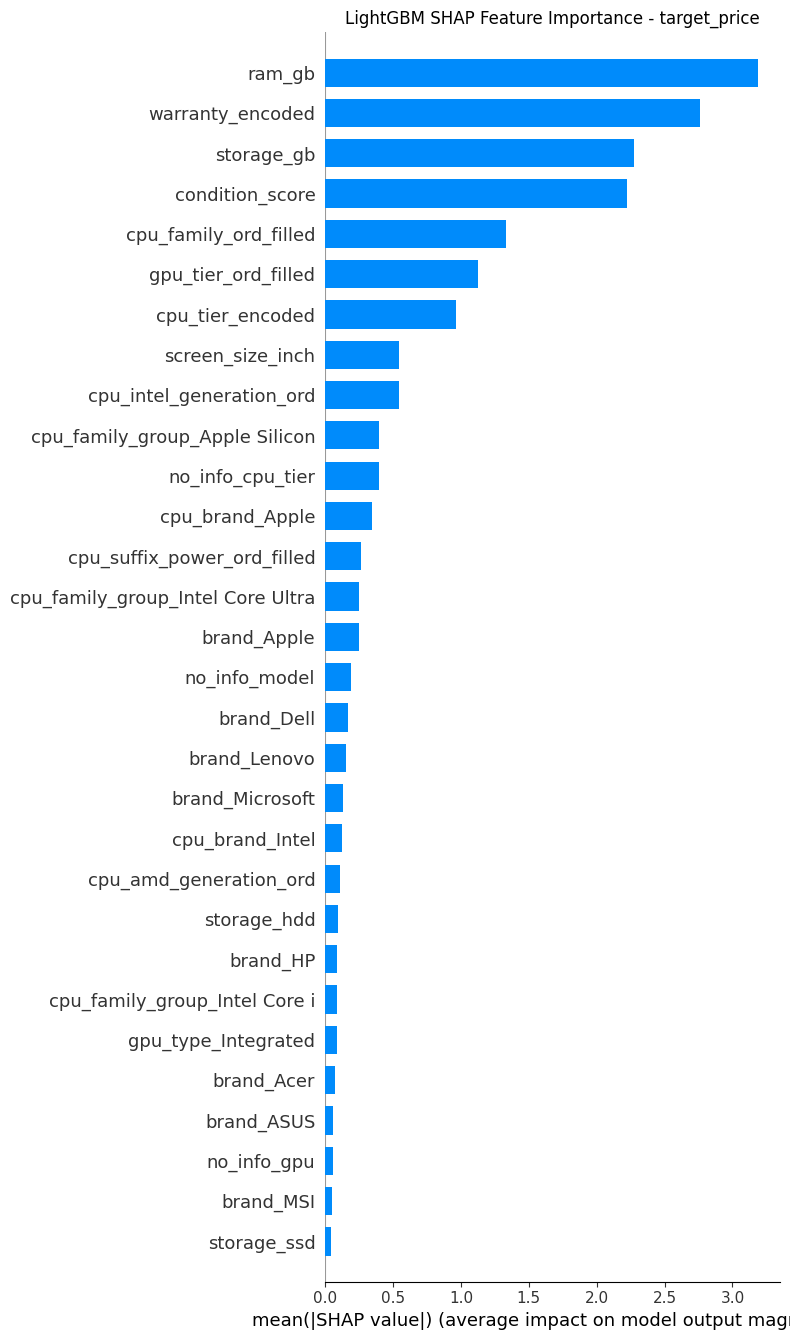

Saved SHAP bar plot: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\feature_selection\shap_summary_bar_target_price.png


In [103]:
if not shap_results:
    print("[SKIP] No SHAP results available for bar plot.")
else:
    for target_name, result in shap_results.items():
        suffix = safe_artifact_name(target_name)
        X_sample = result["X_sample"]
        shap_values = result["shap_values"]

        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=SHAP_TOP_N, show=False)
        plt.title(f"{SHAP_MODEL_NAME} SHAP Feature Importance - {target_name}")
        plt.tight_layout()

        bar_path = FEATURE_SEL_DIR / f"shap_summary_bar_{suffix}.png"
        plt.savefig(bar_path, dpi=160, bbox_inches="tight")
        plt.show()
        print(f"Saved SHAP bar plot: {bar_path}")


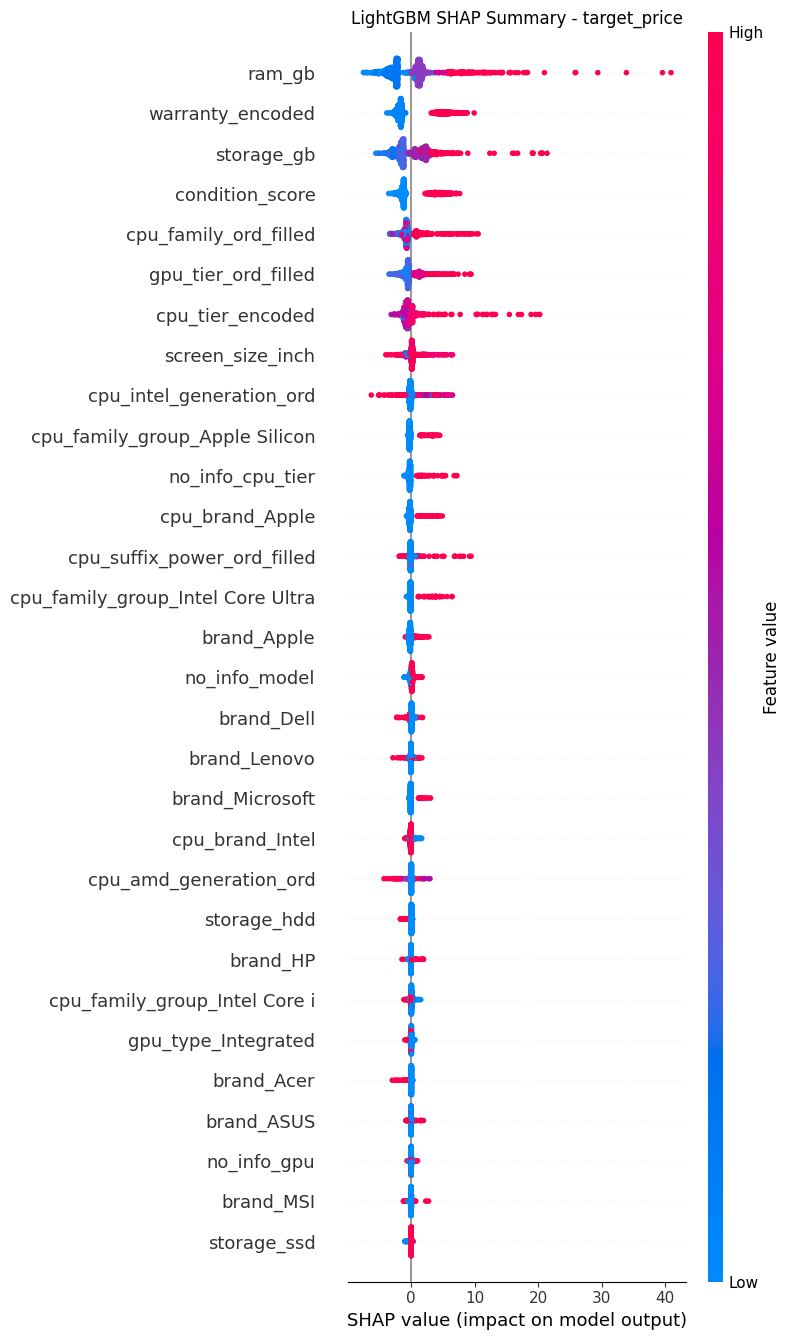

Saved SHAP beeswarm plot: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\feature_selection\shap_summary_beeswarm_target_price.png


In [104]:
if not shap_results:
    print("[SKIP] No SHAP results available for beeswarm plot.")
else:
    for target_name, result in shap_results.items():
        suffix = safe_artifact_name(target_name)
        X_sample = result["X_sample"]
        shap_values = result["shap_values"]

        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_sample, max_display=SHAP_TOP_N, show=False)
        plt.title(f"{SHAP_MODEL_NAME} SHAP Summary - {target_name}")
        plt.tight_layout()

        beeswarm_path = FEATURE_SEL_DIR / f"shap_summary_beeswarm_{suffix}.png"
        plt.savefig(beeswarm_path, dpi=160, bbox_inches="tight")
        plt.show()
        print(f"Saved SHAP beeswarm plot: {beeswarm_path}")


## Nhận xét SHAP summary plot cho LightGBM - target_price

Biểu đồ SHAP summary cho thấy mô hình `LightGBM` đang dự đoán `target_price` chủ yếu dựa trên các feature cấu hình, tình trạng máy và bảo hành. Các feature có ảnh hưởng mạnh nhất gồm `ram_gb`, `warranty_encoded`, `storage_gb`, `condition_score`, `cpu_family_ord_filled`, `gpu_tier_ord_filled` và `cpu_tier_encoded`. Đây là các biến nằm ở nhóm đầu về mean absolute SHAP, đồng thời cũng là các biến xuất hiện nhiều trong high-error audit, cho thấy chúng vừa quan trọng với mô hình, vừa là nguồn cần kiểm tra kỹ khi mô hình dự đoán sai ở vùng giá cao.

Feature `ram_gb` có tác động mạnh nhất và có pattern khá rõ: giá trị RAM cao thường kéo dự đoán giá lên mạnh, thể hiện qua các điểm màu đỏ nằm nhiều ở phía SHAP dương. Ngược lại, RAM thấp thường nằm gần 0 hoặc phía âm. Tuy nhiên, phần đuôi SHAP dương của `ram_gb` rất dài, có nhiều điểm vượt xa các feature khác. Điều này cho thấy mô hình đang gán mức premium lớn cho các máy RAM cao, nhưng cũng có rủi ro over-sensitive với RAM nếu RAM cao xuất hiện cùng các mẫu hiếm hoặc bị parse sai.

`warranty_encoded` cũng có tác động rất mạnh. Các giá trị warranty cao tập trung rõ ở phía SHAP dương, nghĩa là mô hình học rằng trạng thái bảo hành tốt hơn sẽ làm tăng giá dự đoán. Đây là tín hiệu hợp lý, nhưng vì feature này có ảnh hưởng lớn thứ hai, cần kiểm tra kỹ encoding của `warranty_encoded`. Nếu đây là biến ordinal, cần đảm bảo thứ tự giá trị thật sự phản ánh đúng mức độ giá trị kinh tế của bảo hành. Có thể nên thử one-hot warranty để tránh mô hình hiểu sai khoảng cách giữa các trạng thái bảo hành.

`storage_gb` có pattern tương tự `ram_gb`, nhưng yếu hơn. Storage cao thường kéo giá dự đoán lên, trong khi storage thấp có xu hướng làm giảm hoặc ít ảnh hưởng đến dự đoán. Phần SHAP dương của `storage_gb` cũng có một số điểm xa, cho thấy các máy storage lớn đang được mô hình xem là dấu hiệu của phân khúc cao cấp. Tuy nhiên, storage có thể chỉ là proxy cho laptop premium, nên cần kết hợp với RAM, GPU, CPU và model để tránh định giá quá cao các máy chỉ có storage lớn nhưng không thật sự cao cấp.

`condition_score` có tác động rất rõ và gần như một chiều: giá trị condition cao làm tăng dự đoán giá. Điều này hợp lý nếu `condition_score` càng cao nghĩa là tình trạng máy càng tốt. Tuy nhiên, vì feature này có SHAP importance rất lớn, cần kiểm tra lại mapping của `condition_score` để đảm bảo không bị ngược chiều. Ngoài ra, nên tạo interaction giữa `condition_score` và `warranty_encoded`, vì tác động của tình trạng máy thường mạnh hơn khi đi kèm bảo hành tốt.

Nhóm CPU có ảnh hưởng đáng kể, đặc biệt là `cpu_family_ord_filled`, `cpu_tier_encoded`, `cpu_intel_generation_ord`, `cpu_family_group_Apple Silicon`, `cpu_suffix_power_ord_filled` và `cpu_family_group_Intel Core Ultra`. Các giá trị CPU cao hoặc thuộc nhóm mới/cao cấp thường có SHAP dương, nghĩa là làm tăng giá dự đoán. Tuy nhiên, một số feature CPU có điểm nằm cả hai phía âm và dương, cho thấy tác động của CPU phụ thuộc vào tổ hợp với các feature khác như RAM, GPU, brand hoặc model. Vì vậy cần kiểm tra kỹ ordinal encoding của CPU family, CPU tier, generation và suffix power.

`gpu_tier_ord_filled` cũng có xu hướng rõ: GPU tier cao thường kéo dự đoán giá lên. Tuy nhiên, mức tác động của GPU thấp hơn RAM, warranty, storage và condition. Điều này có thể cho thấy GPU representation hiện tại chưa đủ chi tiết, hoặc dữ liệu GPU chưa đủ mạnh để mô hình học được chênh lệch lớn giữa GPU phổ thông, gaming GPU và workstation GPU. Với laptop gaming hoặc workstation, nên cải thiện mapping GPU thay vì chỉ dùng một tier tổng quát.

Các feature Apple như `cpu_family_group_Apple Silicon`, `cpu_brand_Apple` và `brand_Apple` đều có điểm SHAP dương rõ ràng ở một số mẫu. Điều này cho thấy mô hình có học được premium effect của hệ sinh thái Apple/MacBook. Tuy nhiên, tác động bị chia nhỏ qua nhiều biến Apple khác nhau, nên nên kiểm tra thêm group-level importance thay vì chỉ nhìn từng one-hot riêng lẻ.

Một điểm quan trọng là các brand riêng lẻ như `brand_Dell`, `brand_Lenovo`, `brand_HP`, `brand_ASUS`, `brand_Acer`, `brand_MSI` có SHAP nhỏ hơn nhiều so với nhóm cấu hình và trạng thái máy. Điều này không nhất thiết có nghĩa brand không quan trọng. Có thể brand effect đang bị phân tán, hoặc giá trị thương hiệu chỉ mạnh khi kết hợp với model cụ thể như XPS, ThinkPad X1 Carbon, ROG, Legion, Precision, ZBook hoặc MacBook Pro. Vì vậy cần cải thiện feature model/series thay vì chỉ dựa vào brand one-hot.

Biểu đồ cũng cho thấy nhiều feature ở nửa dưới có SHAP gần 0, ví dụ `storage_hdd`, `storage_ssd`, `no_info_gpu`, một số brand và một số nhóm CPU/GPU nhỏ. Các feature này không nhất thiết phải loại bỏ ngay, nhưng có thể đưa vào nhóm kiểm tra khi làm feature selection/ablation. Nếu loại bỏ chúng không làm giảm performance, có thể rút gọn feature set để mô hình ổn định hơn.

Nhìn chung, SHAP summary xác nhận rằng mô hình đang học theo hướng hợp lý: RAM cao, storage lớn, bảo hành tốt, condition tốt, CPU/GPU mạnh và Apple/Core Ultra thường làm tăng giá dự đoán. Tuy nhiên, các feature có ảnh hưởng mạnh nhất cũng chính là các feature liên quan đến lỗi lớn trong high-error audit. Vì vậy, vấn đề không phải là mô hình dùng sai feature, mà là các feature này cần được biểu diễn tốt hơn ở vùng cấu hình cao và laptop premium.

Hướng xử lý tiếp theo nên là:
- Kiểm tra lại mapping/encoding của `warranty_encoded`, `condition_score`, `cpu_family_ord_filled`, `cpu_tier_encoded`, `cpu_suffix_power_ord_filled` và `gpu_tier_ord_filled`.
- Thử one-hot hoặc tier hóa các biến ordinal quan trọng nếu khoảng cách giữa các mức không tuyến tính.
- Tạo interaction giữa `ram_gb`, `storage_gb`, `gpu_tier_ord_filled`, `condition_score` và `warranty_encoded`.
- Tạo các feature phân khúc như `is_high_ram`, `is_large_storage`, `is_high_end_gpu`, `is_premium_cpu`, `is_apple_silicon`, `is_core_ultra`, `is_gaming_model`, `is_workstation_model`.
- Cải thiện parsing model/series để giảm `model_Other` và nhận diện tốt hơn các dòng premium.
- Sau khi thêm feature, đánh giá riêng trên nhóm `Premium`, `ram_gb >= 32`, `storage_gb >= 1000`, GPU tier cao, Apple Silicon, Intel Core Ultra và các dòng `model_Other`.

Tóm lại, biểu đồ SHAP này ủng hộ hướng **giữ lại các feature top SHAP nhưng cải thiện representation**, thay vì drop feature. Trọng tâm tiếp theo nên là xử lý vùng laptop cao cấp, feature hiếm/cực trị và interaction giữa cấu hình mạnh với tình trạng máy/bảo hành.

## 10. Data Preparation for Retraining Experiments

Tạo một **single shared 80/20 split** dùng chung cho tất cả experiments ở Section 11.

> **Nguyên tắc:** Mọi experiment phải dùng cùng `train_idx` / `test_idx` để metric có thể so sánh công bằng.
> `df` gốc không được overwrite; mỗi experiment tự tạo bản copy riêng.

In [105]:
# ============================================================
# 10.1  Load & validate data
# ============================================================

TARGET_PRICE_COL     = "target_price"
TARGET_LOG_PRICE_COL = "log_target_price"
SEGMENT_COL          = "price_segment"

PRIMARY_TARGET = TARGET_PRICE_COL

_df_loaded = pd.read_csv(DATA_PATH)
print("Data shape:", _df_loaded.shape)

# Giữ log_target_price nếu cần so sánh phụ, nhưng experiment chính dùng target_price.
if TARGET_LOG_PRICE_COL not in _df_loaded.columns and TARGET_PRICE_COL in _df_loaded.columns:
    _df_loaded[TARGET_LOG_PRICE_COL] = np.log1p(_df_loaded[TARGET_PRICE_COL])
    print("[INFO] log_target_price derived via np.log1p for optional comparison only")

for col in [TARGET_PRICE_COL, TARGET_LOG_PRICE_COL]:
    if col in _df_loaded.columns:
        _df_loaded[col] = pd.to_numeric(_df_loaded[col], errors="coerce")

before = len(_df_loaded)
df = _df_loaded[_df_loaded[TARGET_PRICE_COL].notna() & (_df_loaded[TARGET_PRICE_COL] > 0)].copy()
df = df.reset_index(drop=True)
print(f"Rows removed (invalid target_price): {before - len(df)}  |  Final shape: {df.shape}")


Data shape: (7296, 88)
Rows removed (invalid target_price): 0  |  Final shape: (7296, 88)


In [106]:
# ============================================================
# 10.2  Shared target & price segment
# ============================================================

y_target = df[TARGET_PRICE_COL].reset_index(drop=True)
y_price = y_target.copy()
y_log = df[TARGET_LOG_PRICE_COL].reset_index(drop=True) if TARGET_LOG_PRICE_COL in df.columns else np.log1p(y_price)

# Dùng segment column có sẵn; nếu không có thì tạo từ quantile
if SEGMENT_COL in df.columns:
    price_segment = df[SEGMENT_COL].reset_index(drop=True)
    print(f"Using existing segment column: {SEGMENT_COL}")
else:
    price_segment = pd.qcut(
        y_price, q=4,
        labels=["Low", "Mid", "High", "Premium"],
        duplicates="drop",
    )
    price_segment = pd.Series(price_segment, name=SEGMENT_COL).reset_index(drop=True)
    print("Segment column created from quantile cut")

print("\nSegment distribution:")
print(price_segment.value_counts().sort_index())


Segment column created from quantile cut

Segment distribution:
price_segment
Low        1836
Mid        1867
High       1769
Premium    1824
Name: count, dtype: int64


In [107]:
# ============================================================
# 10.3  Shared 80/20 stratified split  (chỉ tạo 1 lần)
# ============================================================

all_idx = np.arange(len(df))

train_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=price_segment,
)

seg_train = price_segment.iloc[train_idx].reset_index(drop=True)
seg_test  = price_segment.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(train_idx)}  |  Test: {len(test_idx)}")
print("\nTrain segment counts:")
print(seg_train.value_counts().sort_index())
print("\nTest segment counts:")
print(seg_test.value_counts().sort_index())


Train: 5836  |  Test: 1460

Train segment counts:
price_segment
Low        1469
Mid        1493
High       1415
Premium    1459
Name: count, dtype: int64

Test segment counts:
price_segment
Low        367
Mid        374
High       354
Premium    365
Name: count, dtype: int64


In [108]:
# ============================================================
# 10.4  Baseline feature matrix  (numeric only, targets excluded)
# ============================================================

EXCLUDE_COLS = [TARGET_PRICE_COL, TARGET_LOG_PRICE_COL, SEGMENT_COL]
EXCLUDE_COLS = [c for c in EXCLUDE_COLS if c in df.columns]

X_baseline = (
    df.drop(columns=EXCLUDE_COLS)
      .select_dtypes(include=[np.number])
      .copy()
)

print("X_baseline shape:", X_baseline.shape)
print("Columns:", X_baseline.columns.tolist())


X_baseline shape: (7296, 86)
Columns: ['ram_gb', 'storage_gb', 'screen_size_inch', 'brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'no_info_brand', 'no_info_model', 'no_info_cpu_brand', 'no_info_cpu_tier', 'no_info_gpu', 'storage_ssd', 'storage_hdd', 'no_info_storage', 'condition_score', 'warranty_encoded', 'cpu_tier_encoded', 'brand_ASUS', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Other', 'brand_Sony', 'brand_Toshiba', 'model_Aspire', 'model_Elitebook', 'model_Elitebook 800', 'model_Gaming Thin GF', 'model_IdeaPad', 'model_Inspiron', 'model_Latitude', 'model_Latitude 14 7000', 'model_Latitude E Series', 'model_Legion', 'model_Legion 5', 'model_MacBook Air', 'model_MacBook Air M1', 'model_MacBook Air M2', 'model_MacBook Pro', 'model_MacBook Pro M1', 'model_MacBook Pro M2', 'model_Macbook air m4', 'model_Nitro 5', 'model_Other', 'model_Pavilion 15', 'mo

In [109]:
# ============================================================
# 10.5  Helper: run one LightGBM experiment with shared split
# ============================================================

def run_experiment(
    X: pd.DataFrame,
    y_target: pd.Series,
    y_price: pd.Series,
    train_idx,
    test_idx,
    seg_test: pd.Series,
    experiment_name: str,
    model_params: dict | None = None,
    sample_weight_train: np.ndarray | None = None,
    early_stopping_rounds: int | None = None,
    plot: bool = True,
    verbose: bool = False,
) -> tuple[dict, pd.DataFrame]:
    """
    Split X/y theo shared indices, train LightGBM trên target_price,
    evaluate trên price scale. Trả về result dict và 1-row metrics DataFrame.
    """
    X_train, X_test, y_train_target, y_test_target = make_train_test_data(
        X=X, y=y_target, train_idx=train_idx, test_idx=test_idx
    )
    _, _, _, y_test_price = make_train_test_data(
        X=X, y=y_price, train_idx=train_idx, test_idx=test_idx
    )

    print(f"[{experiment_name}] X_train={X_train.shape}  X_test={X_test.shape}")

    result = run_lgbm_experiment(
        experiment_name=experiment_name,
        X_train=X_train,
        y_train=y_train_target,
        X_test=X_test,
        y_test=y_test_target,
        y_test_price=y_test_price,
        target_name=TARGET_PRICE_COL,
        log_transform="log1p",
        model_params=model_params,
        segment_labels_test=seg_test,
        early_stopping_rounds=early_stopping_rounds,
        sample_weight=sample_weight_train,
        plot=plot,
        verbose=verbose,
    )

    metrics = pd.DataFrame([result["metrics"]])
    print(metrics[["experiment_name", "target_name", "mae", "rmse", "r2", "mape_pct"]].to_string(index=False))
    return result, metrics


print("Helper run_experiment() ready for LightGBM + target_price.")


Helper run_experiment() ready for LightGBM + target_price.


## 11. Retraining Experiments

Mỗi experiment thay đổi **đúng một yếu tố** (feature engineering, encoding, weighting) so với baseline, dùng cùng split để metric so sánh được.

### 11.0 Baseline

Chạy model với `X_baseline` không thay đổi để làm điểm so sánh.

[baseline] X_train=(5836, 86)  X_test=(1460, 86)


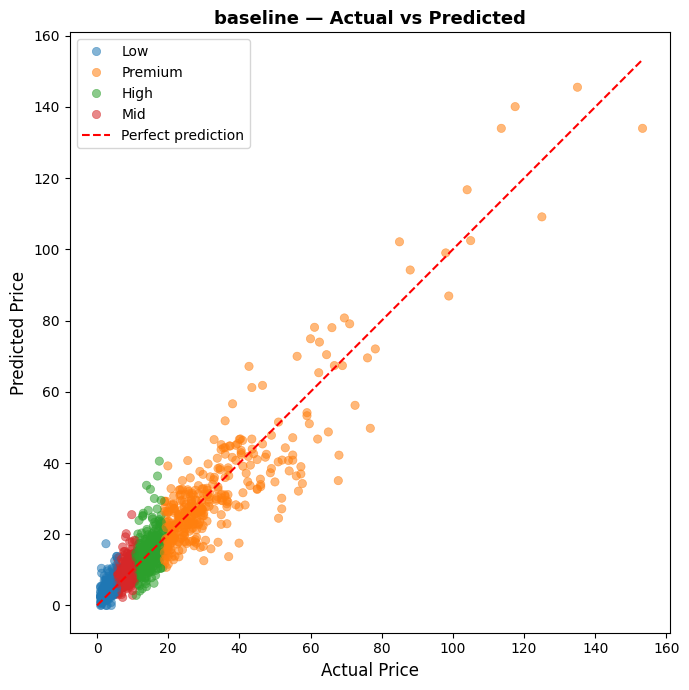

experiment_name  target_name    mae   rmse     r2  mape_pct
       baseline target_price 3.2019 5.0768 0.8874   31.0916


In [110]:
result_baseline, metrics_baseline = run_experiment(
    X=X_baseline,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="baseline",
    plot=True,
)


### 11.1 Warranty Encoding: One-hot vs Ordinal

`warranty_encoded` là biến categorical với 3 trạng thái rời rạc (0=hết BH, 1=còn BH, 2=chưa active BH). One-hot loại bỏ ordering giả tạo mà ordinal encoding ngầm tạo ra.

> **Kiểm tra đúng cách:** so sánh `X_baseline` (giữ ordinal) vs `X_onehot_warranty` (thay bằng 3 dummy). Experiment 11.3 sẽ drop warranty hoàn toàn để đo contribution thực sự.

In [111]:
# ── Tạo X với one-hot warranty ─────────────────────────────
WARRANTY_COL = "warranty_encoded"

df_w = df.copy().reset_index(drop=True)
df_w[WARRANTY_COL] = pd.to_numeric(df_w[WARRANTY_COL], errors="coerce")

# Validate: chỉ 3 giá trị hợp lệ
assert df_w[WARRANTY_COL].isin([0, 1, 2]).all(), "Unexpected warranty values"

df_w["warranty_expired"]       = (df_w[WARRANTY_COL] == 0).astype(int)
df_w["warranty_active"]        = (df_w[WARRANTY_COL] == 1).astype(int)
df_w["warranty_not_activated"] = (df_w[WARRANTY_COL] == 2).astype(int)
df_w = df_w.drop(columns=[WARRANTY_COL])

X_onehot_warranty = (
    df_w.drop(columns=EXCLUDE_COLS, errors="ignore")
        .select_dtypes(include=[np.number])
        .copy()
)

# Kiểm tra warranty columns thay đổi đúng
assert WARRANTY_COL not in X_onehot_warranty.columns, "Original warranty column still present!"
new_w_cols = [c for c in X_onehot_warranty.columns if "warranty" in c]
print("Warranty columns in X_onehot_warranty:", new_w_cols)
print("X_onehot_warranty shape:", X_onehot_warranty.shape)


Warranty columns in X_onehot_warranty: ['warranty_expired', 'warranty_active', 'warranty_not_activated']
X_onehot_warranty shape: (7296, 88)


In [150]:
result_onehot_w, metrics_onehot_w = run_experiment(
    X=X_onehot_warranty,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="warranty_onehot",
    plot=False,
)


[warranty_onehot] X_train=(5836, 88)  X_test=(1460, 88)
experiment_name  target_name    mae   rmse     r2  mape_pct
warranty_onehot target_price 3.1897 5.0627 0.8880   31.0207


Có cải tiến nhẹ so vưới baseline có thể áp dụng tính hiệu này

In [113]:
# ============================================================
# Create X with remapped warranty: 0, 1, 2 -> 0, 1, 5
# Do NOT overwrite original df / X_baseline
# ============================================================

WARRANTY_COL = "warranty_encoded"

if WARRANTY_COL not in df.columns:
    raise ValueError(
        f"Column '{WARRANTY_COL}' not found. "
        f"Available columns: {df.columns.tolist()}"
    )

# Work on a copy only
df_w_015 = df.copy().reset_index(drop=True)

# Convert warranty to numeric
df_w_015[WARRANTY_COL] = pd.to_numeric(
    df_w_015[WARRANTY_COL],
    errors="coerce"
)

# Validate: only 0, 1, 2 are allowed
invalid_values = sorted(
    df_w_015.loc[
        ~df_w_015[WARRANTY_COL].isin([0, 1, 2]),
        WARRANTY_COL
    ].dropna().unique()
)

if invalid_values:
    raise ValueError(
        f"Unexpected warranty values found: {invalid_values}"
    )

if df_w_015[WARRANTY_COL].isna().any():
    raise ValueError(
        f"Missing/NaN values found in '{WARRANTY_COL}'"
    )

print("Warranty distribution before remap:")
print(df_w_015[WARRANTY_COL].value_counts().sort_index())

warranty_mapping = {
    0: 0,
    1: 1,
    2: 5,
}

df_w_015[WARRANTY_COL] = df_w_015[WARRANTY_COL].map(warranty_mapping).astype(int)

print("\nWarranty distribution after remap:")
print(df_w_015[WARRANTY_COL].value_counts().sort_index())


X_warranty_015 = (
    df_w_015
    .drop(columns=EXCLUDE_COLS, errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

# ------------------------------------------------------------
# 4. Validate result
# ------------------------------------------------------------

assert WARRANTY_COL in X_warranty_015.columns, "Remapped warranty column missing!"
assert set(X_warranty_015[WARRANTY_COL].unique()).issubset({0, 1, 5}), \
    "Warranty remap failed!"

print("\nWarranty values in X_warranty_015:")
print(sorted(X_warranty_015[WARRANTY_COL].unique()))

print("\nX_warranty_015 shape:", X_warranty_015.shape)

Warranty distribution before remap:
warranty_encoded
0     430
1    5000
2    1866
Name: count, dtype: int64

Warranty distribution after remap:
warranty_encoded
0     430
1    5000
5    1866
Name: count, dtype: int64

Warranty values in X_warranty_015:
[0, 1, 5]

X_warranty_015 shape: (7296, 86)


In [151]:
result_warranty_015, metrics_warranty_015 = run_experiment(
    X=X_warranty_015,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="warranty_015",
    plot=False,
)


[warranty_015] X_train=(5836, 86)  X_test=(1460, 86)
experiment_name  target_name    mae   rmse     r2  mape_pct
   warranty_015 target_price 3.2019 5.0768 0.8874   31.0916


không có sự khác biệt đối với baseline, vậy độ lớn của giá trị numeric ko ảnh hưởng bằng thứ tự độ lớn

In [115]:
# Drop tất cả warranty columns
warranty_cols_to_drop = [c for c in X_baseline.columns if "warranty" in c.lower()]
print("Dropping:", warranty_cols_to_drop)

X_no_warranty = X_baseline.drop(columns=warranty_cols_to_drop, errors="ignore").copy()
print("X_no_warranty shape:", X_no_warranty.shape)


Dropping: ['warranty_encoded']
X_no_warranty shape: (7296, 85)


In [116]:
result_no_w, metrics_no_w = run_experiment(
    X=X_no_warranty,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="ablation_drop_warranty",
    plot=False,  # không cần plot cho ablation thuần
)


[ablation_drop_warranty] X_train=(5836, 85)  X_test=(1460, 85)
       experiment_name  target_name    mae   rmse     r2  mape_pct
ablation_drop_warranty target_price 3.2523 5.1203 0.8854   31.4267


**Đọc kết quả ablation warranty:**
- `ablation_drop_warranty` MAE **tăng** so với `baseline` → warranty có signal thật → **nên giữ**.
- So sánh tiếp với `warranty_onehot`: nếu one-hot tốt hơn baseline → encoding quan trọng hơn là signal.


### 11.2 Condition Score

In [117]:
# ── Tạo X với one-hot condition_score ─────────────────────────────
CONDITION_COL = "condition_score"

df_c = df.copy().reset_index(drop=True)
df_c[CONDITION_COL] = pd.to_numeric(df_c[CONDITION_COL], errors="coerce")

# Validate: chỉ 3 giá trị hợp lệ
assert df_c[CONDITION_COL].isin([1, 2, 3]).all(), "Unexpected condition_score values"

df_c["condition_score_1"] = (df_c[CONDITION_COL] == 1).astype(int)
df_c["condition_score_2"] = (df_c[CONDITION_COL] == 2).astype(int)
df_c["condition_score_3"] = (df_c[CONDITION_COL] == 3).astype(int)

# Drop cột gốc sau khi one-hot
df_c = df_c.drop(columns=[CONDITION_COL])

X_onehot_condition = (
    df_c.drop(columns=EXCLUDE_COLS, errors="ignore")
        .select_dtypes(include=[np.number])
        .copy()
)

# Kiểm tra condition columns thay đổi đúng
assert CONDITION_COL not in X_onehot_condition.columns, "Original condition_score column still present!"

new_c_cols = [c for c in X_onehot_condition.columns if "condition" in c]

print("Condition columns in X_onehot_condition:", new_c_cols)
print("X_onehot_condition shape:", X_onehot_condition.shape)

Condition columns in X_onehot_condition: ['condition_score_1', 'condition_score_2', 'condition_score_3']
X_onehot_condition shape: (7296, 88)


In [152]:
result_onehot_c, metrics_onehot_c = run_experiment(
    X=X_onehot_condition,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="condition_onehot",
    plot=False,
)


[condition_onehot] X_train=(5836, 88)  X_test=(1460, 88)
 experiment_name  target_name    mae   rmse     r2  mape_pct
condition_onehot target_price 3.2141 5.1167 0.8856   31.0781


In [119]:
# Drop tất cả condition columns
condition_cols_to_drop = [
    c for c in X_baseline.columns
    if "condition" in c.lower()
]

print("Dropping:", condition_cols_to_drop)

X_no_condition = X_baseline.drop(
    columns=condition_cols_to_drop,
    errors="ignore"
).copy()

print("X_no_condition shape:", X_no_condition.shape)

Dropping: ['condition_score']
X_no_condition shape: (7296, 85)


In [ ]:
result_no_c, metrics_no_c = run_experiment(
    X=X_no_condition,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="ablation_drop_condition",
    plot=False,
)


[ablation_drop_condition] X_train=(5836, 85)  X_test=(1460, 85)
        experiment_name  target_name    mae   rmse     r2  mape_pct
ablation_drop_condition target_price 3.2164 5.1334 0.8849   31.2628


Kết quả giống như cho warrenty

### 11.3 Feature Phi Tuyến từ RAM / Storage

LightGBM là tree-based — **bất biến với monotonic scaling** (`ram_gb / 512` cho kết quả giống hệt `ram_gb`). Các feature thực sự mới cần tạo ra **information chưa có** trong data:

- `ram_storage_ratio`: tỷ lệ RAM/Storage phản ánh cân bằng workload
- `log_ram_gb`, `log_storage_gb`: compress tail distribution của high-end laptops  
- `ram_tier`, `storage_tier`: bucketize theo ngưỡng thị trường thực tế
- `is_high_ram`: binary flag cho laptops ≥32GB (workstation/pro segment)


In [121]:
# ============================================================
# Create X with only high-spec indicator features
# Do NOT overwrite original df / X_baseline
# ============================================================

df_high = df.copy().reset_index(drop=True)

RAM_COL = "ram_gb"
STORAGE_COL = "storage_gb"

# ------------------------------------------------------------
# 1. Validate required columns
# ------------------------------------------------------------

missing_cols = [
    col for col in [RAM_COL, STORAGE_COL]
    if col not in df_high.columns
]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# ------------------------------------------------------------
# 2. Convert to numeric
# ------------------------------------------------------------

df_high[RAM_COL] = pd.to_numeric(df_high[RAM_COL], errors="coerce")
df_high[STORAGE_COL] = pd.to_numeric(df_high[STORAGE_COL], errors="coerce")

# ------------------------------------------------------------
# 3. Create high-spec flags
# ------------------------------------------------------------

df_high["is_high_ram_16"] = (df_high[RAM_COL] >= 16).astype(int)
df_high["is_high_ram_32"] = (df_high[RAM_COL] >= 32).astype(int)

df_high["is_large_storage_512"] = (df_high[STORAGE_COL] >= 512).astype(int)
df_high["is_large_storage_1024"] = (df_high[STORAGE_COL] >= 1024).astype(int)

df_high["is_high_ram_large_storage"] = (
    (df_high[RAM_COL] >= 16) &
    (df_high[STORAGE_COL] >= 512)
).astype(int)

# ------------------------------------------------------------
# 4. Create numeric feature matrix
# ------------------------------------------------------------

X_high_spec = (
    df_high
    .drop(columns=EXCLUDE_COLS, errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

# ------------------------------------------------------------
# 5. Keep baseline + only new high-spec flags
# ------------------------------------------------------------

high_spec_features = [
    "is_high_ram_16",
    "is_high_ram_32",
    "is_large_storage_512",
    "is_large_storage_1024",
    "is_high_ram_large_storage",
]

high_spec_cols = X_baseline.columns.tolist() + high_spec_features
high_spec_cols = [c for c in high_spec_cols if c in X_high_spec.columns]

X_high_spec_only = X_high_spec[high_spec_cols].copy()

print("New high-spec features:", high_spec_features)
print("Actually added:", [c for c in X_high_spec_only.columns if c not in X_baseline.columns])
print("X_high_spec_only shape:", X_high_spec_only.shape)

print("\nHigh-spec feature distribution:")
display(X_high_spec_only[high_spec_features].agg(["mean", "sum"]).T)

New high-spec features: ['is_high_ram_16', 'is_high_ram_32', 'is_large_storage_512', 'is_large_storage_1024', 'is_high_ram_large_storage']
Actually added: ['is_high_ram_16', 'is_high_ram_32', 'is_large_storage_512', 'is_large_storage_1024', 'is_high_ram_large_storage']
X_high_spec_only shape: (7296, 91)

High-spec feature distribution:


,mean,sum
is_high_ram_16,0.4981,"3,634.0000"
is_high_ram_32,0.0902,658.0000
is_large_storage_512,0.4807,"3,507.0000"
is_large_storage_1024,0.1324,966.0000
is_high_ram_large_storage,0.3657,"2,668.0000"


In [153]:
# ============================================================
# Run experiment: high-spec RAM / Storage flags only
# ============================================================

result_high_spec, metrics_high_spec = run_experiment(
    X=X_high_spec_only,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="rs_high_spec_flags",
    plot=False,
)


[rs_high_spec_flags] X_train=(5836, 91)  X_test=(1460, 91)
   experiment_name  target_name    mae   rmse     r2  mape_pct
rs_high_spec_flags target_price 3.2048 5.0681 0.8878   31.2390


In [123]:
df_rs2 = df.copy().reset_index(drop=True)

RAM_COL = "ram_gb"
STORAGE_COL = "storage_gb"

for col in [RAM_COL, STORAGE_COL]:
    if col not in df_rs2.columns:
        raise ValueError(f"Missing required column: {col}")
    df_rs2[col] = pd.to_numeric(df_rs2[col], errors="coerce")

df_rs2["ram_storage_product_scaled"] = (
    df_rs2[RAM_COL] * df_rs2[STORAGE_COL]
) / (16 * 512)

df_rs2["ram_storage_balance"] = np.minimum(
    df_rs2[RAM_COL] / 16,
    df_rs2[STORAGE_COL] / 512
)

df_rs2["memory_storage_score"] = (
    2.0 * np.log1p(df_rs2[RAM_COL]) +
    1.0 * np.log1p(df_rs2[STORAGE_COL])
)

df_rs2["is_entry_memory_storage"] = (
    (df_rs2[RAM_COL] <= 8) &
    (df_rs2[STORAGE_COL] <= 256)
).astype(int)

df_rs2["is_mid_memory_storage"] = (
    (df_rs2[RAM_COL] >= 16) &
    (df_rs2[STORAGE_COL] >= 512)
).astype(int)

df_rs2["is_premium_memory_storage"] = (
    (df_rs2[RAM_COL] >= 32) &
    (df_rs2[STORAGE_COL] >= 1024)
).astype(int)

X_rs2_all = (
    df_rs2
    .drop(columns=EXCLUDE_COLS, errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

rs2_features = [
    "ram_storage_product_scaled",
    "ram_storage_balance",
    "memory_storage_score",
    "is_entry_memory_storage",
    "is_mid_memory_storage",
    "is_premium_memory_storage",
]

# Keep baseline + only new RAM/Storage features
rs2_cols = X_baseline.columns.tolist() + rs2_features
rs2_cols = [c for c in rs2_cols if c in X_rs2_all.columns]

X_rs2 = X_rs2_all[rs2_cols].copy()

print("New RAM/Storage features:", rs2_features)
print("Actually added:", [c for c in X_rs2.columns if c not in X_baseline.columns])
print("X_rs2 shape:", X_rs2.shape)

display(
    X_rs2[rs2_features]
    .describe()
    .T[["mean", "min", "50%", "max"]]
)

New RAM/Storage features: ['ram_storage_product_scaled', 'ram_storage_balance', 'memory_storage_score', 'is_entry_memory_storage', 'is_mid_memory_storage', 'is_premium_memory_storage']
Actually added: ['ram_storage_product_scaled', 'ram_storage_balance', 'memory_storage_score', 'is_entry_memory_storage', 'is_mid_memory_storage', 'is_premium_memory_storage']
X_rs2 shape: (7296, 92)


,mean,min,50%,max
ram_storage_product_scaled,0.9986,0.0000,0.5000,144.0000
ram_storage_balance,0.6797,0.0000,0.5000,12.0000
memory_storage_score,10.5256,0.0000,10.6347,19.2488
is_entry_memory_storage,0.3660,0.0000,0.0000,1.0000
is_mid_memory_storage,0.3657,0.0000,0.0000,1.0000
is_premium_memory_storage,0.0526,0.0000,0.0000,1.0000


In [154]:
result_rs2, metrics_rs2 = run_experiment(
    X=X_rs2,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="rs2_ram_storage_interactions",
    plot=False,
)

[rs2_ram_storage_interactions] X_train=(5836, 92)  X_test=(1460, 92)
             experiment_name  target_name    mae   rmse     r2  mape_pct
rs2_ram_storage_interactions target_price 3.1852 5.0410 0.8890   30.6421


### Observation

Kết quả ablation cho thấy việc tạo thêm các feature từ `ram_gb` và `storage_gb` không tạo ra cải thiện quá lớn so với baseline. Điều này khá hợp lý vì LightGBM đã có khả năng tự học các quan hệ phi tuyến và các ngưỡng split trực tiếp từ hai feature gốc này. Do đó, các biến đổi như tích RAM–Storage, balance score hoặc combined score có thể không bổ sung thêm nhiều thông tin mới cho mô hình.

Trong các feature được thử nghiệm riêng lẻ, `is_mid_memory_storage` cho kết quả tốt nhất tổng thể. Feature này đạt RMSE thấp nhất và R² cao nhất trong nhóm, cho thấy ngưỡng `RAM >= 16GB` và `Storage >= 512GB` có thể đại diện cho một phân khúc laptop trung/cao cấp có ý nghĩa trên thị trường. Đây là loại feature có tính diễn giải tốt hơn so với các phép biến đổi số học đơn thuần.

Ngược lại, `is_premium_memory_storage` không cho kết quả tốt bằng dù về mặt trực giác nó đại diện cho nhóm máy cao cấp hơn. Nguyên nhân có thể là nhóm laptop có `RAM >= 32GB` và `Storage >= 1024GB` có số lượng mẫu ít hơn, hoặc giá của nhóm này phụ thuộc mạnh hơn vào các yếu tố khác như CPU, GPU, brand, dòng máy, tình trạng sản phẩm và warranty.

Nhìn chung, kết quả cho thấy không nên thêm toàn bộ nhóm RAM/Storage engineered features vào mô hình. Các feature này có thể làm feature set phức tạp hơn nhưng không đem lại cải thiện rõ ràng. Nếu cần giữ lại một feature từ nhóm này, `is_mid_memory_storage` là lựa chọn hợp lý nhất để tiếp tục kiểm tra so với baseline chính.

Bước tiếp theo nên là so sánh trực tiếp `X_baseline` với phiên bản chỉ thêm `is_mid_memory_storage`. Nếu cải thiện vẫn rất nhỏ hoặc không ổn định, nên giữ nguyên baseline và không thêm feature RAM/Storage mới. Trong trường hợp mục tiêu chính là giảm lỗi ở nhóm laptop cấu hình cao, hướng phù hợp hơn có thể là thử sample weighting cho nhóm premium thay vì tiếp tục tạo thêm feature từ RAM và Storage.


In [124]:
# ============================================================
# RAM / Storage relative-to-brand features
# Brand is already one-hot encoded with prefix "brand_"
# Avoid overwriting original df / X_baseline
# ============================================================

df_rel = df.copy().reset_index(drop=True)

RAM_COL = "ram_gb"
STORAGE_COL = "storage_gb"
BRAND_PREFIX = "brand_"

# ------------------------------------------------------------
# 1. Validate required numeric columns
# ------------------------------------------------------------

for col in [RAM_COL, STORAGE_COL]:
    if col not in df_rel.columns:
        raise ValueError(f"Missing required column: {col}")

df_rel[RAM_COL] = pd.to_numeric(df_rel[RAM_COL], errors="coerce")
df_rel[STORAGE_COL] = pd.to_numeric(df_rel[STORAGE_COL], errors="coerce")

# ------------------------------------------------------------
# 2. Detect one-hot brand columns
# ------------------------------------------------------------

brand_cols = [
    c for c in df_rel.columns
    if c.startswith(BRAND_PREFIX)
]

if len(brand_cols) == 0:
    raise ValueError(
        f"No one-hot brand columns found with prefix '{BRAND_PREFIX}'"
    )

print("Detected brand one-hot columns:")
print(brand_cols)

# ------------------------------------------------------------
# 3. Reconstruct temporary brand group from one-hot columns
# ------------------------------------------------------------

brand_ohe = df_rel[brand_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# If one brand column is 1, use that column name as group.
# If all are 0, mark as unknown_brand.
df_rel["_brand_group_tmp"] = brand_ohe.idxmax(axis=1)

no_brand_mask = brand_ohe.sum(axis=1) == 0
df_rel.loc[no_brand_mask, "_brand_group_tmp"] = "unknown_brand"

print("\nTemporary brand group distribution:")
print(df_rel["_brand_group_tmp"].value_counts())

# Optional validation: check rows with more than one active brand
multi_brand_mask = brand_ohe.sum(axis=1) > 1
print("\nRows with multiple active brand columns:", multi_brand_mask.sum())

# ------------------------------------------------------------
# 4. Median RAM / Storage by reconstructed brand group
# ------------------------------------------------------------

brand_ram_median = df_rel.groupby("_brand_group_tmp")[RAM_COL].transform("median")
brand_storage_median = df_rel.groupby("_brand_group_tmp")[STORAGE_COL].transform("median")

df_rel["ram_vs_brand_median"] = (
    df_rel[RAM_COL] / brand_ram_median.replace(0, np.nan)
)

df_rel["storage_vs_brand_median"] = (
    df_rel[STORAGE_COL] / brand_storage_median.replace(0, np.nan)
)

df_rel["ram_minus_brand_median"] = (
    df_rel[RAM_COL] - brand_ram_median
)

df_rel["storage_minus_brand_median"] = (
    df_rel[STORAGE_COL] - brand_storage_median
)

rel_features = [
    "ram_vs_brand_median",
    "storage_vs_brand_median",
    "ram_minus_brand_median",
    "storage_minus_brand_median",
]

# ------------------------------------------------------------
# 5. Create numeric feature matrix
# ------------------------------------------------------------

X_rel_all = (
    df_rel
    .drop(columns=EXCLUDE_COLS + ["_brand_group_tmp"], errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

# Keep baseline + only new relative features
rel_cols = X_baseline.columns.tolist() + rel_features
rel_cols = [c for c in rel_cols if c in X_rel_all.columns]

X_rs_relative_brand = X_rel_all[rel_cols].copy()

print("\nAdded features:", [c for c in X_rs_relative_brand.columns if c not in X_baseline.columns])
print("X_rs_relative_brand shape:", X_rs_relative_brand.shape)

display(
    X_rs_relative_brand[rel_features]
    .describe()
    .T[["mean", "min", "50%", "max"]]
)

Detected brand one-hot columns:
['brand_is_rare', 'brand_ASUS', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Other', 'brand_Sony', 'brand_Toshiba']

Temporary brand group distribution:
_brand_group_tmp
brand_Dell         1983
brand_Lenovo       1075
brand_Apple         993
brand_HP            942
brand_ASUS          867
brand_Acer          486
brand_MSI           308
brand_Other         300
brand_Microsoft     247
brand_is_rare        95
Name: count, dtype: int64

Rows with multiple active brand columns: 95

Added features: ['ram_vs_brand_median', 'storage_vs_brand_median', 'ram_minus_brand_median', 'storage_minus_brand_median']
X_rs_relative_brand shape: (7296, 90)


,mean,min,50%,max
ram_vs_brand_median,1.3287,0.0000,1.0000,24.0000
storage_vs_brand_median,1.3390,0.0000,1.0000,32.0000
ram_minus_brand_median,2.5249,-16.0000,0.0000,184.0000
storage_minus_brand_median,89.4555,-512.0000,0.0000,"7,936.0000"


In [155]:
result_rs_relative_brand, metrics_rs_relative_brand = run_experiment(
    X=X_rs_relative_brand,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="rs_relative_brand_ohe",
    plot=False,
)


[rs_relative_brand_ohe] X_train=(5836, 90)  X_test=(1460, 90)
      experiment_name  target_name    mae   rmse     r2  mape_pct
rs_relative_brand_ohe target_price 3.1918 5.0634 0.8880   30.7965


### Observation

Với `LightGBM + target_price`, nhóm feature RAM/Storage relative-to-brand cải thiện nhẹ nhưng nhất quán so với baseline. Baseline đạt MAE khoảng `3.2019`, RMSE `5.0768`, R² `0.8874`, MAPE `31.0916%`; `rs_relative_brand_ohe` đạt MAE khoảng `3.1915`, RMSE `5.0634`, R² `0.888`, MAPE `30.7965%`.

Điểm đáng chú ý là feature này không chỉ giảm RMSE mà còn giảm MAPE. Việc so sánh RAM và storage của một máy với mặt bằng cùng brand đang bổ sung ngữ cảnh thị trường hữu ích.

Nhóm feature này nên được giữ như một candidate tốt để kiểm tra trong các tổ hợp tiếp theo. Mức cải thiện vẫn nhỏ, nên cần so sánh tiếp với các nhóm GPU/model-family và CPU mở rộng.


### 11.4 Config Core

In [126]:
RANDOM_STATE = 42

df_premium = df.copy().reset_index(drop=True)

# ------------------------------------------------------------
# 1. Required columns
# ------------------------------------------------------------

required_cols = [
    "ram_gb",
    "storage_gb",
    "gpu_tier_ord_filled",
    "gpu_type_Dedicated",
    "cpu_tier_encoded",
    "condition_score",
    "warranty_encoded",
]

missing_cols = [c for c in required_cols if c not in df_premium.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

numeric_cols = [
    "ram_gb",
    "storage_gb",
    "gpu_tier_ord_filled",
    "gpu_type_Dedicated",
    "cpu_tier_encoded",
    "condition_score",
    "warranty_encoded",
]

for col in numeric_cols:
    df_premium[col] = pd.to_numeric(df_premium[col], errors="coerce")

# Fill only for feature construction safety
ram = df_premium["ram_gb"].fillna(0)
storage = df_premium["storage_gb"].fillna(0)
gpu_tier = df_premium["gpu_tier_ord_filled"].fillna(0)
gpu_dedicated = df_premium["gpu_type_Dedicated"].fillna(0)
cpu_tier = df_premium["cpu_tier_encoded"].fillna(0)
condition_score = df_premium["condition_score"].fillna(0)
warranty = df_premium["warranty_encoded"].fillna(-1)

In [127]:
# ============================================================
# 2. Create premium signal features
# ============================================================

# ------------------------------------------------------------
# A. Premium config score
# ------------------------------------------------------------

df_premium["premium_config_score"] = (
    1.5 * (ram >= 16).astype(int)
    + 2.0 * (ram >= 32).astype(int)
    + 1.0 * (storage >= 512).astype(int)
    + 1.5 * (storage >= 1024).astype(int)
    + 1.5 * (gpu_tier >= 3).astype(int)
    + 1.0 * (gpu_dedicated == 1).astype(int)
    + 1.0 * (cpu_tier >= 3).astype(int)
)

# ------------------------------------------------------------
# B. GPU interaction features
# ------------------------------------------------------------

df_premium["is_high_gpu_config"] = (
    (gpu_tier >= 3) | (gpu_dedicated == 1)
).astype(int)

df_premium["is_high_gpu_with_high_ram"] = (
    ((gpu_tier >= 3) | (gpu_dedicated == 1))
    & (ram >= 16)
).astype(int)

df_premium["is_high_gpu_with_large_storage"] = (
    ((gpu_tier >= 3) | (gpu_dedicated == 1))
    & (storage >= 512)
).astype(int)

# ------------------------------------------------------------
# C. Apple premium feature
# ------------------------------------------------------------

brand_apple = df_premium["brand_Apple"] if "brand_Apple" in df_premium.columns else 0
cpu_brand_apple = df_premium["cpu_brand_Apple"] if "cpu_brand_Apple" in df_premium.columns else 0

df_premium["is_apple_premium"] = (
    ((brand_apple == 1) | (cpu_brand_apple == 1))
    & ((ram >= 16) | (storage >= 512))
).astype(int)

# ------------------------------------------------------------
# D. Condition / warranty interaction
# ------------------------------------------------------------

df_premium["condition_warranty_risk"] = (
    condition_score.astype(int)
    + (warranty == 0).astype(int)
)

df_premium["is_uncertain_condition_no_warranty"] = (
    (condition_score == 0)
    & (warranty == 0)
).astype(int)

# ------------------------------------------------------------
# E. Mid memory/storage feature from previous best single feature
# ------------------------------------------------------------

df_premium["is_mid_memory_storage"] = (
    (ram >= 16)
    & (storage >= 512)
).astype(int)

In [128]:
# ============================================================
# 3. Relative-to-brand RAM / Storage features
# Brand columns are one-hot with prefix "brand_"
# ============================================================

BRAND_PREFIX = "brand_"

brand_cols = [
    c for c in df_premium.columns
    if c.startswith(BRAND_PREFIX)
]

if len(brand_cols) == 0:
    raise ValueError(f"No one-hot brand columns found with prefix '{BRAND_PREFIX}'")

brand_ohe = df_premium[brand_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

df_premium["_brand_group_tmp"] = brand_ohe.idxmax(axis=1)

no_brand_mask = brand_ohe.sum(axis=1) == 0
df_premium.loc[no_brand_mask, "_brand_group_tmp"] = "unknown_brand"

multi_brand_mask = brand_ohe.sum(axis=1) > 1

print("Detected brand columns:", brand_cols)
print("Rows with no active brand:", no_brand_mask.sum())
print("Rows with multiple active brands:", multi_brand_mask.sum())

brand_ram_median = df_premium.groupby("_brand_group_tmp")["ram_gb"].transform("median")
brand_storage_median = df_premium.groupby("_brand_group_tmp")["storage_gb"].transform("median")

df_premium["ram_vs_brand_median"] = (
    df_premium["ram_gb"] / brand_ram_median.replace(0, np.nan)
)

df_premium["storage_vs_brand_median"] = (
    df_premium["storage_gb"] / brand_storage_median.replace(0, np.nan)
)

df_premium["ram_minus_brand_median"] = (
    df_premium["ram_gb"] - brand_ram_median
)

df_premium["storage_minus_brand_median"] = (
    df_premium["storage_gb"] - brand_storage_median
)

Detected brand columns: ['brand_is_rare', 'brand_ASUS', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Other', 'brand_Sony', 'brand_Toshiba']
Rows with no active brand: 0
Rows with multiple active brands: 95


In [129]:
# ============================================================
# 4. Create full numeric feature matrix
# ============================================================

X_premium_all = (
    df_premium
    .drop(columns=EXCLUDE_COLS + ["_brand_group_tmp"], errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

relative_brand_features = [
    "ram_vs_brand_median",
    "storage_vs_brand_median",
    "ram_minus_brand_median",
    "storage_minus_brand_median",
]

premium_score_features = [
    "premium_config_score",
]

gpu_interaction_features = [
    "is_high_gpu_config",
    "is_high_gpu_with_high_ram",
    "is_high_gpu_with_large_storage",
]

apple_premium_features = [
    "is_apple_premium",
]

condition_warranty_features = [
    "condition_warranty_risk",
    "is_uncertain_condition_no_warranty",
]

mid_memory_storage_features = [
    "is_mid_memory_storage",
]

all_new_features = (
    relative_brand_features
    + premium_score_features
    + gpu_interaction_features
    + apple_premium_features
    + condition_warranty_features
    + mid_memory_storage_features
)

print("New candidate features:")
print(all_new_features)

print("\nAvailable new features:")
print([c for c in all_new_features if c in X_premium_all.columns])

display(
    X_premium_all[[c for c in all_new_features if c in X_premium_all.columns]]
    .describe()
    .T[["mean", "min", "50%", "max"]]
)

New candidate features:
['ram_vs_brand_median', 'storage_vs_brand_median', 'ram_minus_brand_median', 'storage_minus_brand_median', 'premium_config_score', 'is_high_gpu_config', 'is_high_gpu_with_high_ram', 'is_high_gpu_with_large_storage', 'is_apple_premium', 'condition_warranty_risk', 'is_uncertain_condition_no_warranty', 'is_mid_memory_storage']

Available new features:
['ram_vs_brand_median', 'storage_vs_brand_median', 'ram_minus_brand_median', 'storage_minus_brand_median', 'premium_config_score', 'is_high_gpu_config', 'is_high_gpu_with_high_ram', 'is_high_gpu_with_large_storage', 'is_apple_premium', 'condition_warranty_risk', 'is_uncertain_condition_no_warranty', 'is_mid_memory_storage']


,mean,min,50%,max
ram_vs_brand_median,1.3287,0.0000,1.0000,24.0000
storage_vs_brand_median,1.3390,0.0000,1.0000,32.0000
ram_minus_brand_median,2.5249,-16.0000,0.0000,184.0000
storage_minus_brand_median,89.4555,-512.0000,0.0000,"7,936.0000"
premium_config_score,2.8407,0.0000,2.5000,9.5000
is_high_gpu_config,0.2508,0.0000,0.0000,1.0000
is_high_gpu_with_high_ram,0.1812,0.0000,0.0000,1.0000
is_high_gpu_with_large_storage,0.1908,0.0000,0.0000,1.0000
is_apple_premium,0.0805,0.0000,0.0000,1.0000
condition_warranty_risk,2.3300,1.0000,2.0000,4.0000


In [130]:
# ============================================================
# 5. Prepare train/test split if not already available
# ============================================================

# y_log / y_price should already exist.
# If not, create them from df.
if "y_price" not in globals():
    y_price = pd.to_numeric(df["target_price"], errors="coerce")

if "y_log" not in globals():
    y_log = pd.to_numeric(df["log_target_price"], errors="coerce")

# Create price_segment if not already available
if "price_segment" not in globals():
    price_segment = pd.qcut(
        y_price,
        q=5,
        labels=["very_low", "low", "mid", "high", "premium"],
        duplicates="drop"
    )

# Create train/test idx if not already available
if "train_idx" not in globals() or "test_idx" not in globals():
    all_idx = np.arange(len(df))

    train_idx, test_idx = train_test_split(
        all_idx,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=price_segment,
    )

# Create seg_test if not already available
if "seg_test" not in globals():
    seg_test = pd.Series(price_segment).iloc[test_idx].reset_index(drop=True)

print("n_train:", len(train_idx))
print("n_test:", len(test_idx))
print("\nTest segment distribution:")
print(pd.Series(seg_test).value_counts())

n_train: 5836
n_test: 1460

Test segment distribution:
price_segment
Mid        374
Low        367
Premium    365
High       354
Name: count, dtype: int64


In [131]:
# ============================================================
# 6. Build experiment feature sets
# ============================================================

def make_feature_set(base_X, source_X, added_features):
    cols = base_X.columns.tolist() + added_features
    cols = [c for c in cols if c in source_X.columns]
    return source_X[cols].copy()


X_relative_brand = make_feature_set(
    X_baseline,
    X_premium_all,
    relative_brand_features,
)

X_premium_score = make_feature_set(
    X_baseline,
    X_premium_all,
    premium_score_features,
)

X_gpu_interaction = make_feature_set(
    X_baseline,
    X_premium_all,
    gpu_interaction_features,
)

X_apple_premium = make_feature_set(
    X_baseline,
    X_premium_all,
    apple_premium_features,
)

X_condition_warranty = make_feature_set(
    X_baseline,
    X_premium_all,
    condition_warranty_features,
)

X_mid_memory_storage = make_feature_set(
    X_baseline,
    X_premium_all,
    mid_memory_storage_features,
)

X_premium_best_candidate = make_feature_set(
    X_baseline,
    X_premium_all,
    relative_brand_features
    + premium_score_features
    + gpu_interaction_features
    + apple_premium_features
    + condition_warranty_features
    + mid_memory_storage_features,
)

feature_sets = {
    "baseline": X_baseline,
    "relative_brand": X_relative_brand,
    "premium_config_score": X_premium_score,
    "gpu_interaction": X_gpu_interaction,
    "apple_premium": X_apple_premium,
    "condition_warranty": X_condition_warranty,
    "mid_memory_storage": X_mid_memory_storage,
    "premium_best_candidate": X_premium_best_candidate,
}

for name, X_temp in feature_sets.items():
    print(f"{name}: shape = {X_temp.shape}, added = {X_temp.shape[1] - X_baseline.shape[1]}")

baseline: shape = (7296, 86), added = 0
relative_brand: shape = (7296, 90), added = 4
premium_config_score: shape = (7296, 87), added = 1
gpu_interaction: shape = (7296, 89), added = 3
apple_premium: shape = (7296, 87), added = 1
condition_warranty: shape = (7296, 88), added = 2
mid_memory_storage: shape = (7296, 87), added = 1
premium_best_candidate: shape = (7296, 98), added = 12


In [132]:
# ============================================================
# 7. Run experiments
# ============================================================

premium_results = {}
premium_metrics = []

for exp_name, X_exp in feature_sets.items():
    print("\n" + "=" * 80)
    print(f"Running experiment: {exp_name}")
    print("X shape:", X_exp.shape)
    print("=" * 80)

    result, metrics = run_experiment(
        X=X_exp,
        y_target=y_target,
        y_price=y_price,
        train_idx=train_idx,
        test_idx=test_idx,
        seg_test=seg_test,
        experiment_name=exp_name,
        plot=False,
    )

    premium_results[exp_name] = result

    temp_metrics = metrics.copy()
    temp_metrics["feature_case"] = exp_name
    premium_metrics.append(temp_metrics)

premium_metrics_compare = pd.concat(premium_metrics, ignore_index=True)

display(
    premium_metrics_compare[
        [
            "feature_case",
            "experiment_name",
            "target_name",
            "mae",
            "rmse",
            "r2",
            "mape_pct",
            "median_ape_pct",
            "n_features",
        ]
    ].sort_values(["target_name", "rmse"])
)



Running experiment: baseline
X shape: (7296, 86)
[baseline] X_train=(5836, 86)  X_test=(1460, 86)
experiment_name  target_name    mae   rmse     r2  mape_pct
       baseline target_price 3.2019 5.0768 0.8874   31.0916

Running experiment: relative_brand
X shape: (7296, 90)
[relative_brand] X_train=(5836, 90)  X_test=(1460, 90)
experiment_name  target_name    mae   rmse     r2  mape_pct
 relative_brand target_price 3.1918 5.0634 0.8880   30.7965

Running experiment: premium_config_score
X shape: (7296, 87)
[premium_config_score] X_train=(5836, 87)  X_test=(1460, 87)
     experiment_name  target_name    mae   rmse     r2  mape_pct
premium_config_score target_price 3.2458 5.1544 0.8839   31.0430

Running experiment: gpu_interaction
X shape: (7296, 89)
[gpu_interaction] X_train=(5836, 89)  X_test=(1460, 89)
experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_interaction target_price 3.1906 5.0672 0.8878   30.8389

Running experiment: apple_premium
X shape: (7296, 87)
[apple_pr

,feature_case,experiment_name,target_name,mae,rmse,r2,mape_pct,median_ape_pct,n_features
4,apple_premium,apple_premium,target_price,3.1997,5.0577,0.8882,31.1585,19.2784,87
1,relative_brand,relative_brand,target_price,3.1918,5.0634,0.8880,30.7965,18.5584,90
3,gpu_interaction,gpu_interaction,target_price,3.1906,5.0672,0.8878,30.8389,18.9913,89
5,condition_warranty,condition_warranty,target_price,3.2170,5.0734,0.8875,31.1991,19.1655,88
0,baseline,baseline,target_price,3.2019,5.0768,0.8874,31.0916,18.9211,86
6,mid_memory_storage,mid_memory_storage,target_price,3.2177,5.0881,0.8869,31.1205,19.0341,87
7,premium_best_candidate,premium_best_candidate,target_price,3.2693,5.1467,0.8843,31.6203,19.6926,98
2,premium_config_score,premium_config_score,target_price,3.2458,5.1544,0.8839,31.0430,19.0205,87


### Observation

Trong vòng thử nghiệm candidate premium features, không có block nào thắng tuyệt đối trên mọi metric. `apple_premium` và `relative_brand` cải thiện RMSE/R² so với baseline; `gpu_interaction` cho MAE tốt nhưng RMSE không phải thấp nhất; `premium_best_candidate` kém hơn baseline, cho thấy cộng tất cả feature lại không tự động cải thiện mô hình.

Kết quả này gợi ý rằng LightGBM đã học được nhiều quan hệ phi tuyến từ feature gốc, nên các feature thủ công chỉ hữu ích khi bổ sung signal thật sự rõ. Các feature relative-to-brand và một vài flag premium có tín hiệu tốt hơn các score tổng hợp quá rộng.

Bước tiếp theo hợp lý là thử các tổ hợp nhỏ, đặc biệt là GPU interaction kết hợp với relative-to-brand hoặc condition/warranty, thay vì dùng toàn bộ `premium_best_candidate`.


### 11.5 GPU 

In [133]:
# ============================================================
# Continue ablation from best block: gpu_interaction
# Test small combinations with gpu_interaction as base
# ============================================================

# ------------------------------------------------------------
# 1. Define feature blocks
# ------------------------------------------------------------

gpu_interaction_features = [
    "is_high_gpu_config",
    "is_high_gpu_with_high_ram",
    "is_high_gpu_with_large_storage",
]

relative_brand_features = [
    "ram_vs_brand_median",
    "storage_vs_brand_median",
    "ram_minus_brand_median",
    "storage_minus_brand_median",
]

apple_premium_features = [
    "is_apple_premium",
]

condition_warranty_features = [
    "condition_warranty_risk",
    "is_uncertain_condition_no_warranty",
]

mid_memory_storage_features = [
    "is_mid_memory_storage",
]

premium_score_features = [
    "premium_config_score",
]

# ------------------------------------------------------------
# 2. Helper: create X = X_baseline + selected features
# ------------------------------------------------------------

def make_feature_set(base_X, source_X, added_features):
    available_features = [c for c in added_features if c in source_X.columns]
    missing_features = [c for c in added_features if c not in source_X.columns]

    if missing_features:
        print("Missing features skipped:", missing_features)

    cols = base_X.columns.tolist() + available_features
    cols = [c for c in cols if c in source_X.columns]

    return source_X[cols].copy()


# ------------------------------------------------------------
# 3. Build combination feature sets
# ------------------------------------------------------------

combo_feature_sets = {
    "baseline": X_baseline,

    "gpu_interaction": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features,
    ),

    "gpu_plus_relative_brand": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + relative_brand_features,
    ),

    "gpu_plus_apple_premium": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + apple_premium_features,
    ),

    "gpu_plus_condition_warranty": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + condition_warranty_features,
    ),

    "gpu_plus_mid_memory_storage": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + mid_memory_storage_features,
    ),

    "gpu_plus_premium_score": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + premium_score_features,
    ),

    "gpu_plus_relative_brand_apple": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + relative_brand_features
        + apple_premium_features,
    ),

    "gpu_plus_relative_brand_condition": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + relative_brand_features
        + condition_warranty_features,
    ),

    "gpu_plus_best_small_combo": make_feature_set(
        X_baseline,
        X_premium_all,
        gpu_interaction_features
        + relative_brand_features
        + apple_premium_features
        + condition_warranty_features,
    ),
}

for name, X_temp in combo_feature_sets.items():
    print(f"{name}: shape = {X_temp.shape}, added = {X_temp.shape[1] - X_baseline.shape[1]}")

baseline: shape = (7296, 86), added = 0
gpu_interaction: shape = (7296, 89), added = 3
gpu_plus_relative_brand: shape = (7296, 93), added = 7
gpu_plus_apple_premium: shape = (7296, 90), added = 4
gpu_plus_condition_warranty: shape = (7296, 91), added = 5
gpu_plus_mid_memory_storage: shape = (7296, 90), added = 4
gpu_plus_premium_score: shape = (7296, 90), added = 4
gpu_plus_relative_brand_apple: shape = (7296, 94), added = 8
gpu_plus_relative_brand_condition: shape = (7296, 95), added = 9
gpu_plus_best_small_combo: shape = (7296, 96), added = 10


In [134]:
# ============================================================
# Run gpu-based combination experiments
# ============================================================

gpu_combo_results = {}
gpu_combo_metrics = []

for exp_name, X_exp in combo_feature_sets.items():
    print("\n" + "=" * 80)
    print(f"Running experiment: {exp_name}")
    print("X shape:", X_exp.shape)
    print("=" * 80)

    result, metrics = run_experiment(
        X=X_exp,
        y_target=y_target,
        y_price=y_price,
        train_idx=train_idx,
        test_idx=test_idx,
        seg_test=seg_test,
        experiment_name=exp_name,
        plot=False,
    )

    gpu_combo_results[exp_name] = result

    temp_metrics = metrics.copy()
    temp_metrics["feature_case"] = exp_name
    gpu_combo_metrics.append(temp_metrics)

gpu_combo_metrics_compare = pd.concat(gpu_combo_metrics, ignore_index=True)

display(
    gpu_combo_metrics_compare[
        [
            "feature_case",
            "experiment_name",
            "target_name",
            "mae",
            "rmse",
            "r2",
            "mape_pct",
            "median_ape_pct",
            "n_features",
        ]
    ].sort_values(["target_name", "rmse"])
)



Running experiment: baseline
X shape: (7296, 86)
[baseline] X_train=(5836, 86)  X_test=(1460, 86)
experiment_name  target_name    mae   rmse     r2  mape_pct
       baseline target_price 3.2019 5.0768 0.8874   31.0916

Running experiment: gpu_interaction
X shape: (7296, 89)
[gpu_interaction] X_train=(5836, 89)  X_test=(1460, 89)
experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_interaction target_price 3.1906 5.0672 0.8878   30.8389

Running experiment: gpu_plus_relative_brand
X shape: (7296, 93)
[gpu_plus_relative_brand] X_train=(5836, 93)  X_test=(1460, 93)
        experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_plus_relative_brand target_price 3.2008 5.0558 0.8883   30.9433

Running experiment: gpu_plus_apple_premium
X shape: (7296, 90)
[gpu_plus_apple_premium] X_train=(5836, 90)  X_test=(1460, 90)
       experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_plus_apple_premium target_price 3.2140 5.1046 0.8862   30.9570

Running experiment: g

,feature_case,experiment_name,target_name,mae,rmse,r2,mape_pct,median_ape_pct,n_features
8,gpu_plus_relative_brand_condition,gpu_plus_relative_brand_condition,target_price,3.1934,5.0552,0.8883,30.9236,18.6738,95
2,gpu_plus_relative_brand,gpu_plus_relative_brand,target_price,3.2008,5.0558,0.8883,30.9433,18.8119,93
1,gpu_interaction,gpu_interaction,target_price,3.1906,5.0672,0.8878,30.8389,18.9913,89
9,gpu_plus_best_small_combo,gpu_plus_best_small_combo,target_price,3.2141,5.0748,0.8875,31.1738,18.9106,96
0,baseline,baseline,target_price,3.2019,5.0768,0.8874,31.0916,18.9211,86
7,gpu_plus_relative_brand_apple,gpu_plus_relative_brand_apple,target_price,3.2116,5.0816,0.8872,30.9972,18.9999,94
5,gpu_plus_mid_memory_storage,gpu_plus_mid_memory_storage,target_price,3.2161,5.0906,0.8868,30.9838,18.6692,90
3,gpu_plus_apple_premium,gpu_plus_apple_premium,target_price,3.2140,5.1046,0.8862,30.9570,19.1562,90
4,gpu_plus_condition_warranty,gpu_plus_condition_warranty,target_price,3.2146,5.1131,0.8858,31.0999,19.1199,91
6,gpu_plus_premium_score,gpu_plus_premium_score,target_price,3.2361,5.1558,0.8839,31.0102,18.9677,90


### Observation

Ở vòng tổ hợp dựa trên GPU, case tốt nhất theo RMSE là `gpu_plus_relative_brand_condition` với RMSE khoảng `5.0527`, tốt hơn baseline `5.0768`. Điều này cho thấy GPU interaction có thể có ích hơn khi đi cùng ngữ cảnh brand-relative và condition/warranty, thay vì đứng một mình.

`gpu_interaction` đơn lẻ vẫn cải thiện MAE và MAPE nhẹ, nhưng không còn là lựa chọn tốt nhất theo RMSE. Một số tổ hợp khác như `gpu_plus_premium_score` hoặc cộng quá nhiều block không cải thiện, thậm chí làm mô hình kém ổn định hơn.

Từ vòng này, candidate đáng giữ để kiểm tra tiếp là tổ hợp nhỏ `gpu_interaction + relative_brand + condition_warranty`. Không nên chọn toàn bộ feature block lớn nếu metric không cải thiện rõ ràng.


In [135]:
df_next = df.copy().reset_index(drop=True)

# ------------------------------------------------------------
# 1. Required base columns
# ------------------------------------------------------------

required_cols = [
    "ram_gb",
    "storage_gb",
    "gpu_tier_ord_filled",
    "gpu_type_Dedicated",
    "cpu_tier_encoded",
]

missing_cols = [c for c in required_cols if c not in df_next.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

for col in required_cols:
    df_next[col] = pd.to_numeric(df_next[col], errors="coerce")

ram = df_next["ram_gb"].fillna(0)
storage = df_next["storage_gb"].fillna(0)
gpu_tier = df_next["gpu_tier_ord_filled"].fillna(0)
gpu_dedicated = df_next["gpu_type_Dedicated"].fillna(0)
cpu_tier = df_next["cpu_tier_encoded"].fillna(0)

In [136]:
# ============================================================
# 2. GPU interaction features
# ============================================================

df_next["is_high_gpu_config"] = (
    (gpu_tier >= 3) |
    (gpu_dedicated == 1)
).astype(int)

df_next["is_high_gpu_with_high_ram"] = (
    ((gpu_tier >= 3) | (gpu_dedicated == 1)) &
    (ram >= 16)
).astype(int)

df_next["is_high_gpu_with_large_storage"] = (
    ((gpu_tier >= 3) | (gpu_dedicated == 1)) &
    (storage >= 512)
).astype(int)

gpu_interaction_features = [
    "is_high_gpu_config",
    "is_high_gpu_with_high_ram",
    "is_high_gpu_with_large_storage",
]

In [137]:
df_next["is_high_cpu"] = (
    cpu_tier >= 3
).astype(int)

df_next["is_high_gpu_high_cpu"] = (
    ((gpu_tier >= 3) | (gpu_dedicated == 1)) &
    (cpu_tier >= 3)
).astype(int)

df_next["is_dedicated_gpu_high_cpu"] = (
    (gpu_dedicated == 1) &
    (cpu_tier >= 3)
).astype(int)

df_next["gpu_cpu_score"] = (
    gpu_tier * cpu_tier
)

df_next["gpu_cpu_score_scaled"] = (
    (gpu_tier * cpu_tier) / 9
)

gpu_cpu_features = [
    "is_high_cpu",
    "is_high_gpu_high_cpu",
    "is_dedicated_gpu_high_cpu",
    "gpu_cpu_score",
    "gpu_cpu_score_scaled",
]

In [138]:
# ============================================================
# 4. GPU + Brand interaction features
# Brand columns are one-hot encoded
# ============================================================

brand_cols = [c for c in df_next.columns if c.startswith("brand_")]

print("Detected brand columns:")
print(brand_cols)

# Safe access helper
def get_col(df, col_name):
    if col_name in df.columns:
        return pd.to_numeric(df[col_name], errors="coerce").fillna(0)
    return 0

brand_apple = get_col(df_next, "brand_Apple")
brand_msi = get_col(df_next, "brand_MSI")
brand_dell = get_col(df_next, "brand_Dell")
brand_lenovo = get_col(df_next, "brand_Lenovo")
brand_asus = get_col(df_next, "brand_Asus")
brand_acer = get_col(df_next, "brand_Acer")
brand_hp = get_col(df_next, "brand_HP")

high_gpu_flag = (
    (gpu_tier >= 3) |
    (gpu_dedicated == 1)
)

df_next["is_msi_high_gpu"] = (
    (brand_msi == 1) &
    high_gpu_flag
).astype(int)

df_next["is_asus_high_gpu"] = (
    (brand_asus == 1) &
    high_gpu_flag
).astype(int)

df_next["is_lenovo_high_gpu"] = (
    (brand_lenovo == 1) &
    high_gpu_flag
).astype(int)

df_next["is_dell_high_gpu"] = (
    (brand_dell == 1) &
    high_gpu_flag
).astype(int)

df_next["is_hp_high_gpu"] = (
    (brand_hp == 1) &
    high_gpu_flag
).astype(int)

df_next["is_apple_high_spec"] = (
    (brand_apple == 1) &
    ((ram >= 16) | (storage >= 512) | (cpu_tier >= 3))
).astype(int)

gpu_brand_features = [
    "is_msi_high_gpu",
    "is_asus_high_gpu",
    "is_lenovo_high_gpu",
    "is_dell_high_gpu",
    "is_hp_high_gpu",
    "is_apple_high_spec",
]

Detected brand columns:
['brand_is_rare', 'brand_ASUS', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Other', 'brand_Sony', 'brand_Toshiba']


In [139]:
# ============================================================
# 5. Model family features from one-hot model columns
# ============================================================

model_cols = [c for c in df_next.columns if c.startswith("model_")]

print("Detected model columns:", len(model_cols))
print(model_cols[:30])

def any_model_contains(patterns):
    matched_cols = [
        c for c in model_cols
        if any(p.lower() in c.lower() for p in patterns)
    ]

    if len(matched_cols) == 0:
        return pd.Series(0, index=df_next.index), []

    values = (
        df_next[matched_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .max(axis=1)
        .astype(int)
    )

    return values, matched_cols


df_next["is_gaming_model"], gaming_model_cols = any_model_contains([
    "gaming",
    "legion",
    "rog",
    "tuf",
    "nitro",
    "predator",
    "omen",
    "victus",
    "thin gf",
    "katana",
    "pulse",
])

df_next["is_business_model"], business_model_cols = any_model_contains([
    "latitude",
    "thinkpad",
    "elitebook",
    "probook",
])

df_next["is_premium_model"], premium_model_cols = any_model_contains([
    "xps",
    "spectre",
    "envy",
    "zenbook",
    "yoga",
    "surface",
])

df_next["is_macbook_model"], macbook_model_cols = any_model_contains([
    "macbook",
])

df_next["is_gpu_gaming_model"] = (
    high_gpu_flag &
    (df_next["is_gaming_model"] == 1)
).astype(int)

df_next["is_high_spec_premium_model"] = (
    (df_next["is_premium_model"] == 1) &
    ((ram >= 16) | (storage >= 512) | (cpu_tier >= 3))
).astype(int)

model_family_features = [
    "is_gaming_model",
    "is_business_model",
    "is_premium_model",
    "is_macbook_model",
    "is_gpu_gaming_model",
    "is_high_spec_premium_model",
]

print("\nMatched gaming model cols:", gaming_model_cols)
print("Matched business model cols:", business_model_cols)
print("Matched premium model cols:", premium_model_cols)
print("Matched macbook model cols:", macbook_model_cols)

Detected model columns: 33
['model_is_rare', 'model_Aspire', 'model_Elitebook', 'model_Elitebook 800', 'model_Gaming Thin GF', 'model_IdeaPad', 'model_Inspiron', 'model_Latitude', 'model_Latitude 14 7000', 'model_Latitude E Series', 'model_Legion', 'model_Legion 5', 'model_MacBook Air', 'model_MacBook Air M1', 'model_MacBook Air M2', 'model_MacBook Pro', 'model_MacBook Pro M1', 'model_MacBook Pro M2', 'model_Macbook air m4', 'model_Nitro 5', 'model_Other', 'model_Pavilion 15', 'model_Precision', 'model_ProBook', 'model_ROG Strix', 'model_TUF Gaming', 'model_TUF Gaming F15', 'model_ThinkPad', 'model_ThinkPad X1 Carbon', 'model_Vivobook 15']

Matched gaming model cols: ['model_Gaming Thin GF', 'model_Legion', 'model_Legion 5', 'model_Nitro 5', 'model_ROG Strix', 'model_TUF Gaming', 'model_TUF Gaming F15']
Matched business model cols: ['model_Elitebook', 'model_Elitebook 800', 'model_Latitude', 'model_Latitude 14 7000', 'model_Latitude E Series', 'model_ProBook', 'model_ThinkPad', 'model_

In [140]:
X_next_all = (
    df_next
    .drop(columns=EXCLUDE_COLS, errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

all_next_features = (
    gpu_interaction_features
    + gpu_cpu_features
    + gpu_brand_features
    + model_family_features
)

available_next_features = [
    c for c in all_next_features
    if c in X_next_all.columns
]

print("Available new features:")
print(available_next_features)

display(
    X_next_all[available_next_features]
    .describe()
    .T[["mean", "min", "50%", "max"]]
)

Available new features:
['is_high_gpu_config', 'is_high_gpu_with_high_ram', 'is_high_gpu_with_large_storage', 'is_high_cpu', 'is_high_gpu_high_cpu', 'is_dedicated_gpu_high_cpu', 'gpu_cpu_score', 'gpu_cpu_score_scaled', 'is_msi_high_gpu', 'is_asus_high_gpu', 'is_lenovo_high_gpu', 'is_dell_high_gpu', 'is_hp_high_gpu', 'is_apple_high_spec', 'is_gaming_model', 'is_business_model', 'is_premium_model', 'is_macbook_model', 'is_gpu_gaming_model', 'is_high_spec_premium_model']


,mean,min,50%,max
is_high_gpu_config,0.2508,0.0000,0.0000,1.0000
is_high_gpu_with_high_ram,0.1812,0.0000,0.0000,1.0000
is_high_gpu_with_large_storage,0.1908,0.0000,0.0000,1.0000
is_high_cpu,0.9071,0.0000,1.0000,1.0000
is_high_gpu_high_cpu,0.2370,0.0000,0.0000,1.0000
is_dedicated_gpu_high_cpu,0.2370,0.0000,0.0000,1.0000
gpu_cpu_score,2.2178,-8.0000,0.0000,40.0000
gpu_cpu_score_scaled,0.2464,-0.8889,0.0000,4.4444
is_msi_high_gpu,0.0295,0.0000,0.0000,1.0000
is_asus_high_gpu,0.0000,0.0000,0.0000,0.0000


In [141]:
def make_feature_set(base_X, source_X, added_features):
    available_features = [c for c in added_features if c in source_X.columns]
    missing_features = [c for c in added_features if c not in source_X.columns]

    if missing_features:
        print("Missing features skipped:", missing_features)

    cols = base_X.columns.tolist() + available_features
    cols = [c for c in cols if c in source_X.columns]

    return source_X[cols].copy()

In [142]:
next_feature_sets = {
    "baseline": X_baseline,

    # GPU feature ablation
    "gpu_only_high_gpu_config": make_feature_set(
        X_baseline,
        X_next_all,
        ["is_high_gpu_config"],
    ),

    "gpu_only_high_gpu_high_ram": make_feature_set(
        X_baseline,
        X_next_all,
        ["is_high_gpu_with_high_ram"],
    ),

    "gpu_only_high_gpu_large_storage": make_feature_set(
        X_baseline,
        X_next_all,
        ["is_high_gpu_with_large_storage"],
    ),

    "gpu_interaction_all": make_feature_set(
        X_baseline,
        X_next_all,
        gpu_interaction_features,
    ),

    # GPU + CPU
    "gpu_cpu_flags": make_feature_set(
        X_baseline,
        X_next_all,
        [
            "is_high_cpu",
            "is_high_gpu_high_cpu",
            "is_dedicated_gpu_high_cpu",
        ],
    ),

    "gpu_cpu_score": make_feature_set(
        X_baseline,
        X_next_all,
        [
            "gpu_cpu_score",
            "gpu_cpu_score_scaled",
        ],
    ),

    "gpu_cpu_all": make_feature_set(
        X_baseline,
        X_next_all,
        gpu_cpu_features,
    ),

    # GPU + Brand
    "gpu_brand_all": make_feature_set(
        X_baseline,
        X_next_all,
        gpu_brand_features,
    ),

    # Model family
    "model_family_all": make_feature_set(
        X_baseline,
        X_next_all,
        model_family_features,
    ),

    # Controlled combinations
    "gpu_interaction_plus_gpu_cpu": make_feature_set(
        X_baseline,
        X_next_all,
        gpu_interaction_features + gpu_cpu_features,
    ),

    "gpu_interaction_plus_model_family": make_feature_set(
        X_baseline,
        X_next_all,
        gpu_interaction_features + model_family_features,
    ),

    "gpu_interaction_plus_gpu_brand": make_feature_set(
        X_baseline,
        X_next_all,
        gpu_interaction_features + gpu_brand_features,
    ),
}

for name, X_temp in next_feature_sets.items():
    print(f"{name}: shape = {X_temp.shape}, added = {X_temp.shape[1] - X_baseline.shape[1]}")

baseline: shape = (7296, 86), added = 0
gpu_only_high_gpu_config: shape = (7296, 87), added = 1
gpu_only_high_gpu_high_ram: shape = (7296, 87), added = 1
gpu_only_high_gpu_large_storage: shape = (7296, 87), added = 1
gpu_interaction_all: shape = (7296, 89), added = 3
gpu_cpu_flags: shape = (7296, 89), added = 3
gpu_cpu_score: shape = (7296, 88), added = 2
gpu_cpu_all: shape = (7296, 91), added = 5
gpu_brand_all: shape = (7296, 92), added = 6
model_family_all: shape = (7296, 92), added = 6
gpu_interaction_plus_gpu_cpu: shape = (7296, 94), added = 8
gpu_interaction_plus_model_family: shape = (7296, 95), added = 9
gpu_interaction_plus_gpu_brand: shape = (7296, 95), added = 9


In [143]:
next_results = {}
next_metrics = []

for exp_name, X_exp in next_feature_sets.items():
    print("\n" + "=" * 80)
    print(f"Running experiment: {exp_name}")
    print("X shape:", X_exp.shape)
    print("=" * 80)

    result, metrics = run_experiment(
        X=X_exp,
        y_target=y_target,
        y_price=y_price,
        train_idx=train_idx,
        test_idx=test_idx,
        seg_test=seg_test,
        experiment_name=exp_name,
        plot=False,
    )

    next_results[exp_name] = result

    temp_metrics = metrics.copy()
    temp_metrics["feature_case"] = exp_name
    next_metrics.append(temp_metrics)

next_metrics_compare = pd.concat(next_metrics, ignore_index=True)

display(
    next_metrics_compare[
        [
            "feature_case",
            "experiment_name",
            "target_name",
            "mae",
            "rmse",
            "r2",
            "mape_pct",
            "median_ape_pct",
            "n_features",
        ]
    ].sort_values(["target_name", "rmse"])
)



Running experiment: baseline
X shape: (7296, 86)
[baseline] X_train=(5836, 86)  X_test=(1460, 86)
experiment_name  target_name    mae   rmse     r2  mape_pct
       baseline target_price 3.2019 5.0768 0.8874   31.0916

Running experiment: gpu_only_high_gpu_config
X shape: (7296, 87)
[gpu_only_high_gpu_config] X_train=(5836, 87)  X_test=(1460, 87)
         experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_only_high_gpu_config target_price 3.2019 5.0768 0.8874   31.0916

Running experiment: gpu_only_high_gpu_high_ram
X shape: (7296, 87)
[gpu_only_high_gpu_high_ram] X_train=(5836, 87)  X_test=(1460, 87)
           experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_only_high_gpu_high_ram target_price 3.2125 5.0834 0.8871   31.1286

Running experiment: gpu_only_high_gpu_large_storage
X shape: (7296, 87)
[gpu_only_high_gpu_large_storage] X_train=(5836, 87)  X_test=(1460, 87)
                experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_only_high_

,feature_case,experiment_name,target_name,mae,rmse,r2,mape_pct,median_ape_pct,n_features
9,model_family_all,model_family_all,target_price,3.1987,5.0539,0.8884,30.9689,18.8287,92
8,gpu_brand_all,gpu_brand_all,target_price,3.2086,5.0560,0.8883,31.2000,18.9595,92
4,gpu_interaction_all,gpu_interaction_all,target_price,3.1906,5.0672,0.8878,30.8389,18.9913,89
3,gpu_only_high_gpu_large_storage,gpu_only_high_gpu_large_storage,target_price,3.2019,5.0712,0.8876,31.0709,18.8432,87
10,gpu_interaction_plus_gpu_cpu,gpu_interaction_plus_gpu_cpu,target_price,3.2140,5.0759,0.8874,31.0825,19.0960,94
0,baseline,baseline,target_price,3.2019,5.0768,0.8874,31.0916,18.9211,86
1,gpu_only_high_gpu_config,gpu_only_high_gpu_config,target_price,3.2019,5.0768,0.8874,31.0916,18.9211,87
11,gpu_interaction_plus_model_family,gpu_interaction_plus_model_family,target_price,3.1945,5.0797,0.8873,30.8583,18.6079,95
5,gpu_cpu_flags,gpu_cpu_flags,target_price,3.1994,5.0816,0.8872,30.8745,18.8821,89
2,gpu_only_high_gpu_high_ram,gpu_only_high_gpu_high_ram,target_price,3.2125,5.0834,0.8871,31.1286,19.1426,87


### Observation

Vòng mở rộng GPU/CPU/model-family cho thấy `gpu_cpu_score` không cải thiện so với baseline trong cấu hình LightGBM raw-price hiện tại. Ngược lại, `model_family_all` cho kết quả tốt hơn một chút theo RMSE.

Case `model_family_all` đạt RMSE khoảng `5.0539`, nhỉnh hơn baseline `5.0768`, trong khi `gpu_cpu_score` làm RMSE tăng lên khoảng `5.1030`. Điều này cho thấy interaction CPU-GPU dạng score liên tục chưa bổ sung signal tốt bằng các feature nhận diện dòng máy/gia đình model.

Vì vậy, không nên coi `gpu_cpu_score` là best candidate ở vòng này. Nếu tiếp tục thử, nên ưu tiên model-family hoặc tổ hợp nhỏ giữa model-family và các feature đã có tín hiệu tốt ở vòng trước.


In [144]:
gpu_cpu_single_sets = {
    "baseline": X_baseline,

    "gpu_cpu_score_only": make_feature_set(
        X_baseline,
        X_next_all,
        ["gpu_cpu_score"],
    ),

    "gpu_cpu_score_scaled_only": make_feature_set(
        X_baseline,
        X_next_all,
        ["gpu_cpu_score_scaled"],
    ),

    "gpu_cpu_score_both": make_feature_set(
        X_baseline,
        X_next_all,
        ["gpu_cpu_score", "gpu_cpu_score_scaled"],
    ),
}

gpu_cpu_single_results = {}
gpu_cpu_single_metrics = []

for exp_name, X_exp in gpu_cpu_single_sets.items():
    print("\n" + "=" * 80)
    print(f"Running experiment: {exp_name}")
    print("X shape:", X_exp.shape)
    print("=" * 80)

    result, metrics = run_experiment(
        X=X_exp,
        y_target=y_target,
        y_price=y_price,
        train_idx=train_idx,
        test_idx=test_idx,
        seg_test=seg_test,
        experiment_name=exp_name,
        plot=False,
    )

    gpu_cpu_single_results[exp_name] = result

    temp_metrics = metrics.copy()
    temp_metrics["feature_case"] = exp_name
    gpu_cpu_single_metrics.append(temp_metrics)

gpu_cpu_single_metrics_compare = pd.concat(
    gpu_cpu_single_metrics,
    ignore_index=True
)

display(
    gpu_cpu_single_metrics_compare[
        [
            "feature_case",
            "experiment_name",
            "target_name",
            "mae",
            "rmse",
            "r2",
            "mape_pct",
            "median_ape_pct",
            "n_features",
        ]
    ].sort_values(["target_name", "rmse"])
)



Running experiment: baseline
X shape: (7296, 86)
[baseline] X_train=(5836, 86)  X_test=(1460, 86)
experiment_name  target_name    mae   rmse     r2  mape_pct
       baseline target_price 3.2019 5.0768 0.8874   31.0916

Running experiment: gpu_cpu_score_only
X shape: (7296, 87)
[gpu_cpu_score_only] X_train=(5836, 87)  X_test=(1460, 87)
   experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_cpu_score_only target_price 3.2399 5.1086 0.8860   31.2192

Running experiment: gpu_cpu_score_scaled_only
X shape: (7296, 87)
[gpu_cpu_score_scaled_only] X_train=(5836, 87)  X_test=(1460, 87)
          experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_cpu_score_scaled_only target_price 3.2399 5.1086 0.8860   31.2192

Running experiment: gpu_cpu_score_both
X shape: (7296, 88)
[gpu_cpu_score_both] X_train=(5836, 88)  X_test=(1460, 88)
   experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_cpu_score_both target_price 3.2399 5.1086 0.8860   31.2192


,feature_case,experiment_name,target_name,mae,rmse,r2,mape_pct,median_ape_pct,n_features
0,baseline,baseline,target_price,3.2019,5.0768,0.8874,31.0916,18.9211,86
1,gpu_cpu_score_only,gpu_cpu_score_only,target_price,3.2399,5.1086,0.8860,31.2192,19.2518,87
2,gpu_cpu_score_scaled_only,gpu_cpu_score_scaled_only,target_price,3.2399,5.1086,0.8860,31.2192,19.2518,87
3,gpu_cpu_score_both,gpu_cpu_score_both,target_price,3.2399,5.1086,0.8860,31.2192,19.2518,88


### Observation

Ablation riêng cho `gpu_cpu_score` xác nhận rằng `gpu_cpu_score` và `gpu_cpu_score_scaled` mang cùng thông tin đối với LightGBM. Hai phiên bản cho metric gần như giống hệt nhau.

Quan trọng hơn, cả hai đều kém baseline trong lần chạy hiện tại: RMSE khoảng `5.1030` so với baseline `5.0768`. Vì vậy, feature này không nên được chọn làm feature chính chỉ vì trực giác CPU-GPU interaction có vẻ hợp lý.

Kết luận từ cell này là nếu cần giữ một biến CPU-GPU score cho phân tích phụ thì chỉ giữ một biến, nhưng với kết quả hiện tại nên loại khỏi candidate feature set chính.


In [156]:
BEST_FEATURES_SO_FAR = [
    "gpu_cpu_score"
]

X_best_gpu_cpu = make_feature_set(
    X_baseline,
    X_next_all,
    BEST_FEATURES_SO_FAR,
)

print("Added features:", [c for c in X_best_gpu_cpu.columns if c not in X_baseline.columns])
print("X_best_gpu_cpu shape:", X_best_gpu_cpu.shape)

result_best_gpu_cpu, metrics_best_gpu_cpu = run_experiment(
    X=X_best_gpu_cpu,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="best_gpu_cpu_score_only",
    plot=False
)


Added features: ['gpu_cpu_score']
X_best_gpu_cpu shape: (7296, 87)
[best_gpu_cpu_score_only] X_train=(5836, 87)  X_test=(1460, 87)
        experiment_name  target_name    mae   rmse     r2  mape_pct
best_gpu_cpu_score_only target_price 3.2399 5.1086 0.8860   31.2192


### Observation

`best_gpu_cpu_score_only` không còn là best feature set trong flow LightGBM + `target_price`. Kết quả của nó kém baseline theo RMSE và R², nên tên biến này chỉ nên hiểu là tên thử nghiệm cũ, không phải quyết định feature cuối cùng.

Biểu đồ Actual vs Predicted vẫn hữu ích để quan sát pattern lỗi theo phân khúc, nhưng không nên dùng kết quả này để kết luận rằng `gpu_cpu_score` cải thiện model. Các vòng thử nghiệm sau cần lấy baseline hoặc candidate tốt hơn như model-family/relative-brand làm mốc so sánh.


### 11.6 CPU

In [146]:
df_cpu_exp = df.copy().reset_index(drop=True)

# ------------------------------------------------------------
# 1. Required CPU base column
# ------------------------------------------------------------
CPU_TIER_COL = "cpu_tier_encoded"

if CPU_TIER_COL not in df_cpu_exp.columns:
    raise ValueError(f"Missing required column: {CPU_TIER_COL}")

df_cpu_exp[CPU_TIER_COL] = pd.to_numeric(
    df_cpu_exp[CPU_TIER_COL],
    errors="coerce"
)

cpu_tier = df_cpu_exp[CPU_TIER_COL].fillna(0)

# ------------------------------------------------------------
# 2. Safe numeric getter
# ------------------------------------------------------------
def get_numeric_col(df, col_name, default=0):
    if col_name in df.columns:
        return pd.to_numeric(df[col_name], errors="coerce").fillna(default)
    return pd.Series(default, index=df.index)

ram = get_numeric_col(df_cpu_exp, "ram_gb", 0)
storage = get_numeric_col(df_cpu_exp, "storage_gb", 0)
gpu_tier = get_numeric_col(df_cpu_exp, "gpu_tier_ord_filled", 0)
gpu_dedicated = get_numeric_col(df_cpu_exp, "gpu_type_Dedicated", 0)
condition_score = get_numeric_col(df_cpu_exp, "condition_score", 0)
warranty = get_numeric_col(df_cpu_exp, "warranty_encoded", 0)

cpu_apple = get_numeric_col(df_cpu_exp, "cpu_brand_Apple", 0)
cpu_intel = get_numeric_col(df_cpu_exp, "cpu_brand_Intel", 0)
cpu_amd = get_numeric_col(df_cpu_exp, "cpu_brand_AMD", 0)
cpu_qualcomm = get_numeric_col(df_cpu_exp, "cpu_brand_Qualcomm", 0)
cpu_ms_sq = get_numeric_col(df_cpu_exp, "cpu_brand_Microsoft SQ", 0)

brand_apple = get_numeric_col(df_cpu_exp, "brand_Apple", 0)

# ------------------------------------------------------------
# 3. CPU tier flags
# cpu_tier map:
# Other=0, Low-end=1, Low=2, Entry=3, Mid-range=4,
# Mid=5, Upper-mid=6, High=7, High-end=8
# ------------------------------------------------------------
df_cpu_exp["no_info_cpu_tier_v2"] = df_cpu_exp[CPU_TIER_COL].isna().astype(int)

df_cpu_exp["is_entry_or_better_cpu"] = (cpu_tier >= 3).astype(int)
df_cpu_exp["is_mid_or_better_cpu"] = (cpu_tier >= 5).astype(int)
df_cpu_exp["is_upper_mid_or_better_cpu"] = (cpu_tier >= 6).astype(int)
df_cpu_exp["is_high_cpu_v2"] = (cpu_tier >= 7).astype(int)
df_cpu_exp["is_high_end_cpu_v2"] = (cpu_tier >= 8).astype(int)

cpu_flag_features = [
    "no_info_cpu_tier_v2",
    "is_entry_or_better_cpu",
    "is_mid_or_better_cpu",
    "is_upper_mid_or_better_cpu",
    "is_high_cpu_v2",
    "is_high_end_cpu_v2",
]

# ------------------------------------------------------------
# 4. CPU brand-specific tier
# ------------------------------------------------------------
df_cpu_exp["apple_cpu_tier"] = cpu_apple * cpu_tier
df_cpu_exp["intel_cpu_tier"] = cpu_intel * cpu_tier
df_cpu_exp["amd_cpu_tier"] = cpu_amd * cpu_tier
df_cpu_exp["qualcomm_cpu_tier"] = cpu_qualcomm * cpu_tier
df_cpu_exp["microsoft_sq_cpu_tier"] = cpu_ms_sq * cpu_tier

df_cpu_exp["apple_brand_cpu_tier"] = brand_apple * cpu_tier
df_cpu_exp["non_apple_cpu_tier"] = (1 - cpu_apple) * cpu_tier

cpu_brand_tier_features = [
    "apple_cpu_tier",
    "intel_cpu_tier",
    "amd_cpu_tier",
    "qualcomm_cpu_tier",
    "microsoft_sq_cpu_tier",
    "apple_brand_cpu_tier",
    "non_apple_cpu_tier",
]

# ------------------------------------------------------------
# 5. CPU interaction with existing strong features
# ------------------------------------------------------------
df_cpu_exp["cpu_ram_score"] = cpu_tier * np.log1p(ram)
df_cpu_exp["cpu_storage_score"] = cpu_tier * np.log1p(storage)
df_cpu_exp["cpu_condition_score"] = cpu_tier * condition_score
df_cpu_exp["cpu_warranty_score"] = cpu_tier * warranty

# GPU interaction khác với gpu_cpu_score hiện tại:
# giữ lại để test xem có bổ sung gì ngoài gpu_cpu_score không.
df_cpu_exp["high_cpu_high_ram"] = (
    (cpu_tier >= 7) &
    (ram >= 16)
).astype(int)

df_cpu_exp["high_cpu_large_storage"] = (
    (cpu_tier >= 7) &
    (storage >= 512)
).astype(int)

df_cpu_exp["high_cpu_dedicated_gpu"] = (
    (cpu_tier >= 7) &
    (gpu_dedicated == 1)
).astype(int)

df_cpu_exp["high_cpu_high_gpu"] = (
    (cpu_tier >= 7) &
    ((gpu_tier >= 3) | (gpu_dedicated == 1))
).astype(int)

cpu_interaction_features = [
    "cpu_ram_score",
    "cpu_storage_score",
    "cpu_condition_score",
    "cpu_warranty_score",
    "high_cpu_high_ram",
    "high_cpu_large_storage",
    "high_cpu_dedicated_gpu",
    "high_cpu_high_gpu",
]

# ------------------------------------------------------------
# 6. Apple-specific premium CPU signals
# ------------------------------------------------------------
df_cpu_exp["apple_cpu_high_ram"] = (
    (cpu_apple == 1) &
    (ram >= 16)
).astype(int)

df_cpu_exp["apple_cpu_large_storage"] = (
    (cpu_apple == 1) &
    (storage >= 512)
).astype(int)

df_cpu_exp["apple_cpu_high_spec"] = (
    (cpu_apple == 1) &
    ((cpu_tier >= 6) | (ram >= 16) | (storage >= 512))
).astype(int)

df_cpu_exp["non_apple_high_cpu_high_gpu"] = (
    (cpu_apple == 0) &
    (cpu_tier >= 7) &
    ((gpu_tier >= 3) | (gpu_dedicated == 1))
).astype(int)

apple_cpu_features = [
    "apple_cpu_high_ram",
    "apple_cpu_large_storage",
    "apple_cpu_high_spec",
    "non_apple_high_cpu_high_gpu",
]

# ------------------------------------------------------------
# 7. Build numeric matrix
# ------------------------------------------------------------
X_cpu_all = (
    df_cpu_exp
    .drop(columns=EXCLUDE_COLS, errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

all_cpu_new_features = (
    cpu_flag_features
    + cpu_brand_tier_features
    + cpu_interaction_features
    + apple_cpu_features
)

available_cpu_new_features = [
    c for c in all_cpu_new_features
    if c in X_cpu_all.columns
]

print("Available CPU new features:")
print(available_cpu_new_features)

display(
    X_cpu_all[available_cpu_new_features]
    .describe()
    .T[["mean", "min", "50%", "max"]]
)

Available CPU new features:
['no_info_cpu_tier_v2', 'is_entry_or_better_cpu', 'is_mid_or_better_cpu', 'is_upper_mid_or_better_cpu', 'is_high_cpu_v2', 'is_high_end_cpu_v2', 'apple_cpu_tier', 'intel_cpu_tier', 'amd_cpu_tier', 'qualcomm_cpu_tier', 'microsoft_sq_cpu_tier', 'apple_brand_cpu_tier', 'non_apple_cpu_tier', 'cpu_ram_score', 'cpu_storage_score', 'cpu_condition_score', 'cpu_warranty_score', 'high_cpu_high_ram', 'high_cpu_large_storage', 'high_cpu_dedicated_gpu', 'high_cpu_high_gpu', 'apple_cpu_high_ram', 'apple_cpu_large_storage', 'apple_cpu_high_spec', 'non_apple_high_cpu_high_gpu']


,mean,min,50%,max
no_info_cpu_tier_v2,0.0000,0.0000,0.0000,0.0000
is_entry_or_better_cpu,0.9071,0.0000,1.0000,1.0000
is_mid_or_better_cpu,0.7430,0.0000,1.0000,1.0000
is_upper_mid_or_better_cpu,0.3801,0.0000,0.0000,1.0000
is_high_cpu_v2,0.0473,0.0000,0.0000,1.0000
is_high_end_cpu_v2,0.0212,0.0000,0.0000,1.0000
apple_cpu_tier,0.3739,0.0000,0.0000,8.0000
intel_cpu_tier,3.8610,0.0000,5.0000,8.0000
amd_cpu_tier,0.5196,0.0000,0.0000,8.0000
qualcomm_cpu_tier,0.0140,0.0000,0.0000,6.0000


In [147]:
# ============================================================
# Build CPU experiment sets
# Base = current best: X_best_gpu_cpu
# ============================================================

cpu_feature_sets = {
    "best_gpu_cpu_score_only": X_best_gpu_cpu,

    # CPU flags only
    "cpu_flags_only": make_feature_set(
        X_best_gpu_cpu,
        X_cpu_all,
        cpu_flag_features,
    ),

    # CPU brand-specific tier
    "cpu_brand_tier_only": make_feature_set(
        X_best_gpu_cpu,
        X_cpu_all,
        cpu_brand_tier_features,
    ),

    # CPU interactions with RAM / storage / condition / warranty
    "cpu_interaction_only": make_feature_set(
        X_best_gpu_cpu,
        X_cpu_all,
        cpu_interaction_features,
    ),

    # Apple CPU special cases
    "apple_cpu_features_only": make_feature_set(
        X_best_gpu_cpu,
        X_cpu_all,
        apple_cpu_features,
    ),

    # Controlled combinations
    "cpu_flags_plus_brand_tier": make_feature_set(
        X_best_gpu_cpu,
        X_cpu_all,
        cpu_flag_features + cpu_brand_tier_features,
    ),

    "cpu_brand_tier_plus_interaction": make_feature_set(
        X_best_gpu_cpu,
        X_cpu_all,
        cpu_brand_tier_features + cpu_interaction_features,
    ),

    "cpu_interaction_plus_apple": make_feature_set(
        X_best_gpu_cpu,
        X_cpu_all,
        cpu_interaction_features + apple_cpu_features,
    ),

    "cpu_all_features": make_feature_set(
        X_best_gpu_cpu,
        X_cpu_all,
        all_cpu_new_features,
    ),
}

for name, X_temp in cpu_feature_sets.items():
    added_cols = [c for c in X_temp.columns if c not in X_best_gpu_cpu.columns]
    print(f"{name}: shape = {X_temp.shape}, added = {len(added_cols)}")
    print("  added:", added_cols)

best_gpu_cpu_score_only: shape = (7296, 87), added = 0
  added: []
cpu_flags_only: shape = (7296, 92), added = 6
  added: ['no_info_cpu_tier_v2', 'is_entry_or_better_cpu', 'is_mid_or_better_cpu', 'is_upper_mid_or_better_cpu', 'is_high_cpu_v2', 'is_high_end_cpu_v2']
cpu_brand_tier_only: shape = (7296, 93), added = 7
  added: ['apple_cpu_tier', 'intel_cpu_tier', 'amd_cpu_tier', 'qualcomm_cpu_tier', 'microsoft_sq_cpu_tier', 'apple_brand_cpu_tier', 'non_apple_cpu_tier']
cpu_interaction_only: shape = (7296, 94), added = 8
  added: ['cpu_ram_score', 'cpu_storage_score', 'cpu_condition_score', 'cpu_warranty_score', 'high_cpu_high_ram', 'high_cpu_large_storage', 'high_cpu_dedicated_gpu', 'high_cpu_high_gpu']
apple_cpu_features_only: shape = (7296, 90), added = 4
  added: ['apple_cpu_high_ram', 'apple_cpu_large_storage', 'apple_cpu_high_spec', 'non_apple_high_cpu_high_gpu']
cpu_flags_plus_brand_tier: shape = (7296, 99), added = 13
  added: ['no_info_cpu_tier_v2', 'is_entry_or_better_cpu', 'is_m

In [148]:
# ============================================================
# Run CPU feature experiments
# ============================================================

cpu_results = {}
cpu_metrics = []

for exp_name, X_exp in cpu_feature_sets.items():
    print("\n" + "=" * 80)
    print(f"Running experiment: {exp_name}")
    print("X shape:", X_exp.shape)
    print("=" * 80)

    result, metrics = run_experiment(
        X=X_exp,
        y_target=y_target,
        y_price=y_price,
        train_idx=train_idx,
        test_idx=test_idx,
        seg_test=seg_test,
        experiment_name=exp_name,
        plot=False,
    )

    cpu_results[exp_name] = result

    temp_metrics = metrics.copy()
    temp_metrics["feature_case"] = exp_name
    temp_metrics["added_vs_best_gpu_cpu"] = X_exp.shape[1] - X_best_gpu_cpu.shape[1]
    cpu_metrics.append(temp_metrics)

cpu_metrics_compare = pd.concat(cpu_metrics, ignore_index=True)

display(
    cpu_metrics_compare[
        [
            "feature_case",
            "experiment_name",
            "target_name",
            "mae",
            "rmse",
            "r2",
            "mape_pct",
            "median_ape_pct",
            "n_features",
            "added_vs_best_gpu_cpu",
        ]
    ].sort_values(["target_name", "rmse"])
)



Running experiment: best_gpu_cpu_score_only
X shape: (7296, 87)
[best_gpu_cpu_score_only] X_train=(5836, 87)  X_test=(1460, 87)
        experiment_name  target_name    mae   rmse     r2  mape_pct
best_gpu_cpu_score_only target_price 3.2399 5.1086 0.8860   31.2192

Running experiment: cpu_flags_only
X shape: (7296, 92)
[cpu_flags_only] X_train=(5836, 92)  X_test=(1460, 92)
experiment_name  target_name    mae   rmse     r2  mape_pct
 cpu_flags_only target_price 3.2019 5.0768 0.8874   31.0916

Running experiment: cpu_brand_tier_only
X shape: (7296, 93)
[cpu_brand_tier_only] X_train=(5836, 93)  X_test=(1460, 93)
    experiment_name  target_name    mae   rmse     r2  mape_pct
cpu_brand_tier_only target_price 3.2233 5.1135 0.8858   31.2128

Running experiment: cpu_interaction_only
X shape: (7296, 94)
[cpu_interaction_only] X_train=(5836, 94)  X_test=(1460, 94)
     experiment_name  target_name    mae   rmse     r2  mape_pct
cpu_interaction_only target_price 3.2083 5.1013 0.8863   30.8179

R

,feature_case,experiment_name,target_name,mae,rmse,r2,mape_pct,median_ape_pct,n_features,added_vs_best_gpu_cpu
8,cpu_all_features,cpu_all_features,target_price,3.1900,5.0653,0.8879,30.8747,18.6211,111,24
4,apple_cpu_features_only,apple_cpu_features_only,target_price,3.2077,5.0711,0.8876,31.0495,19.1879,90,3
1,cpu_flags_only,cpu_flags_only,target_price,3.2019,5.0768,0.8874,31.0916,18.9211,92,5
6,cpu_brand_tier_plus_interaction,cpu_brand_tier_plus_interaction,target_price,3.1962,5.0824,0.8871,30.7858,18.5363,101,14
3,cpu_interaction_only,cpu_interaction_only,target_price,3.2083,5.1013,0.8863,30.8179,18.9730,94,7
7,cpu_interaction_plus_apple,cpu_interaction_plus_apple,target_price,3.2067,5.1023,0.8863,30.9922,19.2054,98,11
0,best_gpu_cpu_score_only,best_gpu_cpu_score_only,target_price,3.2399,5.1086,0.8860,31.2192,19.2518,87,0
2,cpu_brand_tier_only,cpu_brand_tier_only,target_price,3.2233,5.1135,0.8858,31.2128,18.9501,93,6
5,cpu_flags_plus_brand_tier,cpu_flags_plus_brand_tier,target_price,3.2233,5.1135,0.8858,31.2128,18.9501,99,12


## Nhận xét kết quả CPU Feature Experiments

Sau khi thử các nhóm CPU feature mở rộng trên nền `best_gpu_cpu_score_only`, kết quả hiện tại cho thấy `cpu_all_features` là case tốt nhất theo RMSE trong nhóm CPU, đạt khoảng MAE `3.1900`, RMSE `5.0653`, R² `0.8879`, MAPE `30.8747%` với `111` features.

Điểm cần lưu ý là mốc nền `best_gpu_cpu_score_only` vốn đã kém baseline chính. Vì vậy, dù `cpu_all_features` cải thiện so với nền đó, nó chỉ cải thiện nhẹ so với baseline LightGBM raw-price ban đầu và vẫn cần so sánh lại với các candidate tốt hơn từ vòng relative-brand/model-family.

Các block CPU riêng lẻ không ổn định: `cpu_flags_only` gần như quay về baseline, `cpu_brand_tier_only` kém hơn, còn một số interaction CPU có cải thiện MAPE nhưng không thắng rõ trên RMSE. Điều này cho thấy CPU engineered features có signal, nhưng signal yếu và dễ trùng lặp với các feature gốc như `cpu_tier_encoded`, `cpu_brand_*`, RAM, storage và GPU tier.

Kết luận thực dụng: chưa nên đưa toàn bộ CPU feature vào final set ngay. Nên tạo một vòng so sánh cuối giữa baseline, relative-brand/model-family candidate, và `cpu_all_features` để xem CPU block có còn đóng góp khi đứng trên nền feature tốt hơn hay không.


In [149]:
# ============================================================
# Decision after CPU feature experiments
# Keep current best if CPU experiments do not improve RMSE
# ============================================================

cpu_rank = cpu_metrics_compare.sort_values("rmse").reset_index(drop=True)

display(cpu_rank[
    [
        "feature_case",
        "mae",
        "rmse",
        "r2",
        "mape_pct",
        "median_ape_pct",
        "n_features",
        "added_vs_best_gpu_cpu",
    ]
])

best_cpu_row = cpu_rank.iloc[0]

print("Best case by RMSE:")
print(best_cpu_row[
    [
        "feature_case",
        "mae",
        "rmse",
        "r2",
        "mape_pct",
        "median_ape_pct",
        "n_features",
    ]
])

if best_cpu_row["feature_case"] == "best_gpu_cpu_score_only":
    print("\nConclusion:")
    print("CPU interaction features did NOT improve RMSE.")
    print("Keep X_best_gpu_cpu as the current best feature set.")
    print("Next step: improve CPU raw parsing: cpu_generation, cpu_family_score, cpu_suffix_score.")
    
    X_current_best = X_best_gpu_cpu.copy()
    current_best_name = "best_gpu_cpu_score_only"
else:
    print("\nConclusion:")
    print("A CPU-enhanced case improved RMSE.")
    print("Use that case as the current best feature set.")
    
    X_current_best = cpu_feature_sets[best_cpu_row["feature_case"]].copy()
    current_best_name = best_cpu_row["feature_case"]

print("\nCurrent best:", current_best_name)
print("X_current_best shape:", X_current_best.shape)

,feature_case,mae,rmse,r2,mape_pct,median_ape_pct,n_features,added_vs_best_gpu_cpu
0,cpu_all_features,3.1900,5.0653,0.8879,30.8747,18.6211,111,24
1,apple_cpu_features_only,3.2077,5.0711,0.8876,31.0495,19.1879,90,3
2,cpu_flags_only,3.2019,5.0768,0.8874,31.0916,18.9211,92,5
3,cpu_brand_tier_plus_interaction,3.1962,5.0824,0.8871,30.7858,18.5363,101,14
4,cpu_interaction_only,3.2083,5.1013,0.8863,30.8179,18.9730,94,7
5,cpu_interaction_plus_apple,3.2067,5.1023,0.8863,30.9922,19.2054,98,11
6,best_gpu_cpu_score_only,3.2399,5.1086,0.8860,31.2192,19.2518,87,0
7,cpu_brand_tier_only,3.2233,5.1135,0.8858,31.2128,18.9501,93,6
8,cpu_flags_plus_brand_tier,3.2233,5.1135,0.8858,31.2128,18.9501,99,12


Best case by RMSE:
feature_case      cpu_all_features
mae                         3.1900
rmse                        5.0653
r2                          0.8879
mape_pct                   30.8747
median_ape_pct             18.6211
n_features                     111
Name: 0, dtype: object

Conclusion:
A CPU-enhanced case improved RMSE.
Use that case as the current best feature set.

Current best: cpu_all_features
X_current_best shape: (7296, 111)


## Nhận xét kết quả so sánh CPU Feature Sets

Bảng so sánh CPU hiện tại cho thấy `cpu_all_features` là lựa chọn tốt nhất trong riêng nhóm CPU, nhưng mức cải thiện không đủ lớn để tự động chọn làm feature set cuối cùng. Case này tăng số lượng feature lên `111`, nên cần cân nhắc trade-off giữa hiệu năng và độ phức tạp.

Các feature CPU thủ công không cho thấy một pattern thắng rõ khi đứng riêng lẻ. Một số biến threshold/interaction có thể hữu ích ở vài phân khúc, nhưng cũng dễ bị redundant với `cpu_tier_encoded`, brand CPU, RAM, storage và GPU tier. Với LightGBM, việc thêm nhiều feature tương quan cao có thể chỉ tạo thêm split candidate chứ không đảm bảo generalization tốt hơn.

Do đó, quyết định sau cell này nên là: giữ `cpu_all_features` như một candidate để so sánh ở vòng cuối, không coi nó là final feature set. Vòng tiếp theo nên đánh giá `cpu_all_features` khi kết hợp hoặc so sánh trực tiếp với các candidate đang tốt hơn như relative-brand/model-family, dùng cùng split và cùng target `target_price`.


### 11.7 Model Group

### 11.8 Brand Group